# 🚗 Vehicle Tax Payment Behavior – End-to-End Analytics
### กรมการขนส่งทางบก | Tax Predictive Intelligence Platform

> **Panel Data Analysis · Rolling-Window Modeling · Deep Learning (CNN / RNN / LSTM) · SHAP · Nudge Policy**

| | |
|---|---|
| **ข้อมูล** | Panel Data – (ยานพาหนะ × ปี) ~1M ระเบียน |
| **เป้าหมาย** | ทำนาย `Target_Is_Late` สำหรับปีถัดไป โดยไม่มี Data Leakage |
| **Train/Test** | Rolling-Window แบ่งตาม `Due_Year` |
| **Models** | LogReg · RF · XGBoost+Optuna · MLP · **CNN · RNN · LSTM** |


## ⚙️ 0. Setup – ติดตั้ง Library

In [79]:
# ─── Install (รัน 1 ครั้ง แล้ว Restart Runtime) ──────────────────────────────
import subprocess, sys
for pkg in ["xgboost","shap","optuna","plotly","kaleido"]:
    subprocess.run([sys.executable,"-m","pip","install",pkg,"-q"], check=False)
print("✅ Packages ready")


✅ Packages ready


In [31]:
# ─── Core Imports ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import seaborn as sns
import warnings, os, requests
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              f1_score, classification_report,
                              average_precision_score, silhouette_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

import xgboost as xgb
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras.utils import set_random_seed as keras_seed
keras_seed(42)
tf.random.set_seed(42)
np.random.seed(42)

print(f"✅ TensorFlow {tf.__version__} | XGBoost {xgb.__version__}")


✅ TensorFlow 2.20.0 | XGBoost 3.2.0


In [32]:
# ─── 🎨 DLT Brand Theme: ม่วง + ทอง ──────────────────────────────────────────
# กรมการขนส่งทางบก Color Palette
DLT = dict(
    purple_deep   = "#2D1B69",   # ม่วงเข้มมาก
    purple_main   = "#5B2D8E",   # ม่วงหลัก
    purple_mid    = "#7B52AB",   # ม่วงกลาง
    purple_light  = "#C4A8E8",   # ม่วงอ่อน
    gold_main     = "#C8A84B",   # ทองหลัก
    gold_bright   = "#FFD700",   # ทองสว่าง
    gold_light    = "#F5E6A3",   # ทองอ่อน
    bg_dark       = "#1A0A3C",   # พื้นหลังเข้ม
    bg_card       = "#2C1654",   # card background
    white         = "#FFFFFF",
    gray_soft     = "#E8E0F5",
)

# ─── Download & Register Google Kanit Font ────────────────────────────────────
KANIT_URL = "https://fonts.gstatic.com/s/kanit/v15/nKKZ-Go6G5tXcoaPWg.woff2"
KANIT_TTF = "https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-Regular.ttf"
KANIT_PATH = "/tmp/Kanit-Regular.ttf"

try:
    if not os.path.exists(KANIT_PATH):
        r = requests.get(KANIT_TTF, timeout=15)
        r.raise_for_status()
        with open(KANIT_PATH,"wb") as f: f.write(r.content)
    fm.fontManager.addfont(KANIT_PATH)
    THAI_FONT = "Kanit"

    # Bold variant
    KANIT_BOLD_URL = "https://github.com/google/fonts/raw/main/ofl/kanit/Kanit-SemiBold.ttf"
    KANIT_BOLD_PATH = "/tmp/Kanit-SemiBold.ttf"
    if not os.path.exists(KANIT_BOLD_PATH):
        r2 = requests.get(KANIT_BOLD_URL, timeout=15)
        r2.raise_for_status()
        with open(KANIT_BOLD_PATH,"wb") as f: f.write(r2.content)
    fm.fontManager.addfont(KANIT_BOLD_PATH)
    print("✅ Kanit font (Regular + SemiBold) loaded")
except Exception as e:
    THAI_FONT = "DejaVu Sans"
    print(f"⚠️  Kanit not loaded ({e}) – ใช้ DejaVu Sans")

matplotlib.rcParams.update({
    "font.family"    : THAI_FONT,
    "axes.titlesize" : 13,
    "axes.labelsize" : 11,
    "legend.fontsize": 10,
    "figure.dpi"     : 130,
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
})
sns.set_style("whitegrid")

# Plotly DLT Template
dlt_layout = dict(
    paper_bgcolor = DLT["bg_dark"],
    plot_bgcolor  = DLT["bg_card"],
    font          = dict(family=THAI_FONT, color=DLT["white"], size=12),
    title_font    = dict(family=THAI_FONT, color=DLT["gold_main"], size=16),
    legend        = dict(bgcolor=DLT["bg_card"], bordercolor=DLT["gold_main"], borderwidth=1),
    xaxis         = dict(gridcolor="#3D2080", tickfont=dict(color=DLT["white"])),
    yaxis         = dict(gridcolor="#3D2080", tickfont=dict(color=DLT["white"])),
)

RANDOM_STATE = 42
TRAIN_CUTOFF = 2022     # Rolling-Window: train ≤ 2022, test 2023+
SEQ_LEN      = 4        # ความยาว sequence สำหรับ LSTM/RNN/CNN
print("✅ DLT Theme & Config ready")
print(f"   Rolling-Window Cutoff : Due_Year ≤ {TRAIN_CUTOFF} = Train | > {TRAIN_CUTOFF} = Test")
print(f"   Sequence Length (LSTM): {SEQ_LEN} ปี")


# ─── ax_style helper (global – ใช้ได้ทุก cell) ───────────────────────────────
def ax_style(ax, title="", xticks_rot=0):
    ax.set_facecolor(DLT["bg_card"])
    for spine in ax.spines.values():
        spine.set_edgecolor(DLT["purple_mid"])
    ax.tick_params(colors=DLT["white"], labelsize=9)
    ax.xaxis.label.set_color(DLT["white"])
    ax.yaxis.label.set_color(DLT["white"])
    if title:
        ax.set_title(title, color=DLT["gold_main"],
                     fontsize=11, pad=8, fontweight="bold")
    if xticks_rot:
        ax.tick_params(axis="x", rotation=xticks_rot)
    ax.grid(color=DLT["purple_light"], alpha=0.15, linewidth=0.6)


# ─── QUICK_MODE: สลับ True/False ตามต้องการ ────────────────────────────────────
QUICK_MODE    = True    # True = sample เล็ก (เร็ว) | False = full data (production)
QUICK_N       = 5_000   # จำนวน records สำหรับ quick run
QUICK_TRIALS  = 5       # Optuna trials ใน quick mode
QUICK_EPOCHS  = 20      # Keras epochs ใน quick mode
PROD_TRIALS   = 50      # Optuna trials ใน production
PROD_EPOCHS   = 80      # Keras epochs ใน production

N_OPTUNA = QUICK_TRIALS if QUICK_MODE else PROD_TRIALS
N_EPOCHS  = QUICK_EPOCHS if QUICK_MODE else PROD_EPOCHS

print(f"Mode: {'QUICK (sample)' if QUICK_MODE else 'PRODUCTION (full data)'}")
print(f"  Optuna trials : {N_OPTUNA}")
print(f"  Keras epochs  : {N_EPOCHS}")


✅ Kanit font (Regular + SemiBold) loaded
✅ DLT Theme & Config ready
   Rolling-Window Cutoff : Due_Year ≤ 2022 = Train | > 2022 = Test
   Sequence Length (LSTM): 4 ปี
Mode: QUICK (sample)
  Optuna trials : 5
  Keras epochs  : 20


## 📥 1. Load Data & Feature Engineering

In [33]:
# ─── Load Data ────────────────────────────────────────────────────────────────
# Google Colab: อัพโหลด Merge_clean_sample.csv แล้วระบุ path ด้านล่าง
# Option B: Google Drive
from google.colab import drive
drive.mount('/content/drive')
DATA_PATH = '/content/drive/My Drive/4. Econ Master Project/4. Semester 4_Spring 2026/Data in IO/Final Project/Data/Merge/Merge_clean.csv'


df_raw = pd.read_csv(DATA_PATH, low_memory=False)

# เก็บเฉพาะแถวที่มี Status (แถวที่มี match ทั้ง 2 ปี)
df_raw = df_raw[df_raw["Status"].notna()].copy()
print(f"📊 Working dataset: {len(df_raw):,} rows × {df_raw.shape[1]} cols")
print(f"   Unique vehicles : {df_raw['Encode_ChassisNo'].nunique():,}")
print(f"   Due_Year range  : {df_raw['Due_Year'].min():.0f} – {df_raw['Due_Year'].max():.0f}")


# ─── สร้าง df จาก df_raw + ปรับชื่อคอลัมน์ ──────────────────────────────────
df = df_raw.copy()

# Rename Sheet1.* → ตัด prefix ออก (ยกเว้น Payment_Chanel ที่ชนกับ top-level)
rename_map = {}
for col in df.columns:
    if col.startswith('Sheet1.'):
        new_name = col.replace('Sheet1.', '')
        # Payment_Chanel มีทั้ง top-level (ปีนี้) และ Sheet1. (ปีก่อน) → เพิ่ม _last
        if new_name in df.columns:
            new_name = new_name + '_last'
        rename_map[col] = new_name
df.rename(columns=rename_map, inplace=True)

print(f"✅ df พร้อมใช้งาน | {len(df):,} rows × {df.shape[1]} cols")
print(f"   ตัวอย่างคอลัมน์ที่ rename: {list(rename_map.values())[:6]} ...")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📊 Working dataset: 972,203 rows × 45 cols
   Unique vehicles : 99,975
   Due_Year range  : 1973 – 2026
✅ df พร้อมใช้งาน | 972,203 rows × 45 cols
   ตัวอย่างคอลัมน์ที่ rename: ['Province_last_year', 'Vehicle_Age_lastyear', 'Exp_Date', 'Exp_Year', 'Payment_Date_Last', 'Payment_Status'] ...


In [34]:
# ─── 2) Days_Diff_Payment: payment date - due date ────────────────────────────
payment_dt = pd.to_datetime(df['Payment_Date'], dayfirst=True, errors='coerce')
due_dt     = pd.to_datetime(df['Due_Date'],     dayfirst=True, errors='coerce')
df['Days_Diff_Payment'] = (payment_dt - due_dt).dt.days
# Fill missing from Status label
fill_map = {'จ่ายก่อน': -15, 'จ่ายตรง': 0, 'จ่ายช้า': 60}
df['Days_Diff_Payment'] = df['Days_Diff_Payment'].fillna(df['Status'].map(fill_map))
print(f"Days_Diff_Payment | min={df['Days_Diff_Payment'].min():.0f}, max={df['Days_Diff_Payment'].max():.0f}")

# ─── 3) Target: Is_Late ───────────────────────────────────────────────────────
df['Target_Is_Late'] = (df['Status'] == 'จ่ายช้า').astype(int)
print(f"Target_Is_Late | Late Rate = {df['Target_Is_Late'].mean()*100:.1f}%")

# ─── 4) Cross_Province_Payment ───────────────────────────────────────────────
reg_prov = 'Province'
pay_prov = 'Payment_Province'
df['Cross_Province_Payment'] = (df[reg_prov].str.strip() != df[pay_prov].str.strip()).astype(int)
print(f"Cross_Province_Payment | {df['Cross_Province_Payment'].mean()*100:.1f}% ต่างจังหวัด")

# ─── 5) Owner_Age (Upgraded for Panel Data) ──────────────────────────────────
if 'Owner_Birth_Date' in df.columns:
    birth_dt = pd.to_datetime(df['Owner_Birth_Date'], dayfirst=True, errors='coerce')

    # 🌟 แกะสมการใหม่: เอา Due_Year ของ "แถวนั้นๆ" มาลบกับปีเกิดเลย ไม่อิง Median
    if 'Due_Year' in df.columns:
        df['Owner_Age'] = (df['Due_Year'] - birth_dt.dt.year)
    else:
        # เผื่อกรณีไม่มี Due_Year ให้ใช้ปีปัจจุบันแทน
        df['Owner_Age'] = (2024 - birth_dt.dt.year)

    # ตัดขอบเขต (Clip) ไม่ให้อายุเพี้ยน และถ้าคำนวณไม่ได้ (NaN) ให้เติมด้วย 45
    df['Owner_Age'] = df['Owner_Age'].clip(18, 90).fillna(45)
else:
    df['Owner_Age'] = 45

print(f"Owner_Age | mean={df['Owner_Age'].mean():.0f} ปี")

# ─── 6) Is_Urban (Refined Version) ───────────────────────────────────────────

# 1. กลุ่มจังหวัดปริมณฑล (ถือเป็นเขตเมืองทั้งหมด)
BKK_METRO = ['กรุงเทพมหานคร', 'นนทบุรี', 'ปทุมธานี', 'สมุทรปราการ']

# 2. กลุ่มอำเภอเศรษฐกิจขนาดใหญ่ (ที่มีความเป็น Urban สูงมาก แต่ไม่ใช่อำเภอเมือง)
MAJOR_DISTRICTS = [
    'หาดใหญ่', 'บางละมุง', 'ศรีราชา', 'สัตหีบ', # ชลบุรี/สงขลา
    'หัวหิน', 'ชะอำ', 'ปราณบุรี',              # ประจวบฯ/เพชรบุรี
    'แม่สอด', 'ปากช่อง', 'กะทู้', 'ถลาง',      # ตาก/โคราช/ภูเก็ต
    'เกาะสมุย', 'แม่สาย'                     # สุราษฎร์ฯ/เชียงราย
]

def define_urban(row):
    # ดึงค่าจังหวัดและที่อยู่มาเช็ค (กัน Error ค่าว่างด้วย str())
    prov = str(row.get('Owner_Province', row.get('Province', '')))
    loc = str(row.get('Owner_Location', ''))

    # เงื่อนไข 1: อยู่ใน กทม. และปริมณฑล -> เป็น Urban ทันที
    if prov in BKK_METRO:
        return 1

    # เงื่อนไข 2: มีคำว่า "อำเภอเมือง" หรือ "อ.เมือง" ในที่อยู่
    if 'อำเภอเมือง' in loc or 'อ.เมือง' in loc:
        return 1

    # เงื่อนไข 3: อยู่ในอำเภอเศรษฐกิจขนาดใหญ่ที่ลิสต์ไว้
    if any(dist in loc for dist in MAJOR_DISTRICTS):
        return 1

    # # เงื่อนไข 4 (Optional): มีคำว่า "เทศบาลนคร" หรือ "เทศบาลเมือง" (ดักจับคนในเขตชุมชนเมืองของจังหวัดเล็กๆ)
    # if 'เทศบาลนคร' in loc or 'เทศบาลเมือง' in loc:
    #     return 1

    # ถ้านอกเหนือจากนี้ ถือว่าเป็นชนบท (Rural)
    return 0

# Apply ฟังก์ชันลงไปใน DataFrame
df['Is_Urban'] = df.apply(define_urban, axis=1)

print(f"Is_Urban (Refined) | {df['Is_Urban'].mean()*100:.1f}% เขตเมือง")

# ─── 7) Vehicle_Age ───────────────────────────────────────────────────────────
if 'Vehicle_Age' not in df.columns:
    df['Vehicle_Age'] = df.get('Exp_Vehicle_Age', pd.Series([5]*len(df)))
df['Vehicle_Age'] = pd.to_numeric(df['Vehicle_Age'], errors='coerce').fillna(5)

# ─── 8) Payment channel flags ────────────────────────────────────────────────
ch = df['Payment_Chanel'] if 'Payment_Chanel' in df.columns else df.get('Payment_Channel', pd.Series(['สำนักงานขนส่ง']*len(df)))
df['Is_Digital_Payment']      = ch.isin(['ธนาคาร','ไปรษณีย์','เว็บไซต์','แอปพลิเคชัน']).astype(int)
df['Is_Mobile_Unit']          = (ch == 'ออกหน่วยเคลื่อนที่').astype(int)
df['Is_Cross_Province_Channel']= ch.str.contains('ต่างภูมิลำเนา|นอกเขต', na=False).astype(int)

# ─── 9) Penalty flag ─────────────────────────────────────────────────────────
pen_col = 'Pen_Amount' if 'Pen_Amount' in df.columns else None
if pen_col:
    df['Pen_Amount']  = pd.to_numeric(df[pen_col], errors='coerce').fillna(0)
    df['Has_Penalty'] = (df['Pen_Amount'] > 0).astype(int)
else:
    df['Has_Penalty'] = 0

# ─── 10) Engine CC numeric ───────────────────────────────────────────────────
if 'Engine_CC' in df.columns:
    df['Engine_CC'] = pd.to_numeric(df['Engine_CC'], errors='coerce')

print("\n✅ Feature Engineering เสร็จสมบูรณ์!")
new_feats = ['Days_Diff_Payment','Target_Is_Late','Cross_Province_Payment',
             'Owner_Age','Is_Urban','Vehicle_Age','Is_Digital_Payment','Has_Penalty']
display(df[new_feats].describe().round(2))

# ─── 11) Data Cleansing (ลบ Outliers ก่อนนำไปใช้งานจริง) ─────────────────────

# 1. จัดการอายุรถที่ผิดปกติ (พ.ศ. ปน ค.ศ. หรือพิมพ์ผิด)
df = df[(df['Vehicle_Age'] >= 0) & (df['Vehicle_Age'] <= 60)]

# 2. จัดการ Days_Diff_Payment ที่ผิดปกติ (อิงตามกฎหมายขนส่ง จ่ายล่วงหน้าไม่เกิน 90 วัน, ขาดต่อไม่เกิน 3 ปี)
df = df[(df['Days_Diff_Payment'] >= -90) & (df['Days_Diff_Payment'] <= 1095)]

print(f"\n✅ Data Cleansing เสร็จสมบูรณ์! ข้อมูลพร้อมใช้งาน: {len(df):,} เรคคอร์ด")

# ─── เช็คความเรียบร้อย ────────────────────────────────────────────────────────
bad_age_count = df[df['Vehicle_Age'] < 0].shape[0]
print(f"มีรถอายุติดลบทั้งหมด: {bad_age_count:,} คัน")

new_feats = ['Days_Diff_Payment','Target_Is_Late','Cross_Province_Payment',
             'Owner_Age','Is_Urban','Vehicle_Age','Is_Digital_Payment','Has_Penalty']
display(df[new_feats].describe().round(2))
# ─── 12) Lag Features จากปีก่อน (ใช้ Sheet1.* ที่ rename แล้ว) ──────────────
# Payment_Status = Sheet1.Payment_Status (last year status)
if 'Payment_Status' in df.columns:
    df['Last_Is_Late']  = (df['Payment_Status'] == 'จ่ายช้า').astype(int)
    df['Last_Is_Early'] = (df['Payment_Status'] == 'จ่ายก่อน').astype(int)
else:
    df['Last_Is_Late']  = 0
    df['Last_Is_Early'] = 0

# Last_Days_Diff: Payment_Date_Last - Exp_Date (last year due ≈ expiry)
if 'Payment_Date_Last' in df.columns and 'Exp_Date' in df.columns:
    lp_dt   = pd.to_datetime(df['Payment_Date_Last'], dayfirst=True, errors='coerce')
    ldue_dt = pd.to_datetime(df['Exp_Date'],          dayfirst=True, errors='coerce')
    df['Last_Days_Diff'] = (lp_dt - ldue_dt).dt.days
    df['Last_Days_Diff'] = df['Last_Days_Diff'].fillna(
        df['Last_Is_Late'].map({0: -15, 1: 60}))
else:
    df['Last_Days_Diff'] = df['Last_Is_Late'].map({0: -15, 1: 60})

# Last_Tax_Amount (last year tax for trend feature)
if 'Tax_Amount_last' in df.columns:
    df['Last_Tax_Amount'] = pd.to_numeric(df['Tax_Amount_last'], errors='coerce').fillna(0)
else:
    df['Last_Tax_Amount'] = 0

# Tax_Amount numeric
df['Tax_Amount'] = pd.to_numeric(df.get('Tax_Amount', 0), errors='coerce').fillna(0)

print(f"Last_Is_Late  | Late-last-year rate = {df['Last_Is_Late'].mean()*100:.1f}%")
print(f"Last_Days_Diff| mean={df['Last_Days_Diff'].mean():.1f} days")
print("✅ Lag features created")


Days_Diff_Payment | min=-5844, max=11053
Target_Is_Late | Late Rate = 47.8%
Cross_Province_Payment | 26.7% ต่างจังหวัด
Owner_Age | mean=44 ปี
Is_Urban (Refined) | 42.5% เขตเมือง

✅ Feature Engineering เสร็จสมบูรณ์!


,Days_Diff_Payment,Target_Is_Late,Cross_Province_Payment,Owner_Age,Is_Urban,Vehicle_Age,Is_Digital_Payment,Has_Penalty
count,972203.00,972203.00,972203.00,972203.00,972203.00,972203.00,972203.00,972203.00
mean,47.34,0.48,0.27,43.99,0.43,8.54,0.01,0.45
std,163.19,0.50,0.44,13.00,0.49,6.96,0.11,0.50
min,-5844.00,0.00,0.00,18.00,0.00,-28.00,0.00,0.00
25%,-7.00,0.00,0.00,34.00,0.00,3.00,0.00,0.00
50%,0.00,0.00,0.00,44.00,0.00,7.00,0.00,0.00
75%,31.00,1.00,1.00,53.00,1.00,12.00,0.00,1.00
max,11053.00,1.00,1.00,90.00,1.00,69.00,1.00,1.00



✅ Data Cleansing เสร็จสมบูรณ์! ข้อมูลพร้อมใช้งาน: 970,216 เรคคอร์ด
มีรถอายุติดลบทั้งหมด: 0 คัน


,Days_Diff_Payment,Target_Is_Late,Cross_Province_Payment,Owner_Age,Is_Urban,Vehicle_Age,Is_Digital_Payment,Has_Penalty
count,970216.00,970216.00,970216.00,970216.00,970216.00,970216.00,970216.00,970216.00
mean,45.47,0.48,0.27,43.99,0.42,8.54,0.01,0.45
std,138.72,0.50,0.44,13.01,0.49,6.93,0.11,0.50
min,-90.00,0.00,0.00,18.00,0.00,0.00,0.00,0.00
25%,-7.00,0.00,0.00,34.00,0.00,3.00,0.00,0.00
50%,0.00,0.00,0.00,44.00,0.00,7.00,0.00,0.00
75%,31.00,1.00,1.00,53.00,1.00,12.00,0.00,1.00
max,1095.00,1.00,1.00,90.00,1.00,60.00,1.00,1.00


Last_Is_Late  | Late-last-year rate = 35.1%
Last_Days_Diff| mean=-342.3 days
✅ Lag features created


---
## 📐 1.5 Tax Behavior Segmentation ตาม หลักเกณฑ์ ขบ. (4 กลุ่ม)

### ทำไมถึงใช้ **วันที่ (Days)** แทน **ปี (Year)**

| ประเด็น | ใช้ Year | ใช้ Days |
|--------|---------|---------|
| Due_Date ของแต่ละคันต่างกัน | ❌ คลาดเคลื่อน | ✅ คิดจากวันจริงของแต่ละคัน |
| รถหมดอายุ ธ.ค. จ่าย ม.ค. | ❌ นับเป็น "ช้า 1 ปี" | ✅ "ช้า ~30 วัน" เท่านั้น |
| ค่าปรับ ขบ. คิดเป็นรายเดือน | ❌ ไม่ตรงหลักเกณฑ์ | ✅ สอดคล้องกับหลักเกณฑ์จริง |

### นิยาม 4 กลุ่มหลัก

| Seg | กลุ่ม | เงื่อนไข | กลยุทธ์ Nudge |
|-----|------|---------|-------------|
| 1 | จ่ายตรงเวลา/ล่วงหน้า | `Days_Late_Actual ≤ 0` | Loyalty Program – Early Bird |
| 2 | จ่ายล่าช้า (≤1 ปี) | `0 < Days ≤ 365` | SMS + Social Norm (ได้ผล +13.07%) |
| 3 | จ่ายล่าช้า (1–3 ปี) | `365 < Days ≤ 1095` | SMS ด่วน + Amnesty Program |
| 4 | ขาดต่อเกิน 3 ปี | `Days > 1095` | Law Enforcement |

> **อ้างอิง:** Krueathep & Sitthiyot (2022) — กลุ่ม 2 ตอบสนองต่อ Social Norm Nudge ดีที่สุด


In [35]:
# ─── Tax Behavior Segmentation – 4 กลุ่ม (ใช้ Days_Diff_Payment) ─────────────
import numpy as np

cut_off_date = pd.Timestamp('2024-12-31')

# ── Days_Late_Actual ──────────────────────────────────────────────────────────
if not pd.api.types.is_datetime64_any_dtype(df['Due_Date']):
    df['Due_Date'] = pd.to_datetime(df['Due_Date'], dayfirst=True, errors='coerce')
if not pd.api.types.is_datetime64_any_dtype(df['Payment_Date']):
    df['Payment_Date'] = pd.to_datetime(df['Payment_Date'], dayfirst=True, errors='coerce')

df['Days_Late_Actual'] = np.where(
    df['Payment_Date'].notnull(),
    (df['Payment_Date'] - df['Due_Date']).dt.days,
    (cut_off_date - df['Due_Date']).dt.days
)

# ── 4 กลุ่มหลัก ───────────────────────────────────────────────────────────────
choices_4 = [
    '1. จ่ายตรงเวลา/ล่วงหน้า',
    '2. จ่ายล่าช้า (≤1 ปี)',
    '3. จ่ายล่าช้า (1-3 ปี)',
    '4. ขาดต่อเกิน 3 ปี',
]
conditions_4 = [
    df['Days_Late_Actual'] <= 0,
    (df['Days_Late_Actual'] > 0)   & (df['Days_Late_Actual'] <= 365),
    (df['Days_Late_Actual'] > 365) & (df['Days_Late_Actual'] <= 1095),
    df['Days_Late_Actual'] > 1095,
]
df['Tax_Behavior_Segment'] = np.select(conditions_4, choices_4, default='Unknown')

seg_code_map = {
    '1. จ่ายตรงเวลา/ล่วงหน้า': 1,
    '2. จ่ายล่าช้า (≤1 ปี)':   2,
    '3. จ่ายล่าช้า (1-3 ปี)':  3,
    '4. ขาดต่อเกิน 3 ปี':      4,
    'Unknown':                   0,
}
df['Seg_Code'] = df['Tax_Behavior_Segment'].map(seg_code_map)

# ── อัพเดต Binary Target ให้ consistent ──────────────────────────────────────
# Binary: 0 = กลุ่ม 1 (ตรงเวลา) | 1 = กลุ่ม 2-4 (ล่าช้าทุกรูปแบบ)
df['Target_Is_Late'] = (df['Seg_Code'] >= 2).astype(int)

# ── Late Severity (ย่อยกลุ่ม 2-3 เพื่อ Nudge ละเอียด) ───────────────────────
df['Late_Severity'] = pd.cut(
    df['Days_Late_Actual'].clip(-90, 1095),
    bins  = [-91, 0, 30, 90, 180, 365, 730, 1095],
    labels= ['ตรงเวลา/ก่อน','ช้า ≤30วัน','ช้า 31-90วัน',
             'ช้า 91-180วัน','ช้า 181-365วัน','ค้าง 1-2ปี','ค้าง 2-3ปี']
)

# ── Summary ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("    Tax Behavior Segmentation – 4 กลุ่ม")
print("=" * 60)
seg_summary = (df['Tax_Behavior_Segment']
               .value_counts().sort_index()
               .reset_index()
               .rename(columns={'count':'จำนวน','Tax_Behavior_Segment':'กลุ่ม'}))
seg_summary['สัดส่วน (%)'] = (seg_summary['จำนวน'] / len(df) * 100).round(2)
display(seg_summary)

print(f"\nBinary Target_Is_Late rate: {df['Target_Is_Late'].mean()*100:.1f}%")
print(f"Multiclass Seg_Code distribution:")
print(df['Seg_Code'].value_counts().sort_index().to_string())


    Tax Behavior Segmentation – 4 กลุ่ม


,กลุ่ม,จำนวน,สัดส่วน (%)
0,1. จ่ายตรงเวลา/ล่วงหน้า,506645,52.22
1,2. จ่ายล่าช้า (≤1 ปี),423210,43.62
2,3. จ่ายล่าช้า (1-3 ปี),40361,4.16



Binary Target_Is_Late rate: 47.8%
Multiclass Seg_Code distribution:
Seg_Code
1    506645
2    423210
3     40361


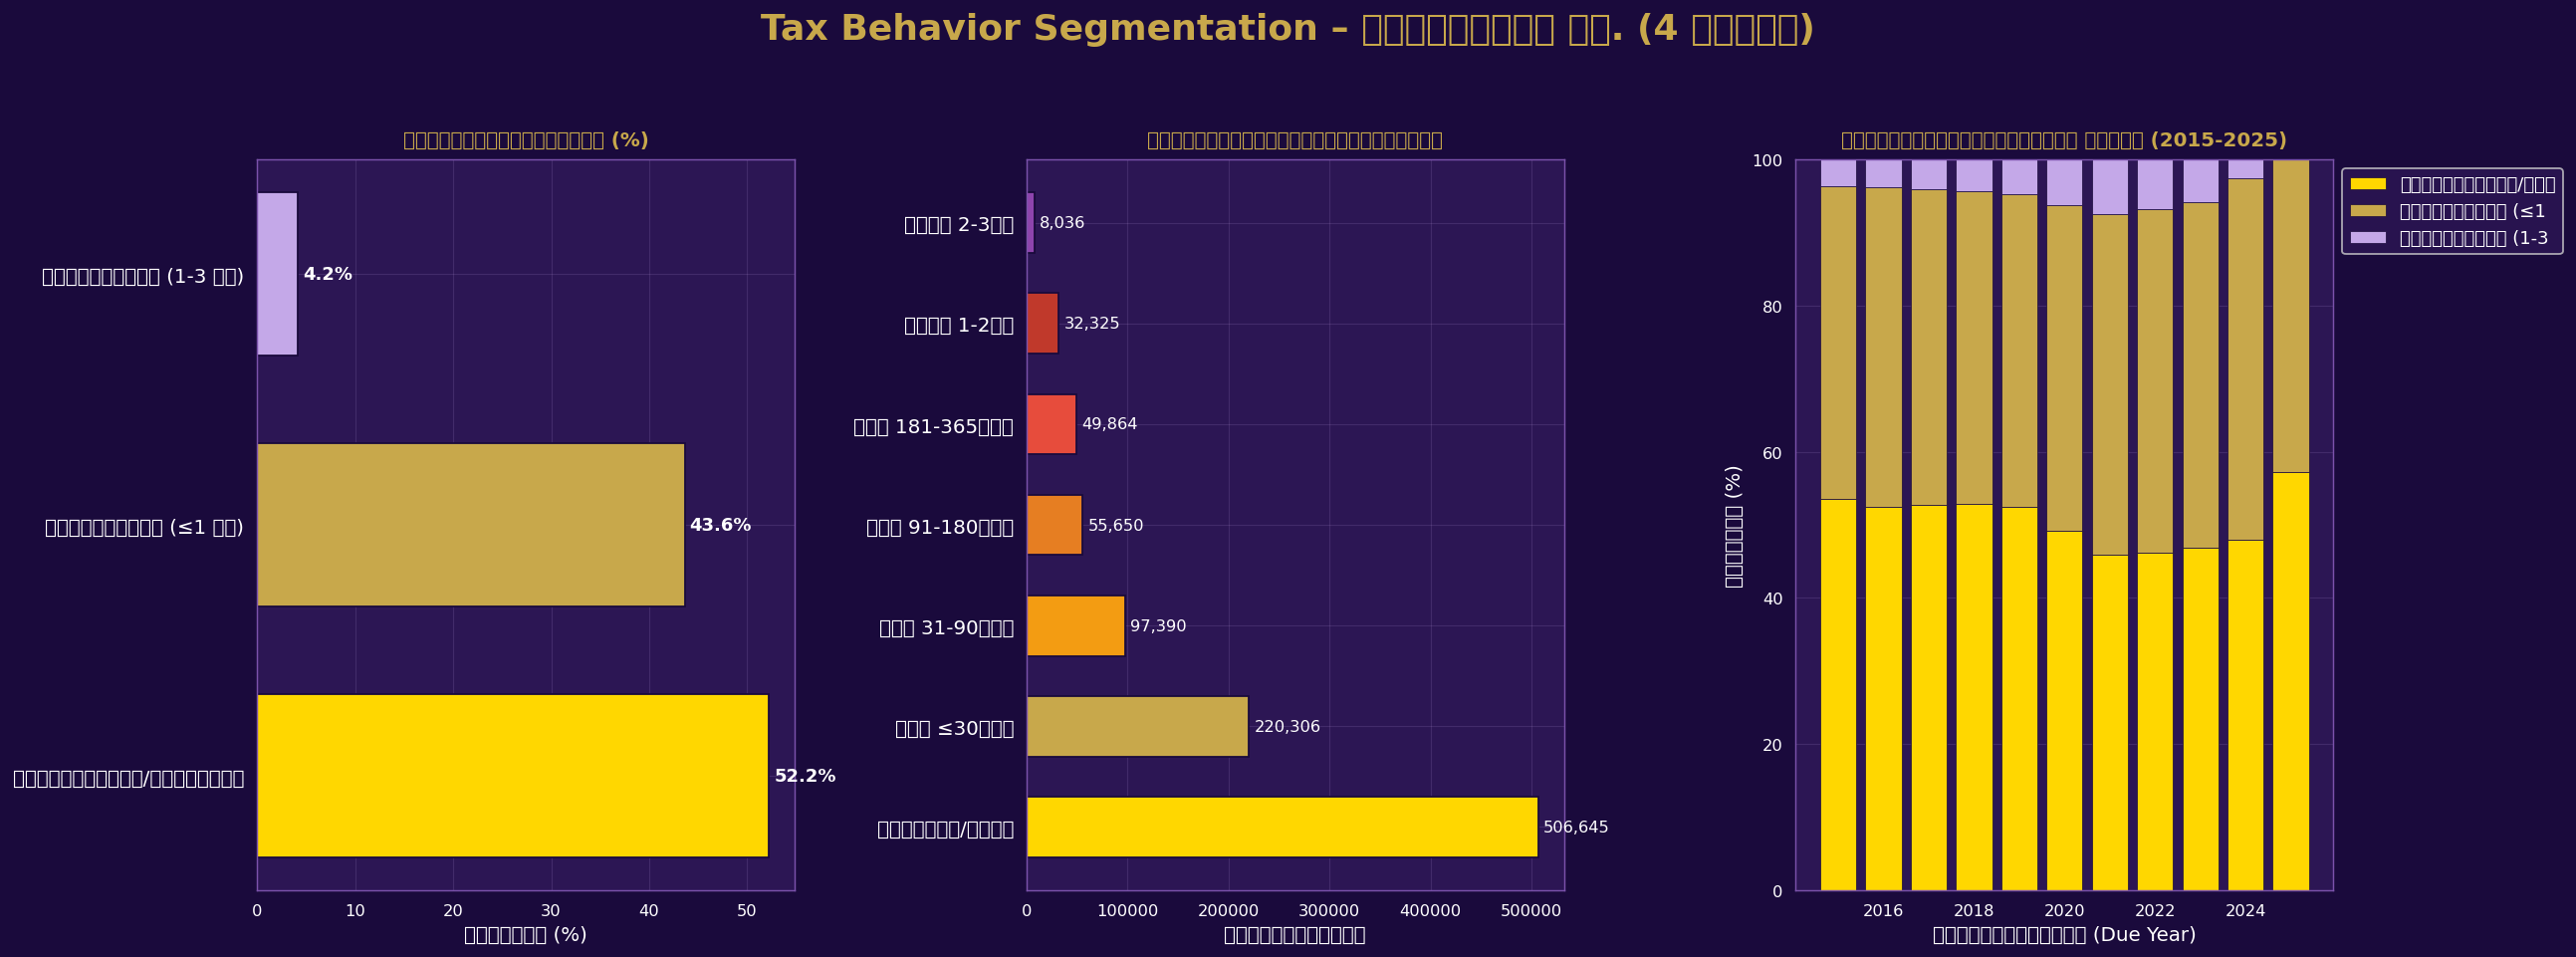

In [36]:
import matplotlib.pyplot as plt
import numpy as np

# ─── Visualization: 4-Group Segmentation (DLT Theme) ─────────────────────────
# ไม่ต้องใช้ pyfonts หรือ fontproperties แล้ว เพราะเราพึ่งพา rcParams จาก DLT Theme
# (หมายเหตุ: ต้องรัน Cell ที่โหลด KANIT_TTF และอัปเดต rcParams ก่อนรันโค้ดนี้นะครับ)

seg_colors_4 = [
    DLT["gold_bright"],   # 1 จ่ายตรง
    DLT["gold_main"],     # 2 ล่าช้า ≤1ปี
    DLT["purple_light"],  # 3 ล่าช้า 1-3ปี
    "#E74C3C",            # 4 เกิน 3ปี
]

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=DLT["bg_dark"])
fig.suptitle("Tax Behavior Segmentation – หลักเกณฑ์ ขบ. (4 กลุ่ม)",
             color=DLT["gold_main"], fontsize=20, fontweight="bold", y=1.05)

# Plot 1: Segment Distribution
ax = axes[0]
ax_style(ax, "สัดส่วนแต่ละกลุ่ม (%)")
seg_present = [s for s in choices_4 if s in df['Tax_Behavior_Segment'].values]
seg_vals    = [df[df['Tax_Behavior_Segment']==s].shape[0]/len(df)*100 for s in seg_present]

bars = ax.barh(range(len(seg_present)), seg_vals,
                color=seg_colors_4[:len(seg_present)], edgecolor=DLT["bg_dark"], height=0.65)

ax.set_yticks(range(len(seg_present)))
ax.set_yticklabels([s.split('.')[1].strip() if '.' in s else s for s in seg_present], fontsize=11)
ax.set_xlabel("สัดส่วน (%)")

for bar, val in zip(bars, seg_vals):
    ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2,
            f"{val:.1f}%", va="center", color=DLT["white"], fontsize=10, fontweight='bold')

# Plot 2: Late Severity Funnel
ax = axes[1]
ax_style(ax, "ระดับความรุนแรงการจ่ายช้า")
sev_order  = ['ตรงเวลา/ก่อน','ช้า ≤30วัน','ช้า 31-90วัน',
                'ช้า 91-180วัน','ช้า 181-365วัน','ค้าง 1-2ปี','ค้าง 2-3ปี']
sev_colors = [DLT["gold_bright"], DLT["gold_main"], "#F39C12",
              "#E67E22","#E74C3C","#C0392B","#8E44AD"]
sev_vals   = [df[df['Late_Severity']==s].shape[0] for s in sev_order]

ax.barh(range(len(sev_order)), sev_vals, color=sev_colors, edgecolor=DLT["bg_dark"], height=0.6)
ax.set_yticks(range(len(sev_order)))
ax.set_yticklabels(sev_order, fontsize=11)
ax.set_xlabel("จำนวนระเบียน")

for i, val in enumerate(sev_vals):
    if val > 0:
        # ขยับตัวเลขเล็กน้อยเพื่อความสวยงาม
        ax.text(val + (max(sev_vals)*0.01), i, f"{val:,}", va="center", color=DLT["white"], fontsize=9)

# Plot 3: Stacked Trend by Year
ax = axes[2]
ax_style(ax, "สัดส่วนกลุ่มพฤติกรรม รายปี (2015-2025)")

df_yr = df[df['Due_Year'].between(2015,2025)].copy()
yr_seg = (df_yr.groupby(['Due_Year','Tax_Behavior_Segment'])
          .size().unstack(fill_value=0))
yr_seg_pct = yr_seg.div(yr_seg.sum(axis=1), axis=0) * 100

bottom_vals = np.zeros(len(yr_seg_pct))
for i, seg in enumerate(choices_4):
    if seg in yr_seg_pct.columns:
        vals = yr_seg_pct[seg].values
        ax.bar(yr_seg_pct.index, vals, bottom=bottom_vals,
               color=seg_colors_4[i], label=seg.split('.')[1].strip()[:15],
               edgecolor=DLT["bg_dark"], linewidth=0.4)
        bottom_vals += vals

ax.set_xlabel("ปีที่ครบกำหนด (Due Year)")
ax.set_ylabel("สัดส่วน (%)")

# จัดการ Legend ให้อ่านง่ายและไม่บังตัวกราฟ
ax.legend(loc="upper left", bbox_to_anchor=(1, 1),
          facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=10)

plt.tight_layout()
plt.show()

  Chi-Square Goodness-of-Fit: สัดส่วนประเภทรถ
  H0: สัดส่วน Sample = Population | H1: แตกต่างกัน
  N (sample)     =      970,216
  N (population) =   43,966,405
  χ²             =  41,897.6632
  df             = 4
  p-value        = 0.00e+00
  Cramér's V     = 0.103904

  ❌ REJECT H0  (p < 0.05)
     Sample มีสัดส่วนประเภทรถ แตกต่าง จาก Population อย่างมีนัยสำคัญ

  Effect size: Cramér's V = 0.103904 → ปานกลาง (Medium)
  (N=970,216 ใหญ่มาก → p จะ significant เสมอ, ให้ดู V และ z-score)

----------------------------------------------------------------------
  ประเภท                       Pop%   Sample%    Diff%   z-score  Flag
----------------------------------------------------------------------
  รย.1 Sedan (≤7 ที่นั่ง)     28.24%    30.25%   +2.01%     37.26  ⚠️  over
  รย.2 Microbus (>7 ที่นั่ง)    1.03%     1.22%   +0.19%     18.38  ⚠️  over
  รย.3 Van/Pickup             15.94%    22.53%   +6.59%    162.55  ⚠️  over
  รย.12 Motorcycle            52.47%    44.18%   -8.29%   -112.74  

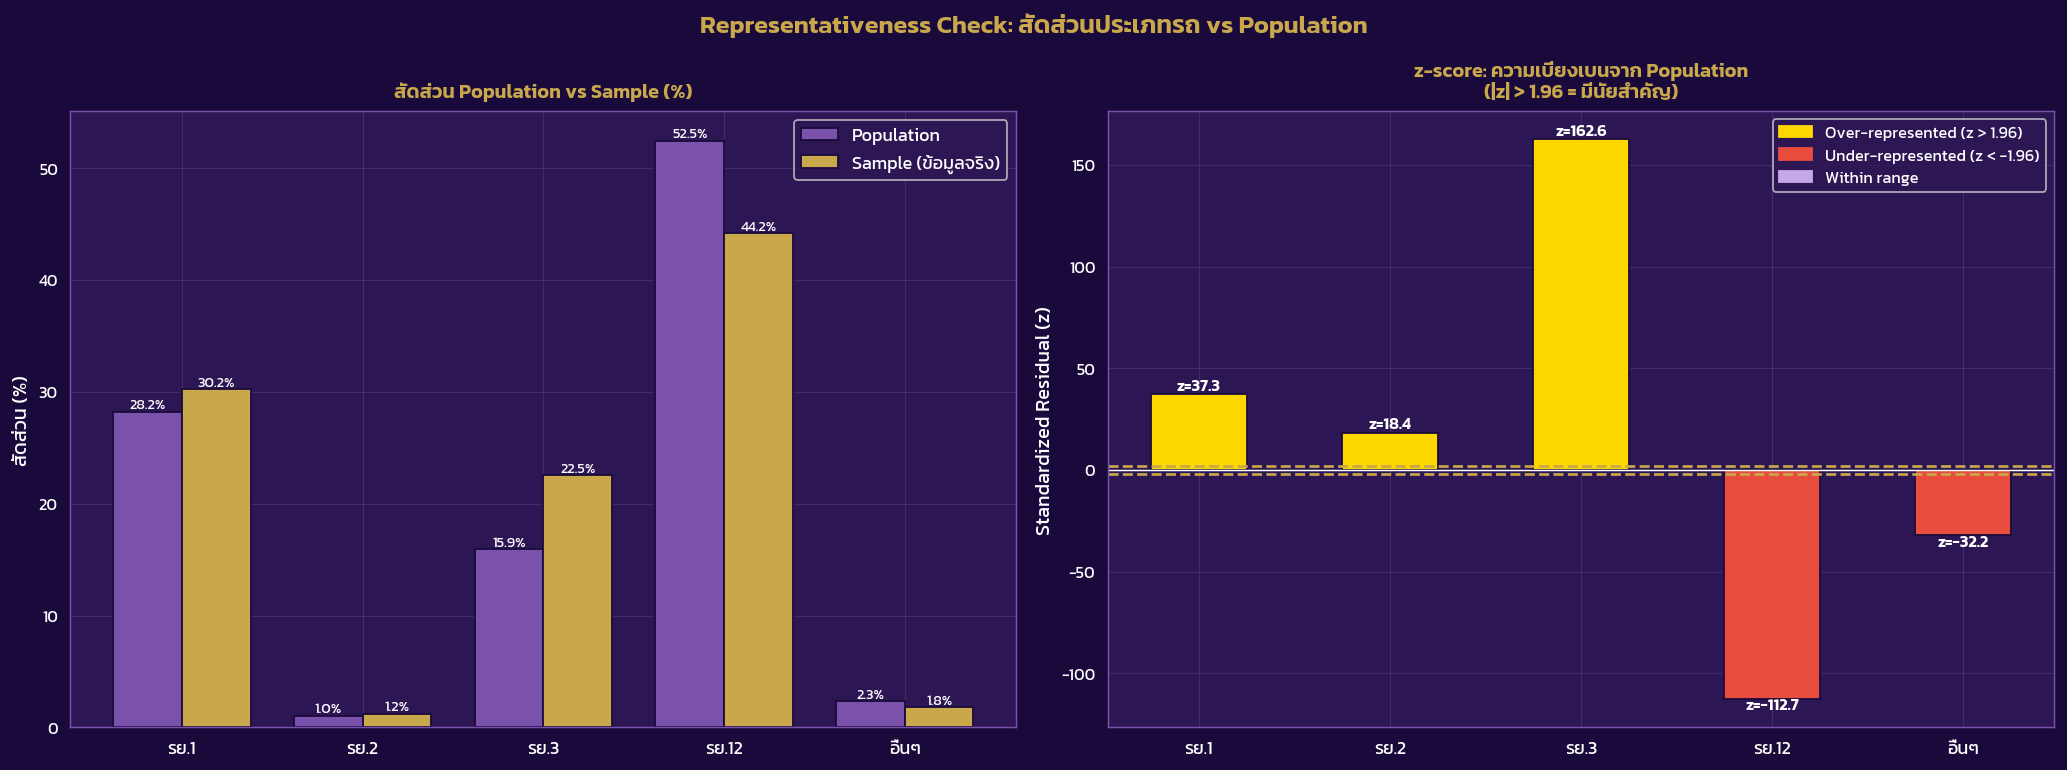


✅ Saved → representativeness_vehtype.png


In [75]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── Data ─────────────────────────────────────────────────────────────────────
data = {
    "ประเภท": [
        "รย.1 Sedan (≤7 ที่นั่ง)",
        "รย.2 Microbus (>7 ที่นั่ง)",
        "รย.3 Van/Pickup",
        "รย.12 Motorcycle",
        "อื่นๆ",
    ],
    "pop_count":    [12_415_556, 453_514, 7_008_080, 23_071_252, 1_018_003],
    "sample_count": [   293_482,  11_847,   218_574,    428_672,    17_641],
}
df_test = pd.DataFrame(data)

POP_TOTAL    = 43_966_405
SAMPLE_TOTAL = df_test["sample_count"].sum()   # 970,216

df_test["pop_pct"]    = df_test["pop_count"]    / POP_TOTAL    * 100
df_test["sample_pct"] = df_test["sample_count"] / SAMPLE_TOTAL * 100
df_test["expected"]   = df_test["pop_pct"] / 100 * SAMPLE_TOTAL
df_test["diff_pct"]   = df_test["sample_pct"] - df_test["pop_pct"]

# ─── Chi-Square GOF ────────────────────────────────────────────────────────────
chi2, p = stats.chisquare(
    f_obs = df_test["sample_count"],
    f_exp = df_test["expected"]
)
df_dof    = len(df_test) - 1
cramers_v = np.sqrt(chi2 / (SAMPLE_TOTAL * (len(df_test) - 1)))

# Standardized residuals
df_test["z_score"] = (df_test["sample_count"] - df_test["expected"]) / np.sqrt(df_test["expected"])

# ─── Print Results ─────────────────────────────────────────────────────────────
print("=" * 70)
print("  Chi-Square Goodness-of-Fit: สัดส่วนประเภทรถ")
print("  H0: สัดส่วน Sample = Population | H1: แตกต่างกัน")
print("=" * 70)
print(f"  N (sample)     = {SAMPLE_TOTAL:>12,}")
print(f"  N (population) = {POP_TOTAL:>12,}")
print(f"  χ²             = {chi2:>12,.4f}")
print(f"  df             = {df_dof}")
print(f"  p-value        = {p:.2e}")
print(f"  Cramér's V     = {cramers_v:.6f}")
print()

alpha = 0.05
if p < alpha:
    print(f"  ❌ REJECT H0  (p < {alpha})")
    print(f"     Sample มีสัดส่วนประเภทรถ แตกต่าง จาก Population อย่างมีนัยสำคัญ")
else:
    print(f"  ✅ FAIL TO REJECT H0  (p ≥ {alpha})")
    print(f"     Sample ไม่แตกต่างจาก Population อย่างมีนัยสำคัญ")

effect = ("เล็กน้อยมาก (Negligible)" if cramers_v < 0.05 else
          "เล็กน้อย (Small)"          if cramers_v < 0.10 else
          "ปานกลาง (Medium)"          if cramers_v < 0.30 else
          "สูง (Large)")
print(f"\n  Effect size: Cramér's V = {cramers_v:.6f} → {effect}")
print(f"  (N={SAMPLE_TOTAL:,} ใหญ่มาก → p จะ significant เสมอ, ให้ดู V และ z-score)")

print("\n" + "-" * 70)
print(f"  {'ประเภท':<25} {'Pop%':>7} {'Sample%':>9} {'Diff%':>8} {'z-score':>9}  Flag")
print("-" * 70)
for _, row in df_test.iterrows():
    flag = "⚠️  over" if row["z_score"] > 1.96 else \
           "⚠️  under" if row["z_score"] < -1.96 else "✅ ok"
    print(f"  {row['ประเภท']:<25} {row['pop_pct']:>7.2f}% {row['sample_pct']:>8.2f}% "
          f"{row['diff_pct']:>+7.2f}% {row['z_score']:>9.2f}  {flag}")
print("-" * 70)

# ─── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), facecolor=DLT["bg_dark"])
fig.suptitle("Representativeness Check: สัดส่วนประเภทรถ vs Population",
             color=DLT["gold_main"], fontsize=14, fontweight="bold")

labels    = [t.split(" ")[0] for t in df_test["ประเภท"]]   # ย่อชื่อ
x         = np.arange(len(labels))
width     = 0.38

# Plot 1: Grouped bar – Pop% vs Sample%
ax = axes[0]; ax_style(ax, "สัดส่วน Population vs Sample (%)")
b1 = ax.bar(x - width/2, df_test["pop_pct"],    width, label="Population",
            color=DLT["purple_mid"],  edgecolor=DLT["bg_dark"])
b2 = ax.bar(x + width/2, df_test["sample_pct"], width, label="Sample (ข้อมูลจริง)",
            color=DLT["gold_main"],   edgecolor=DLT["bg_dark"])
ax.set_xticks(x); ax.set_xticklabels(labels, color=DLT["white"], fontsize=10)
ax.set_ylabel("สัดส่วน (%)")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])
for bar in [*b1, *b2]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{bar.get_height():.1f}%", ha="center", color=DLT["white"], fontsize=8)

# Plot 2: z-score bar (standardized residuals)
ax = axes[1]; ax_style(ax, "z-score: ความเบี่ยงเบนจาก Population\n(|z| > 1.96 = มีนัยสำคัญ)")
colors_z = [DLT["gold_bright"] if z > 1.96 else
            "#E74C3C"          if z < -1.96 else
            DLT["purple_light"]
            for z in df_test["z_score"]]
ax.bar(x, df_test["z_score"], color=colors_z, edgecolor=DLT["bg_dark"], width=0.5)
ax.axhline( 1.96, color=DLT["gold_main"], linestyle="--", lw=1.5, label="+1.96")
ax.axhline(-1.96, color=DLT["gold_main"], linestyle="--", lw=1.5, label="-1.96")
ax.axhline(0, color=DLT["white"], lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(labels, color=DLT["white"], fontsize=10)
ax.set_ylabel("Standardized Residual (z)")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])
for i, (bar_x, z) in enumerate(zip(x, df_test["z_score"])):
    ax.text(bar_x, z + (2 if z >= 0 else -5),
            f"z={z:.1f}", ha="center", color=DLT["white"], fontsize=9, fontweight="bold")

# Legend for colors
patches = [
    mpatches.Patch(color=DLT["gold_bright"],   label="Over-represented (z > 1.96)"),
    mpatches.Patch(color="#E74C3C",            label="Under-represented (z < -1.96)"),
    mpatches.Patch(color=DLT["purple_light"],  label="Within range"),
]
ax.legend(handles=patches, facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=9)

plt.tight_layout()
plt.savefig("representativeness_vehtype.png", bbox_inches="tight",
            dpi=150, facecolor=DLT["bg_dark"])
plt.show()
print("\n✅ Saved → representativeness_vehtype.png")

Transactions ทั้งหมด : 970,216 แถว
ยานพาหนะไม่ซ้ำ      : 99,947 คัน
Province column      : 'Owner_Province'
ยานพาหนะใน sample   : 99,758 คัน

  Chi-Square GOF: จำนวนคัน (ไม่ซ้ำ) ต่อจังหวัด vs Population
  หน่วย: ยานพาหนะ 1 คัน = 1 หน่วย (dedup by Encode_ChassisNo)
  χ²          =      43,909.15
  df          = 76
  p-value     = 0.00e+00
  Cramér's V  = 0.076102  →  เล็กน้อย (Small)

  ❌ REJECT H0

  Top 15 จังหวัดที่เบี่ยงเบนมากสุด
  จังหวัด                คันใน Sample    Pop%    Smp%  Coverage       z  Flag
  ------------------------------------------------------------------------
  สมุทรปราการ                   2,202    0.32%    2.21%     1.57%  105.82  🟡 over 
  กรุงเทพมหานคร                10,295   27.79%   10.32%     0.08% -104.66  🔴 under
  นนทบุรี                       2,097    0.37%    2.10%     1.28%   89.41  🟡 over 
  ปทุมธานี                      2,029    0.37%    2.03%     1.25%   86.66  🟡 over 
  ศรีสะเกษ                      1,734    1.00%    1.74%     0.40%   23.42  🟡 o

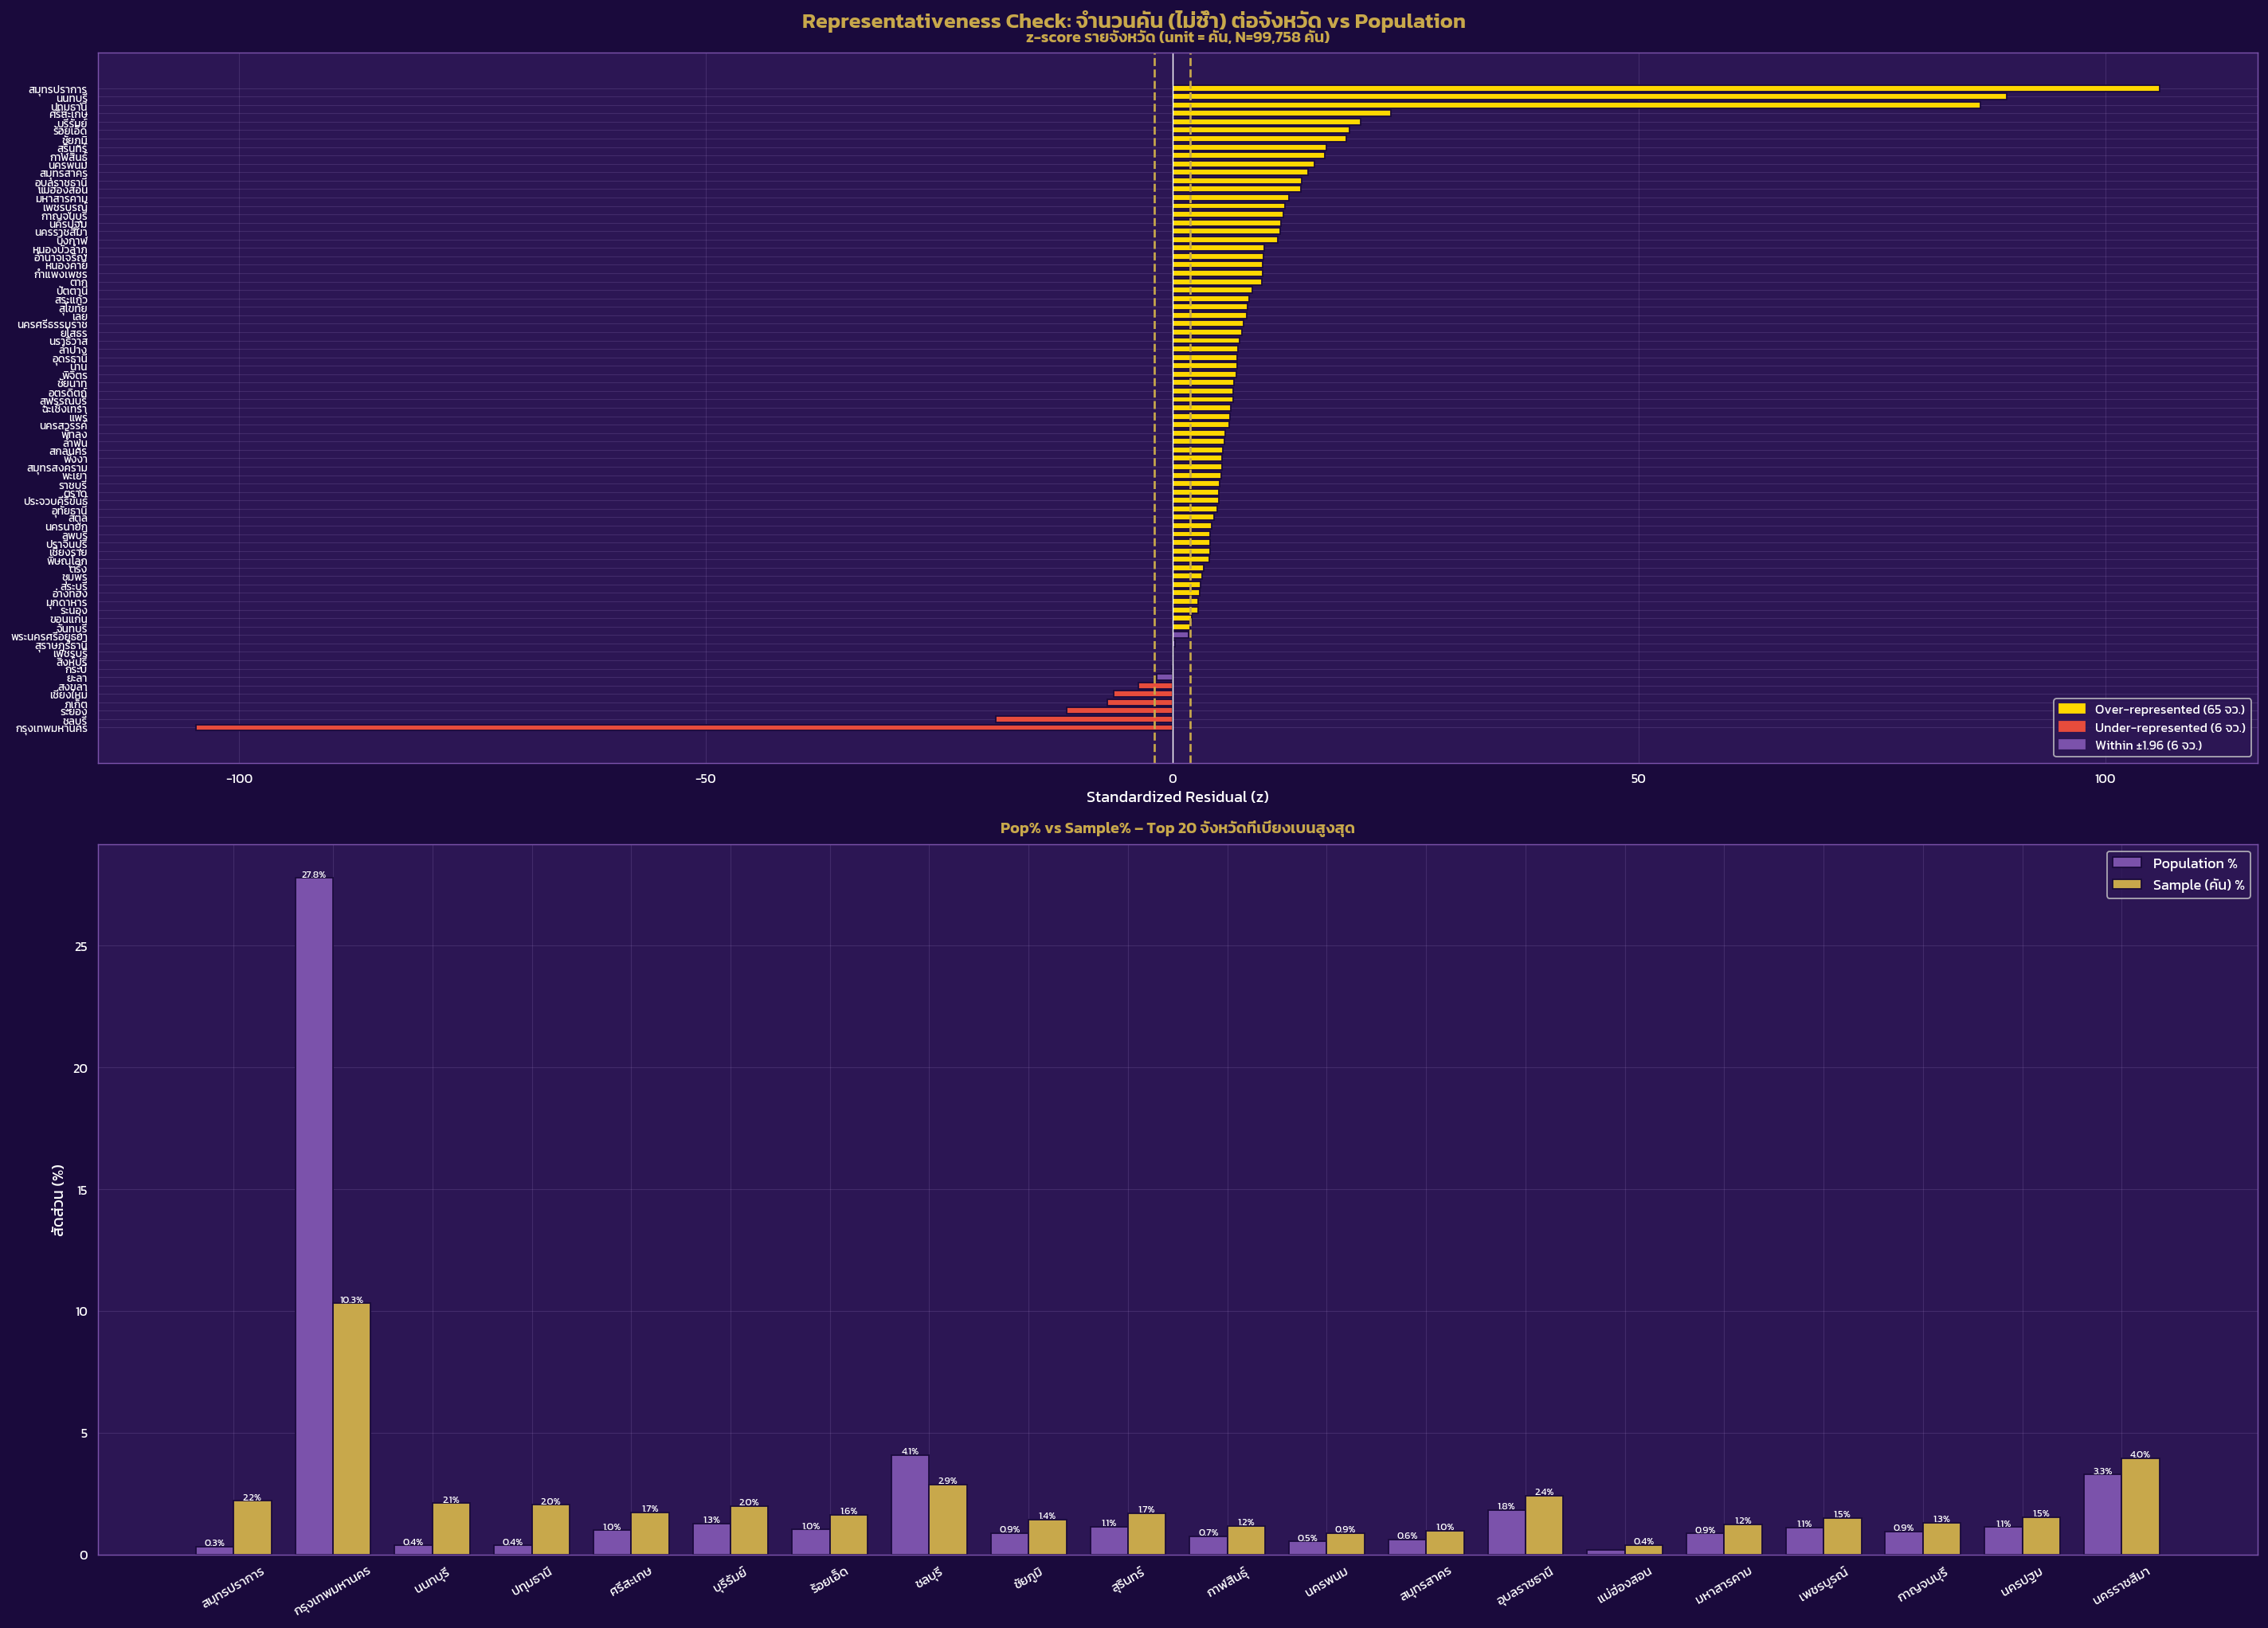


✅ Saved → representativeness_province_by_vehicle.png
   χ²=43,909 | Cramér's V=0.0761 (เล็กน้อย (Small))


In [77]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─── Deduplicate: 1 คัน = 1 แถว (เอา ChassisNo ล่าสุดต่อจังหวัด) ─────────────
prov_col = "Owner_Province" if "Owner_Province" in df.columns else "Province"

# เรียง Due_Year จากมากไปน้อย แล้ว drop_duplicates เก็บแถวล่าสุดของแต่ละคัน
df_unique = (df.sort_values("Due_Year", ascending=False)
               .drop_duplicates(subset=["Encode_ChassisNo"], keep="first")
               .copy())

print(f"Transactions ทั้งหมด : {len(df):,} แถว")
print(f"ยานพาหนะไม่ซ้ำ      : {len(df_unique):,} คัน")
print(f"Province column      : '{prov_col}'")

# ─── Observed: นับจำนวนคัน (ไม่ซ้ำ) ต่อจังหวัด ────────────────────────────────
obs_raw = df_unique[prov_col].str.strip().value_counts().to_dict()

alias_map = {
    "กรุงเทพฯ"   : "กรุงเทพมหานคร",
    "กทม."       : "กรุงเทพมหานคร",
    "แม่ฮองสอน"  : "แม่ฮ่องสอน",
}
obs_clean = {}
for k, v in obs_raw.items():
    mapped = alias_map.get(k, k)
    obs_clean[mapped] = obs_clean.get(mapped, 0) + v

SAMPLE_TOTAL = sum(obs_clean.values())   # จำนวนคันทั้งหมดใน sample
print(f"ยานพาหนะใน sample   : {SAMPLE_TOTAL:,} คัน")

# ─── Population ────────────────────────────────────────────────────────────────
pop_data = {
    "กรุงเทพมหานคร":12_216_844,"ชัยนาท":176_373,"สิงห์บุรี":138_935,
    "ลพบุรี":435_001,"อ่างทอง":157_299,"สระบุรี":431_633,
    "พระนครศรีอยุธยา":521_909,"ปทุมธานี":161_984,"นนทบุรี":164_023,
    "สมุทรปราการ":139_821,"นครนายก":144_541,"ปราจีนบุรี":289_038,
    "ฉะเชิงเทรา":423_076,"ชลบุรี":1_792_044,"ระยอง":864_513,
    "จันทบุรี":432_181,"ตราด":138_358,"สระแก้ว":293_976,
    "ชัยภูมิ":387_574,"ยโสธร":218_226,"อุบลราชธานี":801_539,
    "ศรีสะเกษ":438_655,"บุรีรัมย์":561_444,"นครราชสีมา":1_445_882,
    "สุรินทร์":498_998,"อำนาจเจริญ":133_783,"หนองบัวลำภู":171_059,
    "บึงกาฬ":137_373,"หนองคาย":214_903,"เลย":297_292,
    "อุดรธานี":758_210,"นครพนม":235_492,"สกลนคร":555_607,
    "ขอนแก่น":937_369,"กาฬสินธุ์":324_466,"มหาสารคาม":381_374,
    "ร้อยเอ็ด":451_913,"มุกดาหาร":192_298,"เชียงราย":825_858,
    "แม่ฮ่องสอน":83_350,"เชียงใหม่":1_639_887,"พะเยา":275_346,
    "น่าน":259_106,"ลำพูน":281_553,"ลำปาง":457_829,"แพร่":272_222,
    "อุตรดิตถ์":274_909,"สุโขทัย":337_166,"ตาก":264_984,
    "พิษณุโลก":583_563,"กำแพงเพชร":376_601,"พิจิตร":294_110,
    "เพชรบูรณ์":486_135,"นครสวรรค์":607_826,"อุทัยธานี":191_084,
    "สุพรรณบุรี":479_863,"กาญจนบุรี":412_452,"นครปฐม":496_481,
    "ราชบุรี":535_103,"สมุทรสาคร":268_317,"สมุทรสงคราม":85_590,
    "เพชรบุรี":359_882,"ประจวบคีรีขันธ์":347_130,"ชุมพร":319_752,
    "ระนอง":106_597,"สุราษฎร์ธานี":691_357,"พังงา":130_751,
    "นครศรีธรรมราช":684_801,"กระบี่":291_830,"ภูเก็ต":557_288,
    "พัทลุง":262_820,"ตรัง":369_490,"สงขลา":939_522,"สตูล":142_764,
    "ปัตตานี":284_268,"ยะลา":335_930,"นราธิวาส":287_882,
}
POP_TOTAL = 43_966_405

# ─── Comparison Table ─────────────────────────────────────────────────────────
common      = sorted(set(pop_data) & set(obs_clean))
missing_pop = set(obs_clean) - set(pop_data)
missing_obs = set(pop_data)  - set(obs_clean)

if missing_pop: print(f"\n⚠️  ใน df แต่ไม่อยู่ใน pop_data : {missing_pop}")
if missing_obs: print(f"⚠️  ไม่พบในข้อมูลเลย (obs=0)    : {missing_obs}")

df_prov = pd.DataFrame({
    "จังหวัด"   : common,
    "pop_count" : [pop_data[p]         for p in common],
    "obs_count" : [obs_clean.get(p, 0) for p in common],
})
df_prov["pop_pct"]    = df_prov["pop_count"] / POP_TOTAL    * 100
df_prov["sample_pct"] = df_prov["obs_count"] / SAMPLE_TOTAL * 100
df_prov["expected"]   = df_prov["pop_pct"] / 100 * SAMPLE_TOTAL
df_prov["diff_pct"]   = df_prov["sample_pct"] - df_prov["pop_pct"]
df_prov["z_score"]    = ((df_prov["obs_count"] - df_prov["expected"])
                          / np.sqrt(df_prov["expected"]))

# เพิ่ม: coverage rate (sample คัน / population คัน × 100)
df_prov["coverage_pct"] = df_prov["obs_count"] / df_prov["pop_count"] * 100

# ─── Chi-Square GOF ───────────────────────────────────────────────────────────
valid = df_prov["expected"] >= 5
chi2, p = stats.chisquare(
    f_obs=df_prov.loc[valid, "obs_count"],
    f_exp=df_prov.loc[valid, "expected"]
)
df_dof    = valid.sum() - 1
cramers_v = np.sqrt(chi2 / (SAMPLE_TOTAL * (valid.sum() - 1)))
effect    = ("เล็กน้อยมาก (Negligible)" if cramers_v < 0.05 else
             "เล็กน้อย (Small)"          if cramers_v < 0.10 else
             "ปานกลาง (Medium)"          if cramers_v < 0.30 else
             "สูง (Large)")

print("\n" + "="*70)
print("  Chi-Square GOF: จำนวนคัน (ไม่ซ้ำ) ต่อจังหวัด vs Population")
print("  หน่วย: ยานพาหนะ 1 คัน = 1 หน่วย (dedup by Encode_ChassisNo)")
print("="*70)
print(f"  χ²          = {chi2:>14,.2f}")
print(f"  df          = {df_dof}")
print(f"  p-value     = {p:.2e}")
print(f"  Cramér's V  = {cramers_v:.6f}  →  {effect}")
print()
print("  ❌ REJECT H0" if p < 0.05 else "  ✅ FAIL TO REJECT H0")

sig_over  = (df_prov["z_score"] >  1.96).sum()
sig_under = (df_prov["z_score"] < -1.96).sum()

df_sorted = df_prov.sort_values("z_score", key=abs, ascending=False)
print(f"\n  Top 15 จังหวัดที่เบี่ยงเบนมากสุด")
print(f"  {'จังหวัด':<22} {'คันใน Sample':>12} {'Pop%':>7} {'Smp%':>7} {'Coverage':>9} {'z':>7}  Flag")
print("  " + "-"*72)
for _, row in df_sorted.head(15).iterrows():
    flag = "🟡 over " if row["z_score"] >  1.96 else \
           "🔴 under" if row["z_score"] < -1.96 else "✅ ok   "
    print(f"  {row['จังหวัด']:<22} {row['obs_count']:>12,.0f} "
          f"{row['pop_pct']:>7.2f}% {row['sample_pct']:>7.2f}% "
          f"{row['coverage_pct']:>8.2f}% {row['z_score']:>7.2f}  {flag}")

print(f"\n  สรุป: Over {sig_over} จว. | Under {sig_under} จว. | "
      f"OK {len(df_prov)-sig_over-sig_under} จว.")
print(f"  Coverage เฉลี่ย: {df_prov['coverage_pct'].mean():.2f}% ของ population")

# ─── Export Summary Table ─────────────────────────────────────────────────────
df_export = df_prov.sort_values("z_score", key=abs, ascending=False)[
    ["จังหวัด","pop_count","obs_count","pop_pct","sample_pct",
     "coverage_pct","diff_pct","z_score"]
].copy()
df_export.columns = ["จังหวัด","Pop (คัน)","Sample (คัน)",
                      "Pop%","Sample%","Coverage%","Diff%","z-score"]
df_export.to_csv("representativeness_province_by_vehicle.csv",
                 index=False, encoding="utf-8-sig")
print("\n✅ Saved → representativeness_province_by_vehicle.csv")

# ─── Visualization ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(22, 16), facecolor=DLT["bg_dark"])
fig.suptitle("Representativeness Check: จำนวนคัน (ไม่ซ้ำ) ต่อจังหวัด vs Population",
             color=DLT["gold_main"], fontsize=15, fontweight="bold")

# Plot 1: z-score ทุกจังหวัด
ax = axes[0]
ax_style(ax, f"z-score รายจังหวัด (unit = คัน, N={SAMPLE_TOTAL:,} คัน)")
df_plot   = df_prov.sort_values("z_score")
z_vals    = df_plot["z_score"].values
prov_lbls = df_plot["จังหวัด"].values
bar_colors = [DLT["gold_bright"] if z >  1.96 else
              "#E74C3C"          if z < -1.96 else
              DLT["purple_mid"]  for z in z_vals]
ax.barh(range(len(z_vals)), z_vals, color=bar_colors,
        edgecolor=DLT["bg_dark"], height=0.75)
ax.set_yticks(range(len(prov_lbls)))
ax.set_yticklabels(prov_lbls, fontsize=7.5, color=DLT["white"])
ax.axvline( 1.96, color=DLT["gold_main"], lw=1.5, linestyle="--")
ax.axvline(-1.96, color=DLT["gold_main"], lw=1.5, linestyle="--")
ax.axvline(0,     color=DLT["white"],     lw=0.8)
ax.set_xlabel("Standardized Residual (z)")
patches_leg = [
    mpatches.Patch(color=DLT["gold_bright"], label=f"Over-represented ({sig_over} จว.)"),
    mpatches.Patch(color="#E74C3C",          label=f"Under-represented ({sig_under} จว.)"),
    mpatches.Patch(color=DLT["purple_mid"],  label=f"Within ±1.96 ({len(df_prov)-sig_over-sig_under} จว.)"),
]
ax.legend(handles=patches_leg, facecolor=DLT["bg_card"],
          labelcolor=DLT["white"], fontsize=9, loc="lower right")

# Plot 2: Pop% vs Sample% (Top 20)
ax = axes[1]
ax_style(ax, "Pop% vs Sample% – Top 20 จังหวัดที่เบี่ยงเบนสูงสุด", xticks_rot=30)
top20 = df_prov.sort_values("z_score", key=abs, ascending=False).head(20)
x = np.arange(len(top20)); w = 0.38
b1 = ax.bar(x-w/2, top20["pop_pct"],    w, label="Population %",
            color=DLT["purple_mid"], edgecolor=DLT["bg_dark"])
b2 = ax.bar(x+w/2, top20["sample_pct"], w, label="Sample (คัน) %",
            color=DLT["gold_main"],  edgecolor=DLT["bg_dark"])
ax.set_xticks(x)
ax.set_xticklabels(top20["จังหวัด"], fontsize=9)
ax.set_ylabel("สัดส่วน (%)")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])
for bar in [*b1, *b2]:
    h = bar.get_height()
    if h > 0.3:
        ax.text(bar.get_x()+bar.get_width()/2, h+0.05,
                f"{h:.1f}%", ha="center", color=DLT["white"], fontsize=7)

plt.tight_layout()
plt.savefig("representativeness_province_by_vehicle.png",
            bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()
print(f"\n✅ Saved → representativeness_province_by_vehicle.png")
print(f"   χ²={chi2:,.0f} | Cramér's V={cramers_v:.4f} ({effect})")

### 📊 Segment Insights สำหรับผู้บริหาร

| Seg | กลุ่ม | นิยาม | กลยุทธ์ Nudge |
|-----|------|------|-------------|
| 1 | **จ่ายตรง/ล่วงหน้า** | จ่ายก่อนหรือตรงกำหนด | Loyalty – ส่วนลด Early Bird |
| 2 | **ช้า ≤1 ปี** | มาเคลียร์เองได้ แต่ช้า | SMS + Social Norm 60 วันก่อน (+13.07%) |
| 3 | **ช้า 1–3 ปี** | มีภาระ/ลืม แต่ยังเข้าถึงได้ | จดหมายราชการ + Amnesty Program |
| 4 | **เกิน 3 ปี** | ระงับทะเบียนแล้ว | Law Enforcement |

> 3 โมเดลที่จะสร้าง: **Binary** (กลุ่ม 1 vs 2-4) · **Multiclass** (กลุ่ม 1-4) · **Regression** (จำนวนวันที่ล่าช้า)


---
## 📊 2. Executive Dashboard – Professional Consulting Style
> ภาพรวมข้อมูลแบบ DLT Brand (ม่วง × ทอง) สำหรับนำเสนอผู้บริหาร


In [37]:
# ─── KPI Data Prep ────────────────────────────────────────────────────────────
total_records  = len(df)
total_vehicles = df["Encode_ChassisNo"].nunique()
overall_late   = df["Target_Is_Late"].mean() * 100
avg_tax        = df["Tax_Amount"].mean()
total_provinces= df["Province"].nunique() if "Province" in df.columns else df.get("Owner_Province",pd.Series()).nunique()
year_range     = f"{df['Due_Year'].min()}–{df['Due_Year'].max()}"

# Late rate by year
yr_late = df.groupby("Due_Year")["Target_Is_Late"].agg(["mean","count"]).reset_index()
yr_late["late_pct"] = yr_late["mean"] * 100
yr_late = yr_late[yr_late["Due_Year"].between(2010,2025)]

# Late rate by province (top 10)
prov_late = (df.groupby("Province")["Target_Is_Late"]
               .agg(["mean","count"])
               .query("count >= 50")
               .sort_values("mean", ascending=False)
               .head(10)
               .reset_index())
prov_late["late_pct"] = prov_late["mean"] * 100

# Status distribution
status_cnt = df["Status"].value_counts()

# Vehicle age distribution
age_late = (df[df["Vehicle_Age"].between(1,25)]
             .groupby("Vehicle_Age")["Target_Is_Late"]
             .mean() * 100)

# Channel distribution
ch_cnt = ch.value_counts().head(5) if "ch" in dir() else pd.Series()

# Fuel type late rate
if "Fuel_Type" in df.columns:
    fuel_late = (df.groupby("Fuel_Type")["Target_Is_Late"]
                   .agg(["mean","count"])
                   .query("count >= 50")
                   .sort_values("mean", ascending=False))
else:
    fuel_late = pd.DataFrame()
print("✅ KPI data ready")


✅ KPI data ready


In [38]:
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# บังคับชี้ไปที่ไฟล์ฟอนต์ที่ดาวน์โหลดไว้
fm.fontManager.addfont('/tmp/Kanit-Regular.ttf')
plt.rcParams['font.family'] = 'Kanit'

# เคลียร์ลบแจ้งเตือน Warning เล็กน้อย
plt.rcParams['axes.unicode_minus'] = False

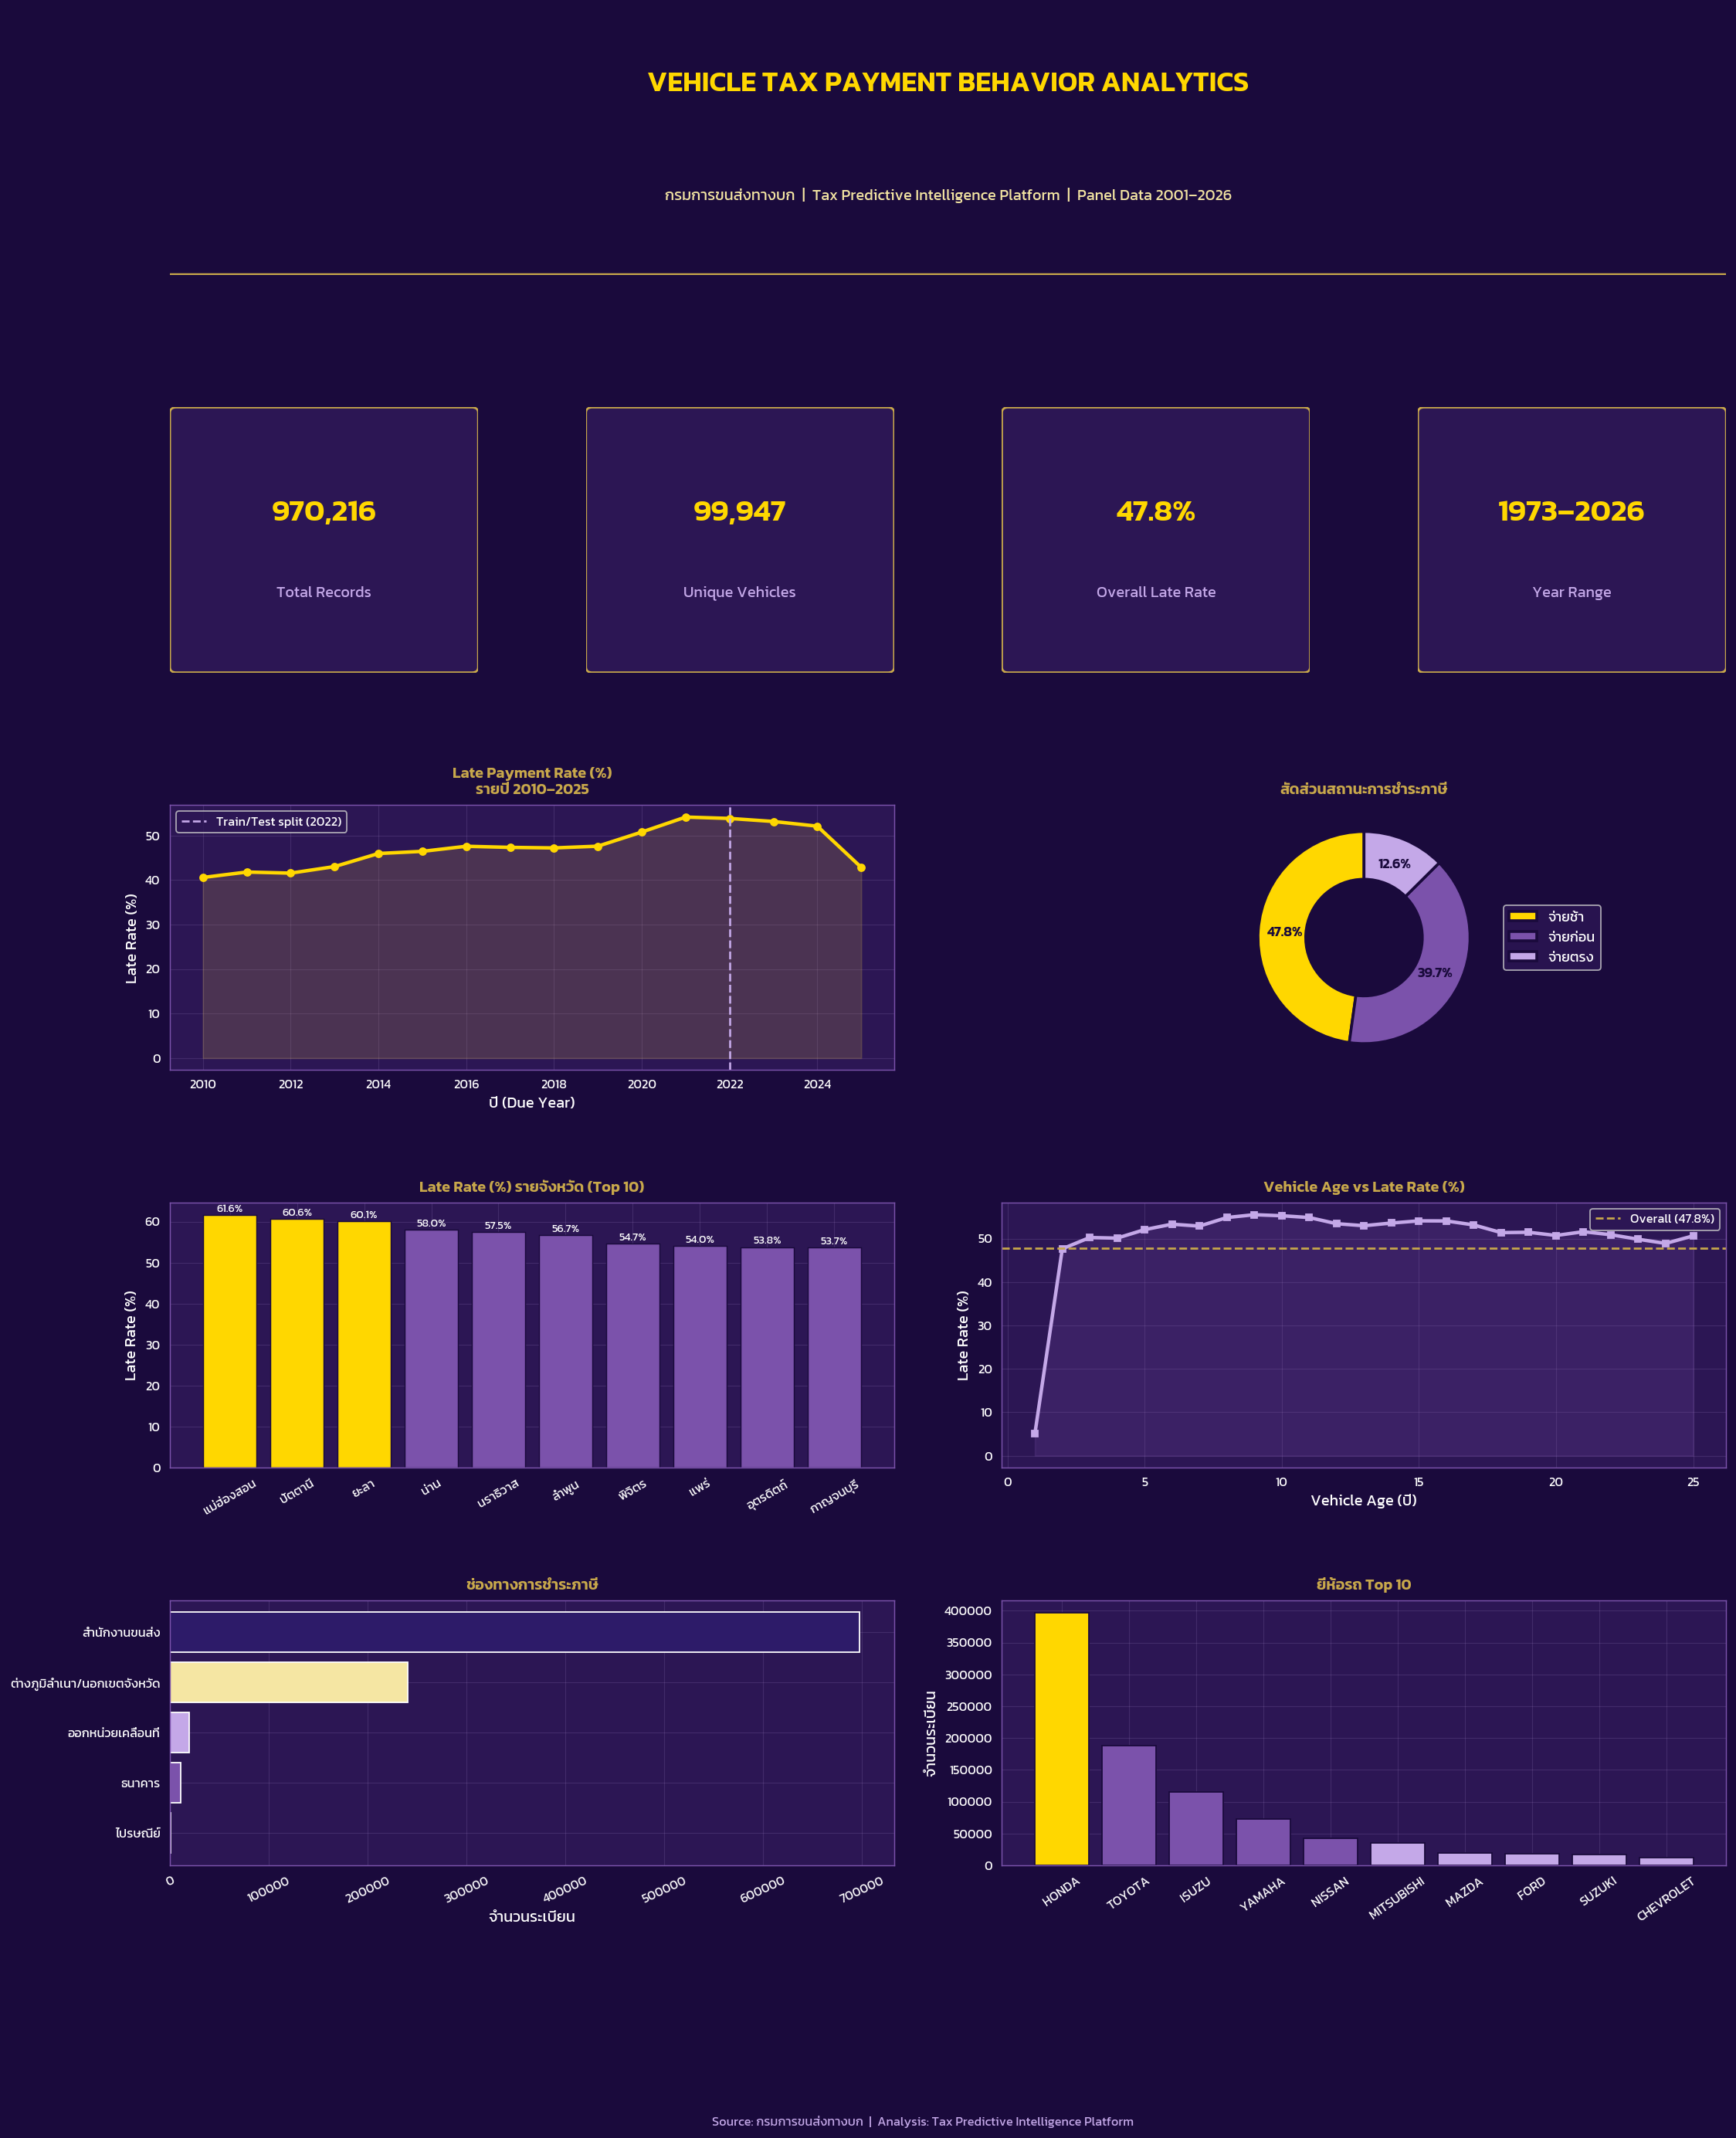

✅ Dashboard saved → dlt_dashboard_clean.png


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# DASHBOARD: Matplotlib Professional (DLT Brand) - No Emojis
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 24), facecolor=DLT["bg_dark"])
gs  = GridSpec(5, 4, figure=fig, hspace=0.50, wspace=0.35)

# ── helper ──────────────────────────────────────────────────────────────────
def ax_style(ax, title="", xticks_rot=0):
    ax.set_facecolor(DLT["bg_card"])
    for spine in ax.spines.values(): spine.set_edgecolor(DLT["purple_mid"])
    ax.tick_params(colors=DLT["white"], labelsize=9)
    ax.xaxis.label.set_color(DLT["white"])
    ax.yaxis.label.set_color(DLT["white"])
    if title:
        ax.set_title(title, color=DLT["gold_main"], fontsize=11, pad=8, fontweight="bold")
    if xticks_rot:
        ax.tick_params(axis="x", rotation=xticks_rot)
    ax.grid(color=DLT["purple_light"], alpha=0.15, linewidth=0.6)

# ── ROW 0: Header bar ───────────────────────────────────────────────────────
ax_hdr = fig.add_subplot(gs[0, :])
ax_hdr.set_facecolor(DLT["purple_main"])
ax_hdr.set_xlim(0,1); ax_hdr.set_ylim(0,1)
ax_hdr.axis("off")
ax_hdr.text(0.5, 0.72, "VEHICLE TAX PAYMENT BEHAVIOR ANALYTICS",
    transform=ax_hdr.transAxes, ha="center", va="center",
    color=DLT["gold_bright"], fontsize=20, fontweight="bold")
ax_hdr.text(0.5, 0.30, "กรมการขนส่งทางบก  |  Tax Predictive Intelligence Platform  |  Panel Data 2001–2026",
    transform=ax_hdr.transAxes, ha="center", va="center",
    color=DLT["gold_light"], fontsize=11)
# Gold line accent
ax_hdr.axhline(0.0, color=DLT["gold_main"], linewidth=3)

# ── ROW 1: KPI Cards (5 cards) ───────────────────────────────────────────────
kpis = [
    (f"{total_records:,}", "Total Records"),
    (f"{total_vehicles:,}", "Unique Vehicles"),
    (f"{overall_late:.1f}%", "Overall Late Rate"),
    (f"฿{avg_tax:,.0f}", "Avg Tax Amount"),
    (year_range, "Year Range"),
]
for col_i, (val, label) in enumerate(kpis):
    ax_k = fig.add_subplot(gs[1, col_i] if col_i < 4 else gs[1, 3])
    ax_k.set_facecolor(DLT["bg_card"])
    ax_k.set_xlim(0,1); ax_k.set_ylim(0,1); ax_k.axis("off")
    for spine in ax_k.spines.values(): spine.set_edgecolor(DLT["gold_main"]); spine.set_linewidth(1.5)
    ax_k.set_visible(True)

    # ปรับตำแหน่งตัวเลขให้อยู่ตรงกลางเพราะเอาไอคอนออกแล้ว
    ax_k.text(0.5, 0.60, val,  ha="center", va="center",
              transform=ax_k.transAxes, color=DLT["gold_bright"],
              fontsize=22, fontweight="bold")
    ax_k.text(0.5, 0.30, label, ha="center", va="center",
              transform=ax_k.transAxes, color=DLT["purple_light"], fontsize=11)

    rect = mpatches.FancyBboxPatch((0.02,0.02), 0.96, 0.96,
        boxstyle="round,pad=0.02", linewidth=1.5,
        edgecolor=DLT["gold_main"], facecolor=DLT["bg_card"],
        transform=ax_k.transAxes, zorder=-1)
    ax_k.add_patch(rect)

# ── ROW 2, COL 0-1: Late Rate Trend ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[2, :2])
ax_style(ax1, "Late Payment Rate (%)\nรายปี 2010–2025")
ax1.fill_between(yr_late["Due_Year"], yr_late["late_pct"],
                 alpha=0.20, color=DLT["gold_main"])
ax1.plot(yr_late["Due_Year"], yr_late["late_pct"],
         color=DLT["gold_bright"], linewidth=2.5, marker="o", markersize=5)
ax1.axvline(TRAIN_CUTOFF, color=DLT["purple_light"], linestyle="--", linewidth=1.5,
            label=f"Train/Test split ({TRAIN_CUTOFF})")
ax1.set_xlabel("ปี (Due Year)")
ax1.set_ylabel("Late Rate (%)")
ax1.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=9)

# ── ROW 2, COL 2-3: Status Donut ─────────────────────────────────────────────
ax2 = fig.add_subplot(gs[2, 2:])
ax_style(ax2, "สัดส่วนสถานะการชำระภาษี")
colors_donut = [DLT["gold_bright"], DLT["purple_mid"], DLT["purple_light"]]
wedge_props = dict(width=0.45, edgecolor=DLT["bg_dark"], linewidth=2)
wedges, texts, autos = ax2.pie(
    status_cnt.values, labels=None,
    autopct="%1.1f%%", pctdistance=0.75,
    colors=colors_donut[:len(status_cnt)],
    wedgeprops=wedge_props, startangle=90)
for a in autos: a.set_color(DLT["bg_dark"]); a.set_fontsize(10); a.set_fontweight("bold")
ax2.legend(wedges, status_cnt.index.tolist(),
           loc="center left", bbox_to_anchor=(1, 0.5),
           facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=10)

# ── ROW 3, COL 0-1: Province Late Rate ───────────────────────────────────────
ax3 = fig.add_subplot(gs[3, :2])
ax_style(ax3, "Late Rate (%) รายจังหวัด (Top 10)", xticks_rot=30)
bar_colors = [DLT["gold_bright"] if i < 3 else DLT["purple_mid"]
              for i in range(len(prov_late))]
ax3.bar(prov_late["Province"], prov_late["late_pct"],
        color=bar_colors, edgecolor=DLT["bg_dark"], linewidth=0.8)
ax3.set_ylabel("Late Rate (%)")
for i, (_, row) in enumerate(prov_late.iterrows()):
    ax3.text(i, row["late_pct"]+0.3, f'{row["late_pct"]:.1f}%',
             ha="center", va="bottom", color=DLT["white"], fontsize=8)

# ── ROW 3, COL 2-3: Vehicle Age vs Late Rate ─────────────────────────────────
ax4 = fig.add_subplot(gs[3, 2:])
ax_style(ax4, "Vehicle Age vs Late Rate (%)")
ax4.fill_between(age_late.index, age_late.values, alpha=0.20, color=DLT["purple_mid"])
ax4.plot(age_late.index, age_late.values,
         color=DLT["purple_light"], linewidth=2.5, marker="s", markersize=4)
ax4.axhline(overall_late, color=DLT["gold_main"], linestyle="--", linewidth=1.5,
            label=f"Overall ({overall_late:.1f}%)")
ax4.set_xlabel("Vehicle Age (ปี)")
ax4.set_ylabel("Late Rate (%)")
ax4.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=9)

# ── ROW 4: Payment Channel + Brand Top 10 ─────────────────────────────────────
# Channel
ax5 = fig.add_subplot(gs[4, :2])
ax_style(ax5, "ช่องทางการชำระภาษี", xticks_rot=25)
ch_cnt2 = df["Payment_Chanel"].value_counts().head(5) if "Payment_Chanel" in df.columns else pd.Series()
if len(ch_cnt2):
    ax5.barh(ch_cnt2.index[::-1], ch_cnt2.values[::-1],
             color=[DLT["gold_main"], DLT["purple_mid"],
                    DLT["purple_light"], DLT["gold_light"],
                    DLT["purple_deep"]][:len(ch_cnt2)])
    ax5.set_xlabel("จำนวนระเบียน")

# Brand
ax6 = fig.add_subplot(gs[4, 2:])
ax_style(ax6, "ยี่ห้อรถ Top 10", xticks_rot=35)
if "Brand" in df.columns:
    brand_cnt = df["Brand"].value_counts().head(10)
    ax6.bar(brand_cnt.index, brand_cnt.values,
            color=[DLT["gold_bright"] if i==0 else
                   DLT["purple_mid"] if i < 5 else
                   DLT["purple_light"] for i in range(len(brand_cnt))],
            edgecolor=DLT["bg_dark"])
    ax6.set_ylabel("จำนวนระเบียน")

# Title overall
fig.text(0.5, 0.002,
    "Source: กรมการขนส่งทางบก  |  Analysis: Tax Predictive Intelligence Platform",
    ha="center", color=DLT["purple_light"], fontsize=9)

plt.savefig("dlt_dashboard_clean.png", bbox_inches="tight", dpi=160,
            facecolor=DLT["bg_dark"])
plt.show()
print("✅ Dashboard saved → dlt_dashboard_clean.png")

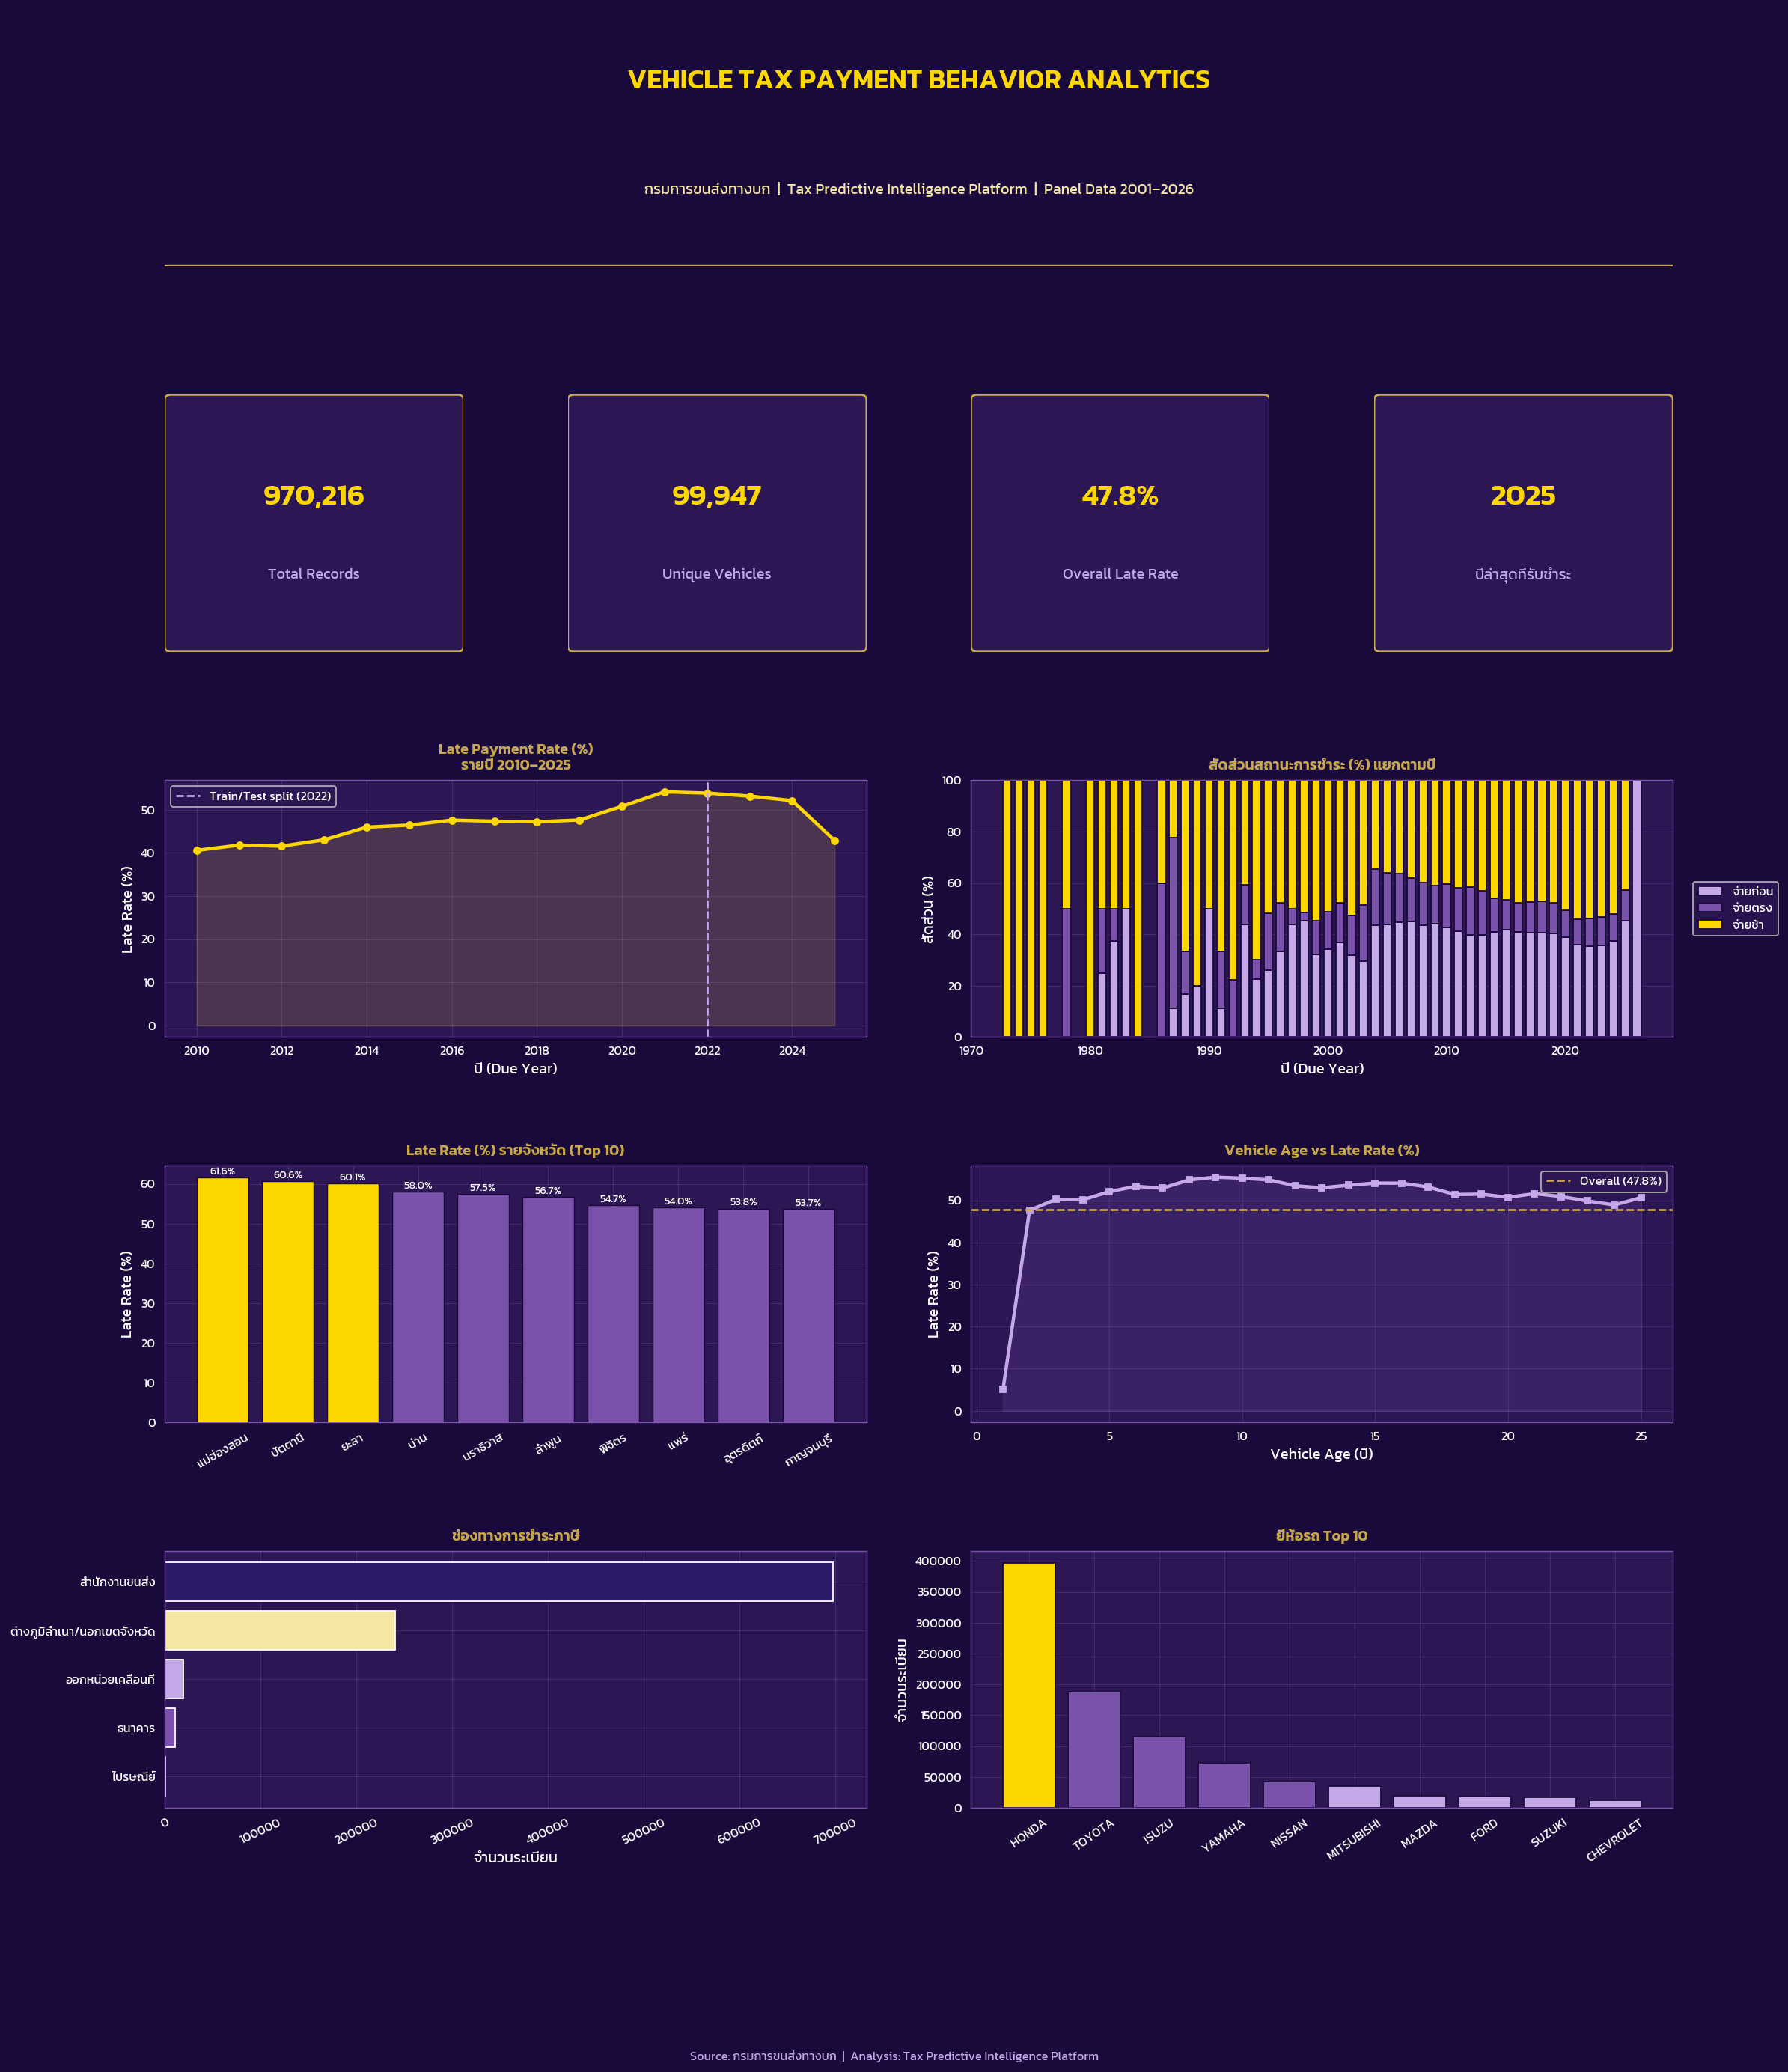

✅ Dashboard saved → dlt_dashboard_clean.png


In [40]:
# ─── Data Preparation สำหรับกราฟใหม่ ───────────────────────────────────────
# 1. หาปีล่าสุดที่มีการรับชำระ
if 'Payment_Date' in df.columns:
    pay_years = pd.to_datetime(df['Payment_Date'], dayfirst=True, errors='coerce').dt.year
    latest_pay_year = int(pay_years.max())
else:
    latest_pay_year = int(df['Due_Year'].max()) if 'Due_Year' in df.columns else 2024

# 2. เตรียมข้อมูลสัดส่วนสถานะรายปี (100% Stacked Bar)
if 'Status' in df.columns and 'Due_Year' in df.columns:
    yearly_status = df.groupby(['Due_Year', 'Status']).size().unstack(fill_value=0)
    yearly_status_pct = yearly_status.div(yearly_status.sum(axis=1), axis=0) * 100
else:
    yearly_status_pct = pd.DataFrame()

# ─────────────────────────────────────────────────────────────────────────────
# DASHBOARD: Matplotlib Professional (DLT Brand) - No Emojis
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

fig = plt.figure(figsize=(20, 24), facecolor=DLT["bg_dark"])
gs  = GridSpec(5, 4, figure=fig, hspace=0.50, wspace=0.35)

# ── helper ──────────────────────────────────────────────────────────────────
def ax_style(ax, title="", xticks_rot=0):
    ax.set_facecolor(DLT["bg_card"])
    for spine in ax.spines.values(): spine.set_edgecolor(DLT["purple_mid"])
    ax.tick_params(colors=DLT["white"], labelsize=9)
    ax.xaxis.label.set_color(DLT["white"])
    ax.yaxis.label.set_color(DLT["white"])
    if title:
        ax.set_title(title, color=DLT["gold_main"], fontsize=11, pad=8, fontweight="bold")
    if xticks_rot:
        ax.tick_params(axis="x", rotation=xticks_rot)
    ax.grid(color=DLT["purple_light"], alpha=0.15, linewidth=0.6)

# ── ROW 0: Header bar ───────────────────────────────────────────────────────
ax_hdr = fig.add_subplot(gs[0, :])
ax_hdr.set_facecolor(DLT["purple_main"])
ax_hdr.set_xlim(0,1); ax_hdr.set_ylim(0,1)
ax_hdr.axis("off")
ax_hdr.text(0.5, 0.72, "VEHICLE TAX PAYMENT BEHAVIOR ANALYTICS",
    transform=ax_hdr.transAxes, ha="center", va="center",
    color=DLT["gold_bright"], fontsize=20, fontweight="bold")
ax_hdr.text(0.5, 0.30, "กรมการขนส่งทางบก  |  Tax Predictive Intelligence Platform  |  Panel Data 2001–2026",
    transform=ax_hdr.transAxes, ha="center", va="center",
    color=DLT["gold_light"], fontsize=11)
# Gold line accent
ax_hdr.axhline(0.0, color=DLT["gold_main"], linewidth=3)

# ── ROW 1: KPI Cards (5 cards) ───────────────────────────────────────────────
kpis = [
    (f"{total_records:,}", "Total Records"),
    (f"{total_vehicles:,}", "Unique Vehicles"),
    (f"{overall_late:.1f}%", "Overall Late Rate"),
    (f"฿{avg_tax:,.0f}", "Avg Tax Amount"),
    (f"{latest_pay_year}", "ปีล่าสุดที่รับชำระ"), # <-- อัปเดตแล้ว
]
for col_i, (val, label) in enumerate(kpis):
    ax_k = fig.add_subplot(gs[1, col_i] if col_i < 4 else gs[1, 3])
    ax_k.set_facecolor(DLT["bg_card"])
    ax_k.set_xlim(0,1); ax_k.set_ylim(0,1); ax_k.axis("off")
    for spine in ax_k.spines.values(): spine.set_edgecolor(DLT["gold_main"]); spine.set_linewidth(1.5)
    ax_k.set_visible(True)

    ax_k.text(0.5, 0.60, val,  ha="center", va="center",
              transform=ax_k.transAxes, color=DLT["gold_bright"],
              fontsize=22, fontweight="bold")
    ax_k.text(0.5, 0.30, label, ha="center", va="center",
              transform=ax_k.transAxes, color=DLT["purple_light"], fontsize=11)

    rect = mpatches.FancyBboxPatch((0.02,0.02), 0.96, 0.96,
        boxstyle="round,pad=0.02", linewidth=1.5,
        edgecolor=DLT["gold_main"], facecolor=DLT["bg_card"],
        transform=ax_k.transAxes, zorder=-1)
    ax_k.add_patch(rect)

# ── ROW 2, COL 0-1: Late Rate Trend ─────────────────────────────────────────
ax1 = fig.add_subplot(gs[2, :2])
ax_style(ax1, "Late Payment Rate (%)\nรายปี 2010–2025")
ax1.fill_between(yr_late["Due_Year"], yr_late["late_pct"],
                 alpha=0.20, color=DLT["gold_main"])
ax1.plot(yr_late["Due_Year"], yr_late["late_pct"],
         color=DLT["gold_bright"], linewidth=2.5, marker="o", markersize=5)
# ป้องกัน Error ถ้าไม่มีตัวแปร TRAIN_CUTOFF
if 'TRAIN_CUTOFF' in globals():
    ax1.axvline(TRAIN_CUTOFF, color=DLT["purple_light"], linestyle="--", linewidth=1.5,
                label=f"Train/Test split ({TRAIN_CUTOFF})")
ax1.set_xlabel("ปี (Due Year)")
ax1.set_ylabel("Late Rate (%)")
ax1.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=9)

# ── ROW 2, COL 2-3: Status Stacked Bar ───────────────────────────────────────
ax2 = fig.add_subplot(gs[2, 2:])
ax_style(ax2, "สัดส่วนสถานะการชำระ (%) แยกตามปี")

if not yearly_status_pct.empty:
    status_colors = {
        'จ่ายช้า': DLT["gold_bright"],
        'จ่ายตรง': DLT["purple_mid"],
        'จ่ายก่อน': DLT["purple_light"]
    }
    ordered_statuses = [s for s in ['จ่ายก่อน', 'จ่ายตรง', 'จ่ายช้า'] if s in yearly_status_pct.columns]
    bottom_vals = np.zeros(len(yearly_status_pct))

    for status in ordered_statuses:
        values = yearly_status_pct[status]
        ax2.bar(yearly_status_pct.index, values, bottom=bottom_vals,
                color=status_colors.get(status, DLT["white"]),
                edgecolor=DLT["bg_dark"], width=0.7, label=status)
        bottom_vals += values

    ax2.set_xlabel("ปี (Due Year)")
    ax2.set_ylabel("สัดส่วน (%)")
    ax2.set_ylim(0, 100)
    ax2.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"],
               fontsize=9, loc='center left', bbox_to_anchor=(1.02, 0.5))

# ── ROW 3, COL 0-1: Province Late Rate ───────────────────────────────────────
ax3 = fig.add_subplot(gs[3, :2])
ax_style(ax3, "Late Rate (%) รายจังหวัด (Top 10)", xticks_rot=30)
bar_colors = [DLT["gold_bright"] if i < 3 else DLT["purple_mid"]
              for i in range(len(prov_late))]
ax3.bar(prov_late["Province"], prov_late["late_pct"],
        color=bar_colors, edgecolor=DLT["bg_dark"], linewidth=0.8)
ax3.set_ylabel("Late Rate (%)")
for i, (_, row) in enumerate(prov_late.iterrows()):
    ax3.text(i, row["late_pct"]+0.3, f'{row["late_pct"]:.1f}%',
             ha="center", va="bottom", color=DLT["white"], fontsize=8)

# ── ROW 3, COL 2-3: Vehicle Age vs Late Rate ─────────────────────────────────
ax4 = fig.add_subplot(gs[3, 2:])
ax_style(ax4, "Vehicle Age vs Late Rate (%)")
ax4.fill_between(age_late.index, age_late.values, alpha=0.20, color=DLT["purple_mid"])
ax4.plot(age_late.index, age_late.values,
         color=DLT["purple_light"], linewidth=2.5, marker="s", markersize=4)
ax4.axhline(overall_late, color=DLT["gold_main"], linestyle="--", linewidth=1.5,
            label=f"Overall ({overall_late:.1f}%)")
ax4.set_xlabel("Vehicle Age (ปี)")
ax4.set_ylabel("Late Rate (%)")
ax4.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=9)

# ── ROW 4: Payment Channel + Brand Top 10 ─────────────────────────────────────
# Channel
ax5 = fig.add_subplot(gs[4, :2])
ax_style(ax5, "ช่องทางการชำระภาษี", xticks_rot=25)
ch_cnt2 = df["Payment_Chanel"].value_counts().head(5) if "Payment_Chanel" in df.columns else pd.Series()
if len(ch_cnt2):
    ax5.barh(ch_cnt2.index[::-1], ch_cnt2.values[::-1],
             color=[DLT["gold_main"], DLT["purple_mid"],
                    DLT["purple_light"], DLT["gold_light"],
                    DLT["purple_deep"]][:len(ch_cnt2)])
    ax5.set_xlabel("จำนวนระเบียน")

# Brand
ax6 = fig.add_subplot(gs[4, 2:])
ax_style(ax6, "ยี่ห้อรถ Top 10", xticks_rot=35)
if "Brand" in df.columns:
    brand_cnt = df["Brand"].value_counts().head(10)
    ax6.bar(brand_cnt.index, brand_cnt.values,
            color=[DLT["gold_bright"] if i==0 else
                   DLT["purple_mid"] if i < 5 else
                   DLT["purple_light"] for i in range(len(brand_cnt))],
            edgecolor=DLT["bg_dark"])
    ax6.set_ylabel("จำนวนระเบียน")

# Title overall
fig.text(0.5, 0.002,
    "Source: กรมการขนส่งทางบก  |  Analysis: Tax Predictive Intelligence Platform",
    ha="center", color=DLT["purple_light"], fontsize=9)

plt.savefig("dlt_dashboard_clean.png", bbox_inches="tight", dpi=160,
            facecolor=DLT["bg_dark"])
plt.show()
print("✅ Dashboard saved → dlt_dashboard_clean.png")

In [41]:
import seaborn as sns

# ตรวจสอบก่อนว่ามีคอลัมน์ Vehicle_Type ใน Dataset หรือไม่
if 'Vehicle_Type' in df.columns:

    # ── 1. ดู Unique Vehicle Type ทั้งหมดพร้อมจำนวนรวม ──
    print("🚗 สรุปจำนวนรถแยกตามประเภท (Vehicle Type):")
    veh_counts = df['Vehicle_Type'].value_counts().reset_index()
    veh_counts.columns = ['Vehicle_Type', 'Total_Count']
    display(veh_counts)

    # ── 2. ดู Distribution รายจังหวัด (Cross Tabulation) ──
    # ใช้ Province (หรือ Owner_Province ตามที่มีในข้อมูล)
    prov_col = 'Province' if 'Province' in df.columns else 'Owner_Province'

    # สร้างตาราง Pivot นับจำนวนรถแต่ละประเภทในแต่ละจังหวัด
    veh_prov_dist = pd.crosstab(df[prov_col], df['Vehicle_Type'])

    print(f"\n📍 ตารางแสดง Distribution ของ Vehicle Type รายจังหวัด ({prov_col}):")
    display(veh_prov_dist.head(10)) # แสดงตัวอย่าง 10 จังหวัดแรก



🚗 สรุปจำนวนรถแยกตามประเภท (Vehicle Type):


,Vehicle_Type,Total_Count
0,รถจักรยานยนต์,428672
1,รถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน,293482
2,รถยนต์บรรทุกส่วนบุคคล,218574
3,รถยนต์นั่งส่วนบุคคลเกิน 7 คน,11847
4,รถแทร็กเตอร์,9877
5,รถใช้ในงานเกษตรกรรม,2373
6,รถจักรยานยนต์สาธารณะ,2076
7,รถยนต์รับจ้างบรรทุกคนโดยสารไม่เกิน 7 คน,1836
8,รถยนต์รับจ้างสามล้อ,628
9,รถบดถนน,429



📍 ตารางแสดง Distribution ของ Vehicle Type รายจังหวัด (Province):


Vehicle_Type,รถจักรยานยนต์,รถจักรยานยนต์สาธารณะ,รถบดถนน,รถพ่วง,รถยนต์นั่งส่วนบุคคลเกิน 7 คน,รถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน,รถยนต์บรรทุกส่วนบุคคล,รถยนต์บริการทัศนาจร,รถยนต์บริการธุรกิจ,รถยนต์รับจ้างบรรทุกคนโดยสารไม่เกิน 7 คน,รถยนต์รับจ้างสามล้อ,รถยนต์สามล้อส่วนบุคคล,รถยนต์สี่ล้อเล็กรับจ้าง (โดยสารไม่เกิน 7 คน),รถแทร็กเตอร์,รถใช้ในงานเกษตรกรรม
Province,,,,,,,,,,,,,,,
กระบี่,2572,1,12,0,43,1570,1658,24,0,0,0,0,0,0,0
กรุงเทพมหานคร,70407,877,170,139,5751,136552,39726,4,1,1774,272,16,17,1623,0
กาญจนบุรี,5194,6,0,0,86,2053,2663,0,0,0,0,0,0,116,0
กาฬสินธุ์,2194,0,0,0,108,1225,2288,0,0,0,0,0,0,128,1
กำแพงเพชร,5203,0,0,0,63,1480,2598,0,0,0,0,0,0,328,5
ขอนแก่น,6948,0,4,0,174,5971,5935,0,0,0,0,0,0,212,1
จันทบุรี,4600,0,0,0,74,2146,3224,0,0,0,0,0,0,61,0
ฉะเชิงเทรา,4608,12,0,0,119,2078,2573,0,0,0,60,0,0,65,0
ชลบุรี,18888,153,0,0,254,8991,6149,0,0,0,41,0,0,109,0


🚗 สรุปข้อมูลประเภทรถ (สัดส่วน) และ อัตราการจ่ายช้า (Late Rate):


,Vehicle_Type,Total_Count,%_of_Total,Late_Rate_Pct
0,รถใช้ในงานเกษตรกรรม,2373,0.24,63.42
1,รถจักรยานยนต์,428672,44.18,57.98
2,รถจักรยานยนต์สาธารณะ,2076,0.21,47.35
3,รถยนต์สามล้อส่วนบุคคล,34,0.00,47.06
4,รถยนต์บรรทุกส่วนบุคคล,218574,22.53,43.10
5,รถยนต์นั่งส่วนบุคคลเกิน 7 คน,11847,1.22,40.58
6,รถยนต์บริการทัศนาจร,115,0.01,37.39
7,รถยนต์นั่งส่วนบุคคลไม่เกิน 7 คน,293482,30.25,37.31
8,รถยนต์รับจ้างสามล้อ,628,0.06,36.62
9,รถพ่วง,200,0.02,36.00


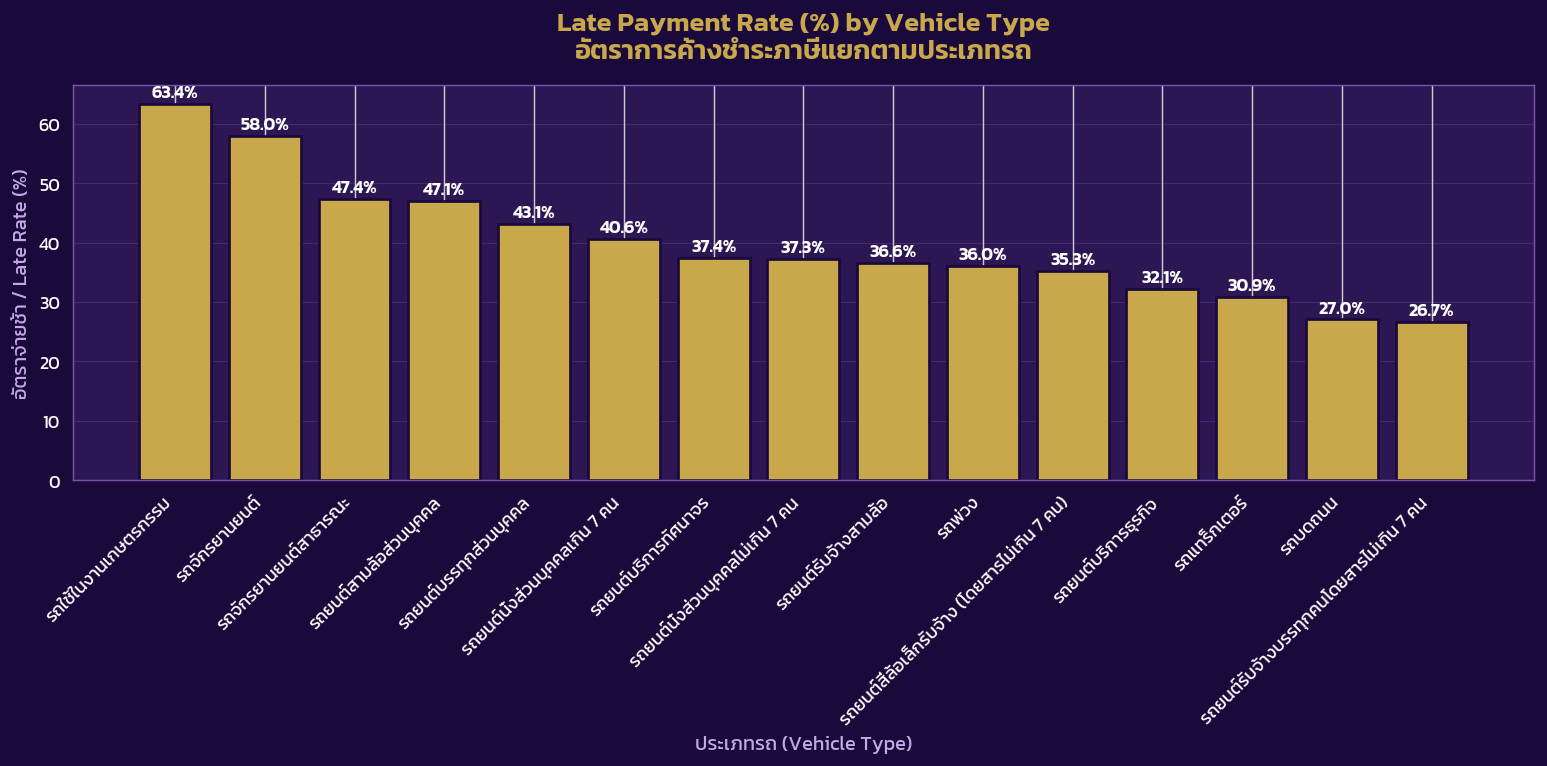

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# ตรวจสอบก่อนว่ามีคอลัมน์ที่ต้องใช้หรือไม่ (ใช้ Target_Is_Late ที่สร้างไว้จากขั้นตอน Feature Engineering)
if 'Vehicle_Type' in df.columns and 'Target_Is_Late' in df.columns:

    # ── 1. สร้างตารางสรุป: จำนวนรวม, สัดส่วน %, และ Late Rate % ──
    print("🚗 สรุปข้อมูลประเภทรถ (สัดส่วน) และ อัตราการจ่ายช้า (Late Rate):")

    # คำนวณจำนวนและสัดส่วน %
    veh_counts = df['Vehicle_Type'].value_counts().reset_index()
    veh_counts.columns = ['Vehicle_Type', 'Total_Count']
    veh_counts['%_of_Total'] = (veh_counts['Total_Count'] / len(df) * 100).round(2)

    # คำนวณ Late Rate %
    veh_late = df.groupby('Vehicle_Type')['Target_Is_Late'].mean().reset_index()
    veh_late.columns = ['Vehicle_Type', 'Late_Rate_Pct']
    veh_late['Late_Rate_Pct'] = (veh_late['Late_Rate_Pct'] * 100).round(2)

    # รวมตารางเข้าด้วยกันและเรียงตาม Late Rate (จากจ่ายช้ามากไปน้อย)
    veh_summary = pd.merge(veh_counts, veh_late, on='Vehicle_Type')
    veh_summary = veh_summary.sort_values('Late_Rate_Pct', ascending=False).reset_index(drop=True)

    display(veh_summary)

    # ── 2. พล็อต Bar Chart แสดง Late Rate แยกตามประเภทรถ ──
    plt.figure(figsize=(12, 6), facecolor=DLT["bg_dark"])
    ax = plt.axes()
    ax.set_facecolor(DLT["bg_card"])

    # สร้าง Bar Chart สีทองสว่าง
    bars = ax.bar(veh_summary['Vehicle_Type'], veh_summary['Late_Rate_Pct'],
                  color=DLT["gold_main"], edgecolor=DLT["bg_dark"], linewidth=1.5)

    # ปรับแต่ง Text และ Title
    plt.title('Late Payment Rate (%) by Vehicle Type\nอัตราการค้างชำระภาษีแยกตามประเภทรถ',
              color=DLT["gold_main"], fontsize=15, pad=15, fontweight="bold")
    plt.xlabel('ประเภทรถ (Vehicle Type)', color=DLT["purple_light"], fontsize=11)
    plt.ylabel('อัตราจ่ายช้า / Late Rate (%)', color=DLT["purple_light"], fontsize=11)

    # ปรับสีแกน
    ax.tick_params(colors=DLT["white"], labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor(DLT["purple_mid"])

    # ใส่ตัวเลข % ไว้บนหัวแท่งกราฟให้ผู้บริหารดูง่ายๆ
    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'{yval:.1f}%',
                ha='center', va='bottom', color=DLT["white"], fontsize=10, fontweight='bold')

    plt.xticks(rotation=45, ha='right')
    ax.grid(color=DLT["purple_light"], alpha=0.15, linewidth=0.6, axis='y') # แสดง Grid เฉพาะแนวนอน

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ ไม่พบคอลัมน์ 'Vehicle_Type' หรือ 'Target_Is_Late' ใน DataFrame ครับ")

## 🔍 3. Deeper EDA – Panel Behavior Analysis

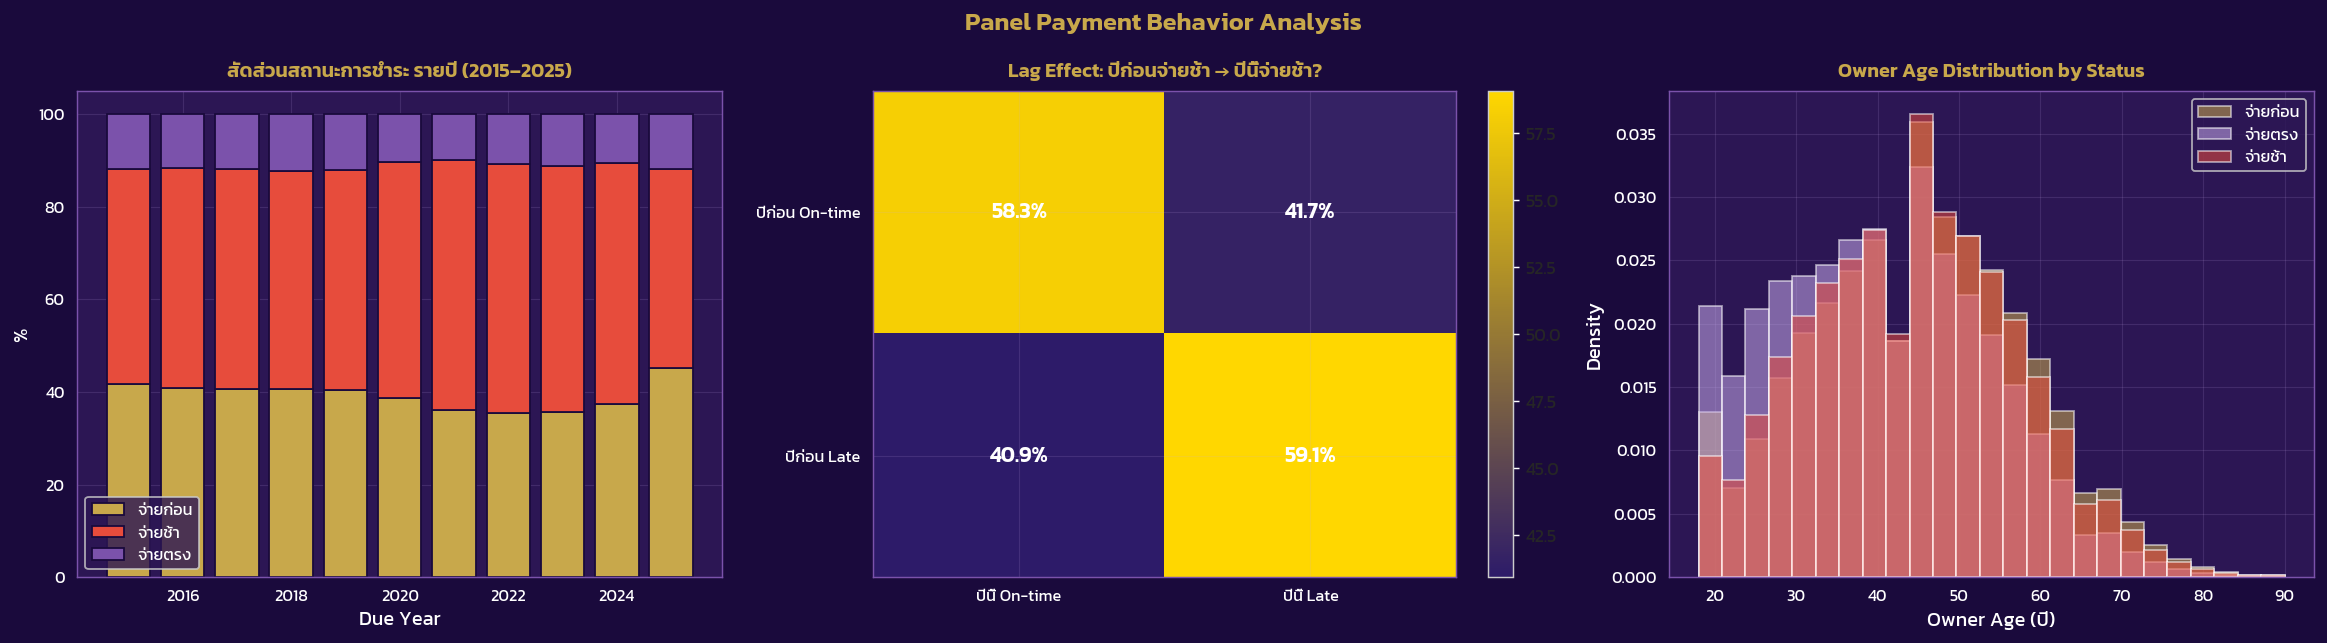

In [43]:
# ─── Payment Behavior Trend + YoY Transition ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=DLT["bg_dark"])
fig.suptitle("Panel Payment Behavior Analysis", color=DLT["gold_main"],
             fontsize=14, fontweight="bold")

# 1. Stacked status by year
ax = axes[0]; ax_style(ax, "สัดส่วนสถานะการชำระ รายปี (2015–2025)")
yr_status = (df[df["Due_Year"].between(2015,2025)]
             .groupby(["Due_Year","Status"]).size().unstack(fill_value=0))
yr_status_pct = yr_status.div(yr_status.sum(axis=1), axis=0) * 100
status_colors = {"จ่ายก่อน": DLT["gold_main"], "จ่ายตรง": DLT["purple_mid"], "จ่ายช้า": "#E74C3C"}
bottom = np.zeros(len(yr_status_pct))
for col_name in yr_status_pct.columns:
    ax.bar(yr_status_pct.index, yr_status_pct[col_name],
           bottom=bottom, label=col_name,
           color=status_colors.get(col_name, DLT["purple_light"]),
           edgecolor=DLT["bg_dark"])
    bottom += yr_status_pct[col_name].values
ax.set_xlabel("Due Year"); ax.set_ylabel("%")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=9)

# 2. Lag feature: Last_Is_Late → This_Year
ax = axes[1]; ax_style(ax, "Lag Effect: ปีก่อนจ่ายช้า → ปีนี้จ่ายช้า?")
lag_data = df[["Last_Is_Late","Target_Is_Late"]].dropna()
lag_cross = pd.crosstab(lag_data["Last_Is_Late"], lag_data["Target_Is_Late"], normalize="index") * 100
cmap_custom = matplotlib.colors.LinearSegmentedColormap.from_list(
    "dlt", [DLT["purple_deep"], DLT["gold_bright"]])
im = ax.imshow(lag_cross.values, cmap=cmap_custom, aspect="auto")
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(["ปีนี้ On-time","ปีนี้ Late"], color=DLT["white"])
ax.set_yticklabels(["ปีก่อน On-time","ปีก่อน Late"], color=DLT["white"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{lag_cross.values[i,j]:.1f}%',
                ha='center', va='center', color=DLT["white"], fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046).ax.yaxis.set_tick_params(color=DLT["white"])

# 3. Owner age density
ax = axes[2]; ax_style(ax, "Owner Age Distribution by Status")
for status, color in [("จ่ายก่อน", DLT["gold_main"]),
                       ("จ่ายตรง",  DLT["purple_light"]),
                       ("จ่ายช้า",  "#E74C3C")]:
    data = df[df["Status"] == status]["Owner_Age"].dropna()
    ax.hist(data, bins=25, alpha=0.55, color=color, label=status, density=True)
ax.set_xlabel("Owner Age (ปี)"); ax.set_ylabel("Density")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=9)

plt.tight_layout()
plt.savefig("eda_panel.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()


## 🎯 4. K-Means Customer Segmentation

  K=2: Silhouette=0.1628
  K=3: Silhouette=0.1640
  K=4: Silhouette=0.1628
  K=5: Silhouette=0.1643
  K=6: Silhouette=0.1644
  K=7: Silhouette=0.1729
  K=8: Silhouette=0.1608

✅ Best K = 7 (Silhouette=0.1729)


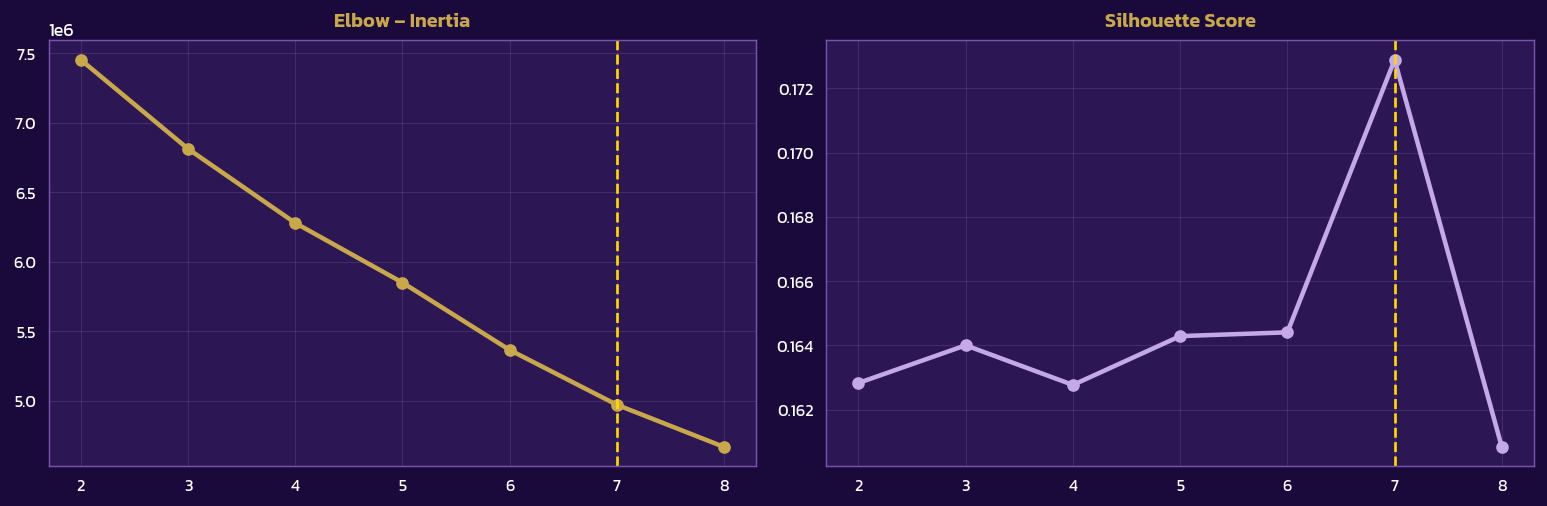

In [44]:
# ─── Clustering ───────────────────────────────────────────────────────────────
cl_feats = [f for f in ["Vehicle_Age","Owner_Age","Days_Diff_Payment","Last_Days_Diff",
                         "Cross_Province_Payment","Is_Urban","Tax_Amount","Has_Penalty",
                         "Last_Is_Late"] if f in df.columns]

df_cl = df[cl_feats].fillna(df[cl_feats].median(numeric_only=True))
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df_cl)

K_range = range(2, 9)
sse, sil = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lab = km.fit_predict(X_cl)
    sse.append(km.inertia_)
    sil.append(silhouette_score(X_cl, lab, sample_size=min(5000,len(X_cl))))
    print(f"  K={k}: Silhouette={sil[-1]:.4f}")

best_k = list(K_range)[sil.index(max(sil))]
print(f"\n✅ Best K = {best_k} (Silhouette={max(sil):.4f})")

fig, axs = plt.subplots(1, 2, figsize=(12, 4), facecolor=DLT["bg_dark"])
for ax, y_data, title, color in zip(axs,
        [sse, sil],
        ["Elbow – Inertia", "Silhouette Score"],
        [DLT["gold_main"], DLT["purple_light"]]):
    ax_style(ax, title)
    ax.plot(list(K_range), y_data, "o-", color=color, linewidth=2.5)
    ax.axvline(best_k, color=DLT["gold_bright"], linestyle="--", linewidth=1.5)
plt.tight_layout()
plt.savefig("kmeans.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()


In [45]:
# ─── Fit & Profile ────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=20)
df["Cluster"] = km_final.fit_predict(X_cl)

profile = df.groupby("Cluster").agg(
    n         =("Target_Is_Late","count"),
    late_pct  =("Target_Is_Late", lambda x: x.mean()*100),
    avg_age   =("Vehicle_Age","mean"),
    avg_own   =("Owner_Age","mean"),
    avg_days  =("Days_Diff_Payment","mean"),
    cross_pct =("Cross_Province_Payment", lambda x: x.mean()*100),
    last_late =("Last_Is_Late", lambda x: x.mean()*100),
).round(1)

def seg_name(r):
    if r.late_pct < 25: return "🟢 Excellent"
    elif r.late_pct < 40: return "🟡 Occasional Late"
    elif r.late_pct < 55: return "🟠 Frequent Late"
    else: return "🔴 High-Risk Dropout"

profile["Segment"] = profile.apply(seg_name, axis=1)
df["Segment"] = df["Cluster"].map(profile["Segment"].to_dict())
display(profile)


,n,late_pct,avg_age,avg_own,avg_days,cross_pct,last_late,Segment
Cluster,,,,,,,,
0,80417,74.2,7.6,41.8,75.0,23.5,22.7,🔴 High-Risk Dropout
1,55439,24.5,4.7,41.0,-0.2,24.0,31.2,🟢 Excellent
2,55200,100.0,9.1,43.3,513.2,27.6,28.9,🔴 High-Risk Dropout
3,191514,54.9,7.0,43.0,20.3,0.0,100.0,🟠 Frequent Late
4,196734,47.9,8.1,42.9,14.6,100.0,37.8,🟠 Frequent Late
5,116409,43.0,20.8,57.0,14.7,12.5,19.8,🟠 Frequent Late
6,274503,31.2,5.6,41.3,4.8,0.0,0.0,🟡 Occasional Late


---
## 🔁 5. Rolling-Window Train/Test Split (Anti-Leakage)

> **Panel Data ต้องระวัง Data Leakage!**  
> ถ้า split แบบ random จะมีข้อมูลอนาคตรั่วไปในชุด train  
> วิธีที่ถูกต้อง: **Train = Due_Year ≤ 2022 | Test = 2023–2025**  
> Feature ที่ใช้ทำนายปีนี้ = ข้อมูลของ "ปีก่อน" เท่านั้น (no leakage)


In [46]:
# ─── Feature Sets – Pre-Payment Only (no leakage) ────────────────────────────
NUM_FEATS = [f for f in [
    "Vehicle_Age","Owner_Age",
    "Last_Is_Late","Last_Is_Early","Last_Days_Diff","Last_Tax_Amount",
    "Tax_Amount","Engine_CC","No_Seats","Hourse_Power",
] if f in df.columns]

BIN_FEATS = [f for f in [
    "Is_Urban","Nationality_Match"
] if f in df.columns]

CAT_FEATS = [f for f in ["Fuel_Type","Brand"] if f in df.columns]

ALL_FEATS = NUM_FEATS + BIN_FEATS + CAT_FEATS

# ── Targets ────────────────────────────────────────────────────────────────────
TARGET_BIN  = "Target_Is_Late"          # Binary: 0=ตรง, 1=ล่าช้าทุกรูปแบบ
TARGET_MULTI= "Seg_Code"                # Multiclass: 1,2,3,4
TARGET_REG  = "Days_Late_Actual"        # Regression: จำนวนวันล่าช้า (สำหรับกลุ่มที่ล่าช้า)

print(f"Features: {len(ALL_FEATS)} total")
print(f"  Numerical ({len(NUM_FEATS)}): {NUM_FEATS}")
print(f"  Binary    ({len(BIN_FEATS)}): {BIN_FEATS}")
print(f"  Categorical ({len(CAT_FEATS)}): {CAT_FEATS}")
print(f"\nTargets:")
print(f"  Binary     → {TARGET_BIN}  | Late Rate = {df[TARGET_BIN].mean()*100:.1f}%")
print(f"  Multiclass → {TARGET_MULTI} | Classes = {sorted(df[TARGET_MULTI].unique())}")
print(f"  Regression → {TARGET_REG}  | (late records only)")

# ── Rolling-Window Split ──────────────────────────────────────────────────────
df_valid = df.dropna(subset=[TARGET_BIN, TARGET_MULTI]).copy()
df_train = df_valid[df_valid["Due_Year"] <= TRAIN_CUTOFF]
df_test  = df_valid[df_valid["Due_Year"]  > TRAIN_CUTOFF]

X_train = df_train[ALL_FEATS]
y_train_bin  = df_train[TARGET_BIN].astype(int)
y_train_multi= df_train[TARGET_MULTI].astype(int)
y_train_reg  = df_train[TARGET_REG]

X_test  = df_test[ALL_FEATS]
y_test_bin   = df_test[TARGET_BIN].astype(int)
y_test_multi = df_test[TARGET_MULTI].astype(int)
y_test_reg   = df_test[TARGET_REG]

# Regression: ใช้เฉพาะ late records (Days_Late_Actual > 0)
late_train_mask = y_train_reg > 0
late_test_mask  = y_test_reg  > 0
X_train_reg = X_train[late_train_mask]
y_train_reg = y_train_reg[late_train_mask]
X_test_reg  = X_test[late_test_mask]
y_test_reg  = y_test_reg[late_test_mask]

# Aliases for backward-compat with existing binary model cells
y_train = y_train_bin
y_test  = y_test_bin

print(f"\nTrain: {len(X_train):,} | Test: {len(X_test):,}")
print(f"Regression train (late only): {len(X_train_reg):,} | test: {len(X_test_reg):,}")


# ─── Quick Mode: stratified sample ───────────────────────────────────────────
if QUICK_MODE and len(X_train) > QUICK_N:
    from sklearn.utils import resample
    _idx = resample(range(len(X_train)), n_samples=QUICK_N,
                    stratify=y_train, random_state=RANDOM_STATE)
    X_train_q = X_train.iloc[_idx]; y_train_q = y_train.iloc[_idx]
    X_test_q  = X_test.iloc[:min(1500, len(X_test))]
    y_test_q  = y_test.iloc[:min(1500, len(y_test))]
    print(f"QUICK MODE: Train={len(X_train_q):,} | Test={len(X_test_q):,}")
else:
    X_train_q, y_train_q = X_train, y_train
    X_test_q,  y_test_q  = X_test,  y_test
    print(f"FULL MODE: Train={len(X_train_q):,} | Test={len(X_test_q):,}")

# ─── Comprehensive Evaluation Helper ─────────────────────────────────────────
import json as _json
from sklearn.metrics import (roc_auc_score, f1_score, recall_score,
                              precision_score, accuracy_score,
                              confusion_matrix, classification_report)

BEST_PARAMS_LOG = {}   # เก็บ best params ทุกโมเดล

def full_eval(name, y_true, y_proba, params=None, threshold=0.5):
    """คำนวณ metrics ครบชุด + บันทึก best params"""
    y_pred = (y_proba >= threshold).astype(int)
    metrics = dict(
        AUC       = roc_auc_score(y_true, y_proba),
        F1        = f1_score(y_true, y_pred, zero_division=0),
        Precision = precision_score(y_true, y_pred, zero_division=0),
        Recall    = recall_score(y_true, y_pred, zero_division=0),
        Accuracy  = accuracy_score(y_true, y_pred),
    )
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0,0,0,0)
    metrics.update(dict(TN=int(tn), FP=int(fp), FN=int(fn), TP=int(tp)))
    metrics['Specificity'] = tn/(tn+fp) if (tn+fp)>0 else 0

    if params:
        BEST_PARAMS_LOG[name] = params

    # Print
    print(f"\n{'='*52}")
    print(f"  {name}")
    print(f"{'='*52}")
    print(f"  AUC={metrics['AUC']:.4f} | F1={metrics['F1']:.4f} | Acc={metrics['Accuracy']:.4f}")
    print(f"  Precision={metrics['Precision']:.4f} | Recall={metrics['Recall']:.4f} | Specificity={metrics['Specificity']:.4f}")
    print(f"  Confusion Matrix: TP={tp} FP={fp} FN={fn} TN={tn}")
    if params:
        p_str = _json.dumps(params, indent=2, ensure_ascii=False, default=str)
        print(f"  Best Params:\n{p_str}")
    return metrics

def plot_confusion_matrix_dlt(cm, title, ax, labels=None):
    """Plot confusion matrix ด้วย DLT theme"""
    import matplotlib.colors as mcolors
    import numpy as np
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "dlt", [DLT["purple_deep"], DLT["gold_bright"]])
    ax.imshow(cm, cmap=cmap, aspect="auto")
    ax_style(ax, title)
    n = cm.shape[0]
    lbs = labels or [str(i) for i in range(n)]
    ax.set_xticks(range(n)); ax.set_xticklabels(lbs, color=DLT["white"], rotation=15, fontsize=9)
    ax.set_yticks(range(n)); ax.set_yticklabels(lbs, color=DLT["white"], fontsize=9)
    ax.set_xlabel("Predicted", color=DLT["white"])
    ax.set_ylabel("Actual",    color=DLT["white"])
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{cm[i,j]:,}", ha="center", va="center",
                    color=DLT["white"], fontsize=10, fontweight="bold")

print("\n✅ Helpers ready: full_eval(), plot_confusion_matrix_dlt()")
print(f"   BEST_PARAMS_LOG will accumulate after each model")


Features: 14 total
  Numerical (10): ['Vehicle_Age', 'Owner_Age', 'Last_Is_Late', 'Last_Is_Early', 'Last_Days_Diff', 'Last_Tax_Amount', 'Tax_Amount', 'Engine_CC', 'No_Seats', 'Hourse_Power']
  Binary    (2): ['Is_Urban', 'Nationality_Match']
  Categorical (2): ['Fuel_Type', 'Brand']

Targets:
  Binary     → Target_Is_Late  | Late Rate = 47.8%
  Multiclass → Seg_Code | Classes = [np.int64(1), np.int64(2), np.int64(3)]
  Regression → Days_Late_Actual  | (late records only)

Train: 742,221 | Test: 227,995
Regression train (late only): 349,945 | test: 113,626
QUICK MODE: Train=5,000 | Test=1,500

✅ Helpers ready: full_eval(), plot_confusion_matrix_dlt()
   BEST_PARAMS_LOG will accumulate after each model


In [47]:
# ─── Preprocessing Pipeline ───────────────────────────────────────────────────
num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")),
                     ("sc",  StandardScaler())])
bin_pipe = SimpleImputer(strategy="most_frequent")
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])

preprocessor = ColumnTransformer([
    ("num", num_pipe, NUM_FEATS),
    ("bin", bin_pipe, BIN_FEATS),
    ("cat", cat_pipe, CAT_FEATS),
], remainder="drop")

prep = preprocessor.fit(X_train)
X_tr = prep.transform(X_train)
X_te = prep.transform(X_test)

scale_pos = (y_train == 0).sum() / (y_train == 1).sum()
print(f"✅ Preprocessed shapes: Train={X_tr.shape} | Test={X_te.shape}")
print(f"   scale_pos_weight = {scale_pos:.2f}")


✅ Preprocessed shapes: Train=(742221, 190) | Test=(227995, 190)
   scale_pos_weight = 1.12


## 🤖 6. Classical Models – Logistic Regression · Random Forest · XGBoost

In [48]:
from sklearn.model_selection import StratifiedKFold
results = {}

# ─── 6.1 Logistic Regression (L1) ────────────────────────────────────────────
lr_params = dict(penalty="l1", solver="saga", C=0.5,
                 max_iter=500, class_weight="balanced", random_state=RANDOM_STATE)
pipe_lr = Pipeline([("prep", preprocessor),
                    ("clf",  LogisticRegression(**lr_params))])
pipe_lr.fit(X_train_q, y_train_q)
yp_lr    = pipe_lr.predict_proba(X_test_q)[:,1]
met_lr   = full_eval("Logistic Regression (L1)", y_test_q, yp_lr, params=lr_params)
results["Logistic Regression (L1)"] = dict(proba=yp_lr, **met_lr, color=DLT["purple_light"])



  Logistic Regression (L1)
  AUC=0.7847 | F1=0.6692 | Acc=0.7087
  Precision=0.7479 | Recall=0.6055 | Specificity=0.8065
  Confusion Matrix: TP=442 FP=149 FN=288 TN=621
  Best Params:
{
  "penalty": "l1",
  "solver": "saga",
  "C": 0.5,
  "max_iter": 500,
  "class_weight": "balanced",
  "random_state": 42
}


In [49]:
# ─── 6.2 Random Forest ───────────────────────────────────────────────────────
rf_n   = 100 if QUICK_MODE else 300
rf_params = dict(n_estimators=rf_n, max_depth=10, min_samples_leaf=20,
                 class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE)
pipe_rf = Pipeline([("prep", preprocessor),
                    ("clf",  RandomForestClassifier(**rf_params))])
pipe_rf.fit(X_train_q, y_train_q)
yp_rf  = pipe_rf.predict_proba(X_test_q)[:,1]
met_rf = full_eval("Random Forest", y_test_q, yp_rf, params=rf_params)
results["Random Forest"] = dict(proba=yp_rf, **met_rf, color=DLT["purple_mid"])



  Random Forest
  AUC=0.8382 | F1=0.6846 | Acc=0.7427
  Precision=0.8482 | Recall=0.5740 | Specificity=0.9026
  Confusion Matrix: TP=419 FP=75 FN=311 TN=695
  Best Params:
{
  "n_estimators": 100,
  "max_depth": 10,
  "min_samples_leaf": 20,
  "class_weight": "balanced",
  "n_jobs": -1,
  "random_state": 42
}


In [50]:
# ─── 6.3 XGBoost + Optuna ────────────────────────────────────────────────────
from sklearn.model_selection import TimeSeriesSplit

prep_q = preprocessor.fit(X_train_q)
X_tr_q = prep_q.transform(X_train_q)
X_te_q = prep_q.transform(X_test_q)
scale_pos_q = (y_train_q == 0).sum() / max((y_train_q == 1).sum(), 1)

def xgb_obj(trial):
    p = dict(
        n_estimators     = trial.suggest_int("n_est",  100, 300 if QUICK_MODE else 600),
        max_depth        = trial.suggest_int("depth",  3, 7),
        learning_rate    = trial.suggest_float("lr",   0.02, 0.25, log=True),
        subsample        = trial.suggest_float("sub",  0.7, 1.0),
        colsample_bytree = trial.suggest_float("col",  0.6, 1.0),
        min_child_weight = trial.suggest_int("mcw",    5, 30),
        reg_lambda       = trial.suggest_float("lam",  0.1, 5.0),
        scale_pos_weight = scale_pos_q,
        eval_metric      = "auc", n_jobs=-1, random_state=RANDOM_STATE,
    )
    m = xgb.XGBClassifier(**p)
    tscv = TimeSeriesSplit(n_splits=3)
    return cross_val_score(m, X_tr_q, y_train_q, cv=tscv,
                           scoring="roc_auc", n_jobs=1).mean()

print(f"⏳ Optuna XGBoost ({N_OPTUNA} trials)...")
study_xgb = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study_xgb.optimize(xgb_obj, n_trials=N_OPTUNA, show_progress_bar=True)
best_xgb_params = study_xgb.best_params.copy()
best_xgb_params.update(dict(scale_pos_weight=scale_pos_q, eval_metric="auc",
                             n_jobs=-1, random_state=RANDOM_STATE))
print(f"Best CV AUC: {study_xgb.best_value:.4f}")

xgb_best = xgb.XGBClassifier(**best_xgb_params)
xgb_best.fit(X_tr_q, y_train_q, eval_set=[(X_te_q, y_test_q)], verbose=False)
yp_xgb  = xgb_best.predict_proba(X_te_q)[:,1]
met_xgb = full_eval("XGBoost (Optuna)", y_test_q, yp_xgb, params=best_xgb_params)
results["XGBoost (Optuna)"] = dict(proba=yp_xgb, **met_xgb, color=DLT["gold_main"])


⏳ Optuna XGBoost (5 trials)...


  0%|          | 0/5 [00:00<?, ?it/s]

Best CV AUC: 0.7501

  XGBoost (Optuna)
  AUC=0.7508 | F1=0.6404 | Acc=0.6833
  Precision=0.7157 | Recall=0.5795 | Specificity=0.7818
  Confusion Matrix: TP=423 FP=168 FN=307 TN=602
  Best Params:
{
  "n_est": 136,
  "depth": 3,
  "lr": 0.043127706008471954,
  "sub": 0.8574269294896714,
  "col": 0.7727780074568463,
  "mcw": 12,
  "lam": 3.0980791841396598,
  "scale_pos_weight": 1.1213406873143827,
  "eval_metric": "auc",
  "n_jobs": -1,
  "random_state": 42
}


In [51]:
# ─── 6.4 MLP ─────────────────────────────────────────────────────────────────
mlp_params = dict(hidden_layer_sizes=(64,32), alpha=0.001,
                  max_iter=100 if QUICK_MODE else 200,
                  early_stopping=True, validation_fraction=0.15,
                  random_state=RANDOM_STATE, verbose=False)
pipe_mlp = Pipeline([("prep", preprocessor),
                     ("clf",  MLPClassifier(**mlp_params))])
pipe_mlp.fit(X_train_q, y_train_q)
yp_mlp  = pipe_mlp.predict_proba(X_test_q)[:,1]
met_mlp = full_eval("MLP (sklearn)", y_test_q, yp_mlp, params=mlp_params)
results["MLP (sklearn)"] = dict(proba=yp_mlp, **met_mlp, color=DLT["gold_light"])



  MLP (sklearn)
  AUC=0.8080 | F1=0.6645 | Acc=0.7193
  Precision=0.7943 | Recall=0.5712 | Specificity=0.8597
  Confusion Matrix: TP=417 FP=108 FN=313 TN=662
  Best Params:
{
  "hidden_layer_sizes": [
    64,
    32
  ],
  "alpha": 0.001,
  "max_iter": 100,
  "early_stopping": true,
  "validation_fraction": 0.15,
  "random_state": 42,
  "verbose": false
}


## 🧠 7. Deep Learning Models – CNN · RNN · LSTM
### 7.1 สร้าง Time-Series Sequences สำหรับ Panel Data

> แต่ละ (ยานพาหนะ, ปี) = 1 ตัวอย่าง  
> Input = ลำดับ features ย้อนหลัง **SEQ_LEN ปี** (default=4)  
> Target = สถานะปีปัจจุบัน  
> Train sequences = ลงท้ายด้วยปี ≤ {TRAIN_CUTOFF} | Test = ลงท้ายด้วยปี > {TRAIN_CUTOFF}


In [52]:
# ─── Build Sequences ──────────────────────────────────────────────────────────
# Features ที่ใช้ต่อ time step (ไม่รวม last-year lag เพราะสร้างจาก sequence เอง)
SEQ_FEATS = [f for f in ["Vehicle_Age","Owner_Age","Days_Diff_Payment","Tax_Amount",
             "Cross_Province_Payment","Is_Urban","Has_Penalty","Is_Office",
             "Is_Mobile","Is_Cross_Ch"] if f in df.columns]

# Encode categoricals สำหรับ seq
df_seq = df_valid[["Encode_ChassisNo","Due_Year","Target_Is_Late"]+SEQ_FEATS].copy()
df_seq = df_seq.sort_values(["Encode_ChassisNo","Due_Year"]).reset_index(drop=True)
df_seq[SEQ_FEATS] = df_seq[SEQ_FEATS].apply(pd.to_numeric, errors="coerce")
df_seq[SEQ_FEATS] = df_seq[SEQ_FEATS].fillna(df_seq[SEQ_FEATS].median())

# Standardize seq features
seq_scaler = StandardScaler()
df_seq[SEQ_FEATS] = seq_scaler.fit_transform(df_seq[SEQ_FEATS])

def build_sequences(df_s, seq_len=SEQ_LEN):
    X_list, y_list, year_list = [], [], []
    for vid, grp in df_s.groupby("Encode_ChassisNo"):
        grp = grp.sort_values("Due_Year")
        feat_arr = grp[SEQ_FEATS].values.astype(np.float32)
        tgt_arr  = grp["Target_Is_Late"].values.astype(np.float32)
        yr_arr   = grp["Due_Year"].values
        for i in range(seq_len, len(grp)):
            X_list.append(feat_arr[i-seq_len:i])
            y_list.append(tgt_arr[i])
            year_list.append(yr_arr[i])   # ปีที่ทำนาย
    return np.array(X_list, dtype=np.float32), np.array(y_list), np.array(year_list)

X_seq, y_seq, yr_seq = build_sequences(df_seq, SEQ_LEN)
print(f"✅ Sequences: X={X_seq.shape} y={y_seq.shape}")

# Rolling split by target year
train_mask_seq = yr_seq <= TRAIN_CUTOFF
test_mask_seq  = yr_seq >  TRAIN_CUTOFF

X_tr_seq = X_seq[train_mask_seq];  y_tr_seq = y_seq[train_mask_seq]
X_te_seq = X_seq[test_mask_seq];   y_te_seq = y_seq[test_mask_seq]
print(f"   Train sequences: {len(X_tr_seq):,} | Late={y_tr_seq.mean()*100:.1f}%")
print(f"   Test  sequences: {len(X_te_seq):,}  | Late={y_te_seq.mean()*100:.1f}%")
N_FEATURES_SEQ = X_seq.shape[2]


✅ Sequences: X=(616585, 4, 7) y=(616585,)
   Train sequences: 448,413 | Late=53.6%
   Test  sequences: 168,172  | Late=54.4%


### 7.2 เตรียม Keras Helper Functions

In [53]:
# ─── Keras / DL Setup ────────────────────────────────────────────────────────
BATCH_SIZE = 64
ES_PATIENCE = 6

# Quick mode: ใช้ subset ของ sequences
if QUICK_MODE and len(X_tr_seq) > 3000:
    from sklearn.utils import resample as rs
    _qi = rs(range(len(X_tr_seq)), n_samples=3000,
             stratify=y_tr_seq.astype(int), random_state=RANDOM_STATE)
    X_tr_seq_q = X_tr_seq[_qi]; y_tr_seq_q = y_tr_seq[_qi]
    X_te_seq_q = X_te_seq[:min(1000,len(X_te_seq))]
    y_te_seq_q = y_te_seq[:min(1000,len(y_te_seq))]
else:
    X_tr_seq_q, y_tr_seq_q = X_tr_seq, y_tr_seq
    X_te_seq_q, y_te_seq_q = X_te_seq, y_te_seq

class_w_pos      = float((y_tr_seq_q == 0).sum()) / max(float((y_tr_seq_q == 1).sum()), 1)
class_weights_dl = {0: 1.0, 1: class_w_pos}

early_stop = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                      restore_best_weights=True)
lr_sched   = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=0)

print(f"DL sequences — Train: {len(X_tr_seq_q):,} | Test: {len(X_te_seq_q):,}")
print(f"class_pos_weight = {class_w_pos:.2f}")

def get_auc_key(hist):
    """Keras stores metric with lowercase name; handle version differences."""
    for k in hist.history.keys():
        if 'auc' in k.lower() and not k.startswith('val_'):
            return k
    return list(hist.history.keys())[1]   # fallback: second key

def eval_keras(model, X_te, y_te, name):
    yp  = model.predict(X_te, verbose=0).ravel()
    met = full_eval(name, y_te, yp,
                    params={"architecture": name,
                            "epochs_trained": len(model.history.history.get("loss",[]))})
    return yp, met

def plot_history(hist, title=""):
    auc_key = get_auc_key(hist)
    val_key = "val_" + auc_key
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), facecolor=DLT["bg_dark"])
    for ax, (train_k, val_k, label) in zip(axs, [
        ("loss",    "val_loss", "Loss"),
        (auc_key,   val_key,    "AUC"),
    ]):
        ax_style(ax, f"{title} – {label}")
        ax.plot(hist.history[train_k], color=DLT["gold_main"],    linewidth=2, label="Train")
        ax.plot(hist.history[val_k],   color=DLT["purple_light"], linewidth=2, label="Val")
        ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])
    plt.tight_layout()
    plt.show()

print("✅ Keras helpers ready (auto-detect AUC key)")


DL sequences — Train: 3,000 | Test: 1,000
class_pos_weight = 0.87
✅ Keras helpers ready (auto-detect AUC key)


### 7.3 CNN (1D Convolutional)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 4, 32)          │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 32)          │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 4, 16)          │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 16)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,225 (8.69 KB)

 Trainable params: 2,161 (8.44 KB)

 Non-trainable params: 64 (256.00 B)

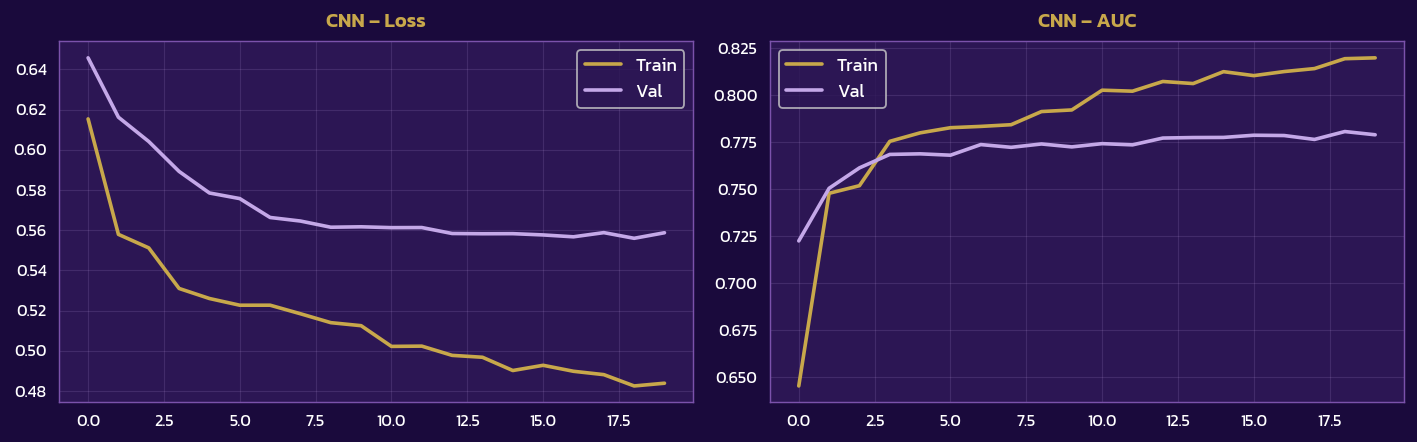


  CNN (1D Conv)
  AUC=0.7498 | F1=0.7084 | Acc=0.6880
  Precision=0.6684 | Recall=0.7535 | Specificity=0.6217
  Confusion Matrix: TP=379 FP=188 FN=124 TN=309
  Best Params:
{
  "architecture": "CNN (1D Conv)",
  "epochs_trained": 20
}


In [54]:
# ─── 1D CNN ───────────────────────────────────────────────────────────────────
def build_cnn(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.Conv1D(32, kernel_size=2, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(16, kernel_size=2, padding="same", activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.30)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])   # ← ชื่อชัดเจน
    return m

cnn_params = dict(
    filters=[32, 16], kernel_size=2, dense_units=32, dropout=0.30,
    optimizer="Adam(lr=1e-3)", epochs=N_EPOCHS, batch_size=BATCH_SIZE
)
cnn_model = build_cnn(SEQ_LEN, N_FEATURES_SEQ)
cnn_model.summary()

es_cnn = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                   restore_best_weights=True)
hist_cnn = cnn_model.fit(
    X_tr_seq_q, y_tr_seq_q,
    validation_split=0.15, epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_cnn, lr_sched], class_weight=class_weights_dl, verbose=0
)
plot_history(hist_cnn, "CNN")
yp_cnn, met_cnn = eval_keras(cnn_model, X_te_seq_q, y_te_seq_q, "CNN (1D Conv)")
cnn_params["epochs_trained"] = len(hist_cnn.history["loss"])
BEST_PARAMS_LOG["CNN (1D Conv)"] = cnn_params
results["CNN (1D Conv)"] = dict(proba=yp_cnn, **met_cnn, color="#E74C3C")


### 7.4 RNN (SimpleRNN)

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 4, 32)          │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,353 (9.19 KB)

 Trainable params: 2,353 (9.19 KB)

 Non-trainable params: 0 (0.00 B)

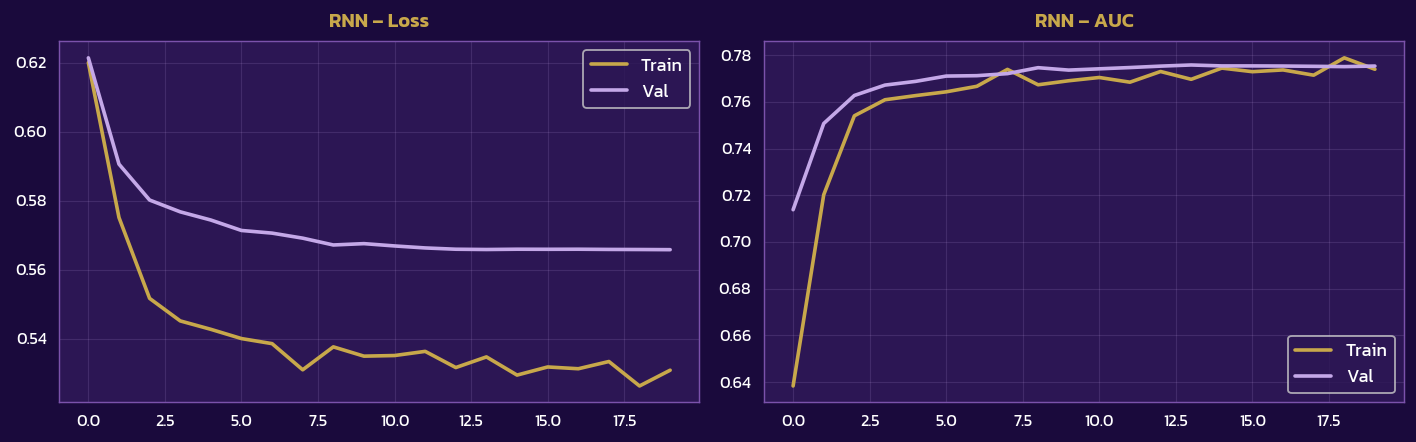


  RNN (SimpleRNN)
  AUC=0.7419 | F1=0.7185 | Acc=0.7030
  Precision=0.6866 | Recall=0.7535 | Specificity=0.6519
  Confusion Matrix: TP=379 FP=173 FN=124 TN=324
  Best Params:
{
  "architecture": "RNN (SimpleRNN)",
  "epochs_trained": 20
}


In [55]:
# ─── Simple RNN ───────────────────────────────────────────────────────────────
def build_rnn(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.SimpleRNN(32, return_sequences=True)(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.SimpleRNN(16)(x)
    x = layers.Dense(16, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])   # ← ชื่อชัดเจน
    return m

rnn_params = dict(
    rnn_units=[32, 16], dense_units=16, dropout=0.25,
    optimizer="Adam(lr=1e-3)", epochs=N_EPOCHS, batch_size=BATCH_SIZE
)
rnn_model = build_rnn(SEQ_LEN, N_FEATURES_SEQ)
rnn_model.summary()

es_rnn = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                   restore_best_weights=True)
hist_rnn = rnn_model.fit(
    X_tr_seq_q, y_tr_seq_q,
    validation_split=0.15, epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_rnn, lr_sched], class_weight=class_weights_dl, verbose=0
)
plot_history(hist_rnn, "RNN")
yp_rnn, met_rnn = eval_keras(rnn_model, X_te_seq_q, y_te_seq_q, "RNN (SimpleRNN)")
rnn_params["epochs_trained"] = len(hist_rnn.history["loss"])
BEST_PARAMS_LOG["RNN (SimpleRNN)"] = rnn_params
results["RNN (SimpleRNN)"] = dict(proba=yp_rnn, **met_rnn, color="#3498DB")


### 7.5 LSTM (Long Short-Term Memory)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 4, 7)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 4, 64)          │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         5,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,513 (64.50 KB)

 Trainable params: 16,513 (64.50 KB)

 Non-trainable params: 0 (0.00 B)

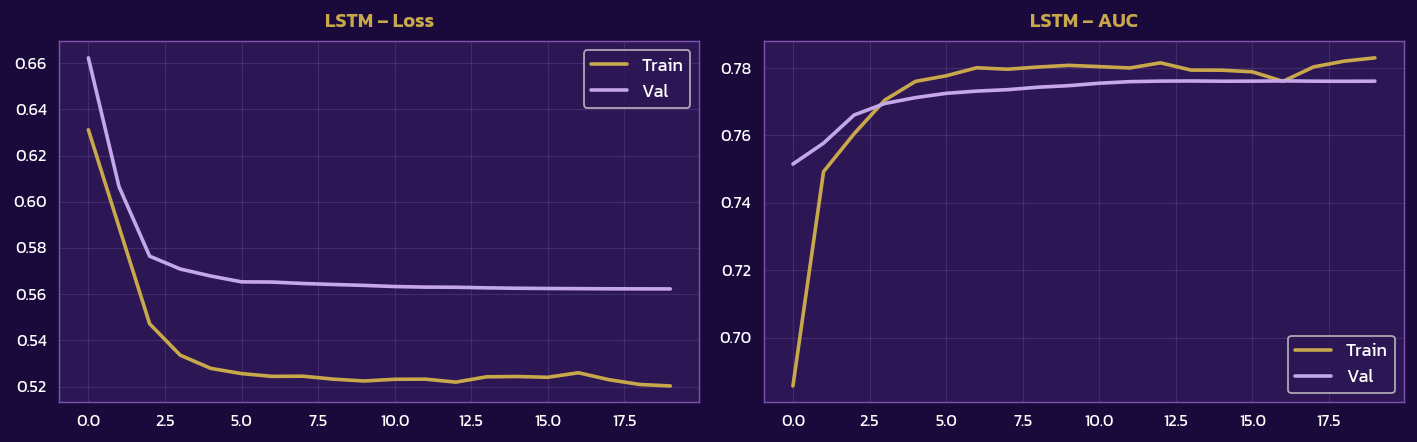


  LSTM (BiDir)
  AUC=0.7521 | F1=0.7256 | Acc=0.7080
  Precision=0.6881 | Recall=0.7674 | Specificity=0.6479
  Confusion Matrix: TP=386 FP=175 FN=117 TN=322
  Best Params:
{
  "architecture": "LSTM (BiDir)",
  "epochs_trained": 20
}


In [56]:
# ─── Bidirectional LSTM ───────────────────────────────────────────────────────
def build_lstm(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(16)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(5e-4),
              loss="binary_crossentropy",
              metrics=[keras.metrics.AUC(name="auc")])   # ← ชื่อชัดเจน
    return m

lstm_params = dict(
    bilstm_units=32, lstm_units=16, dense_units=[32,16], dropout=0.25,
    optimizer="Adam(lr=5e-4)", epochs=N_EPOCHS, batch_size=BATCH_SIZE
)
lstm_model = build_lstm(SEQ_LEN, N_FEATURES_SEQ)
lstm_model.summary()

es_lstm = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                   restore_best_weights=True)
hist_lstm = lstm_model.fit(
    X_tr_seq_q, y_tr_seq_q,
    validation_split=0.15, epochs=N_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_lstm, lr_sched], class_weight=class_weights_dl, verbose=0
)
plot_history(hist_lstm, "LSTM")
yp_lstm, met_lstm = eval_keras(lstm_model, X_te_seq_q, y_te_seq_q, "LSTM (BiDir)")
lstm_params["epochs_trained"] = len(hist_lstm.history["loss"])
BEST_PARAMS_LOG["LSTM (BiDir)"] = lstm_params
results["LSTM (BiDir)"] = dict(proba=yp_lstm, **met_lstm, color="#2ECC71")


In [57]:
# ─── Best Params Summary – Export & Display ──────────────────────────────────
import json as _json, pandas as pd

print("=" * 65)
print("   BEST PARAMS LOG – ใช้ค่าเหล่านี้สำหรับ Production Run")
print("=" * 65)
for model_name, params in BEST_PARAMS_LOG.items():
    print(f"\n▶ {model_name}")
    for k, v in params.items():
        print(f"    {k:25s} = {v}")

# Export as JSON
with open("best_params.json", "w", encoding="utf-8") as f:
    _json.dump(BEST_PARAMS_LOG, f, ensure_ascii=False, indent=2, default=str)
print("\n✅ Saved → best_params.json")

# Comprehensive metrics table
metrics_table = []
for name, r in results.items():
    row = {"Model": name}
    for k in ["AUC","F1","Precision","Recall","Accuracy","Specificity","TP","FP","FN","TN"]:
        if k in r:
            row[k] = round(r[k], 4) if isinstance(r[k], float) else r[k]
    metrics_table.append(row)

df_metrics = pd.DataFrame(metrics_table).sort_values("AUC", ascending=False).reset_index(drop=True)
print("\n=== Full Metrics Table ===")
display(df_metrics)
df_metrics.to_csv("model_metrics.csv", index=False, encoding="utf-8-sig")
print("✅ Saved → model_metrics.csv")


   BEST PARAMS LOG – ใช้ค่าเหล่านี้สำหรับ Production Run

▶ Logistic Regression (L1)
    penalty                   = l1
    solver                    = saga
    C                         = 0.5
    max_iter                  = 500
    class_weight              = balanced
    random_state              = 42

▶ Random Forest
    n_estimators              = 100
    max_depth                 = 10
    min_samples_leaf          = 20
    class_weight              = balanced
    n_jobs                    = -1
    random_state              = 42

▶ XGBoost (Optuna)
    n_est                     = 136
    depth                     = 3
    lr                        = 0.043127706008471954
    sub                       = 0.8574269294896714
    col                       = 0.7727780074568463
    mcw                       = 12
    lam                       = 3.0980791841396598
    scale_pos_weight          = 1.1213406873143827
    eval_metric               = auc
    n_jobs                    = -1
    rand

,Model,AUC,F1,Precision,Recall,Accuracy,Specificity,TP,FP,FN,TN
0,Random Forest,0.8382,0.6846,0.8482,0.5740,0.7427,0.9026,419,75,311,695
1,MLP (sklearn),0.8080,0.6645,0.7943,0.5712,0.7193,0.8597,417,108,313,662
2,Logistic Regression (L1),0.7847,0.6692,0.7479,0.6055,0.7087,0.8065,442,149,288,621
3,LSTM (BiDir),0.7521,0.7256,0.6881,0.7674,0.7080,0.6479,386,175,117,322
4,XGBoost (Optuna),0.7508,0.6404,0.7157,0.5795,0.6833,0.7818,423,168,307,602
5,CNN (1D Conv),0.7498,0.7084,0.6684,0.7535,0.6880,0.6217,379,188,124,309
6,RNN (SimpleRNN),0.7419,0.7185,0.6866,0.7535,0.7030,0.6519,379,173,124,324


✅ Saved → model_metrics.csv


> **หมายเหตุ:** CNN/RNN/LSTM ทำนายบน **sequence test set** (ยานพาหนะที่มีประวัติ ≥ SEQ_LEN ปี)  
> ซึ่งเป็น subset ของ test set ทั้งหมด – ดังนั้น AUC อาจต่างจาก Classical models เล็กน้อย  
> ใช้ Y-axis เดียวกันในกราฟเปรียบเทียบเพื่อให้อ่านง่าย


## 📊 8. Model Comparison – All 7 Models

In [58]:
# ─── Summary Table ────────────────────────────────────────────────────────────
print("=" * 55)
print(f"{'Model':28s} {'ROC-AUC':>8} {'F1':>8}")
print("=" * 55)
for name, r in sorted(results.items(), key=lambda x: x[1]["AUC"], reverse=True):
    champion = " ← CHAMPION" if r["AUC"] == max(v["AUC"] for v in results.values()) else ""
    print(f"{name:28s} {r['AUC']:>8.4f} {r['F1']:>8.4f}{champion}")
print("=" * 55)
champion_name = max(results, key=lambda n: results[n]["AUC"])


Model                         ROC-AUC       F1
Random Forest                  0.8382   0.6846 ← CHAMPION
MLP (sklearn)                  0.8080   0.6645
Logistic Regression (L1)       0.7847   0.6692
LSTM (BiDir)                   0.7521   0.7256
XGBoost (Optuna)               0.7508   0.6404
CNN (1D Conv)                  0.7498   0.7084
RNN (SimpleRNN)                0.7419   0.7185


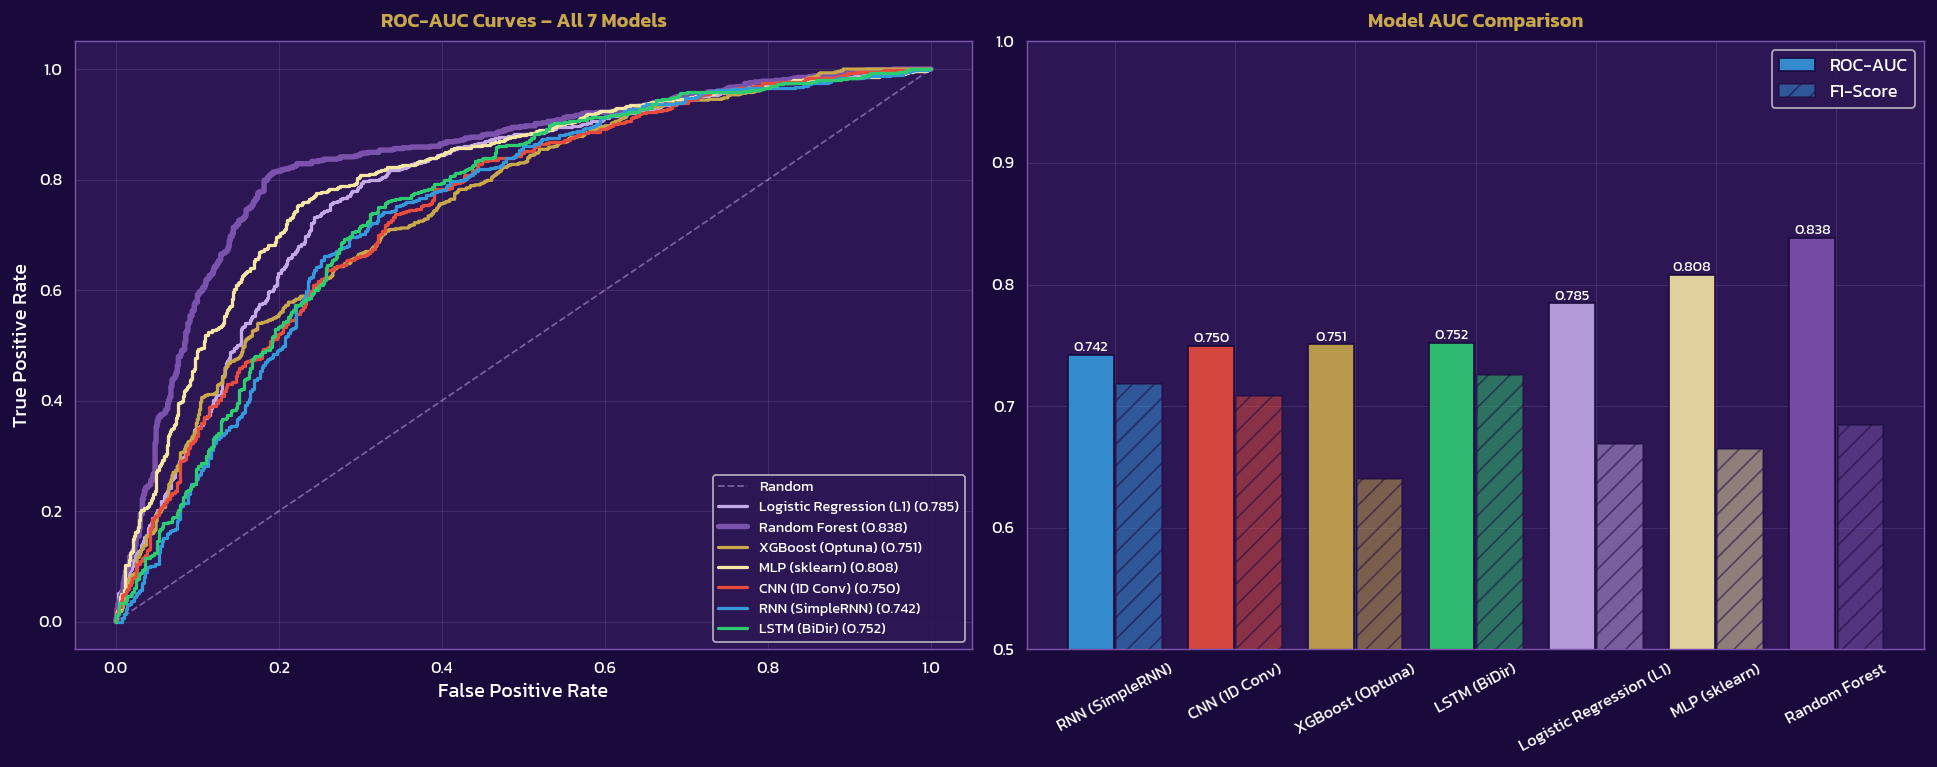

In [59]:
# ─── ROC Curves Comparison (DLT Style) ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=DLT["bg_dark"])

# ROC
ax = axes[0]; ax_style(ax, "ROC-AUC Curves – All 7 Models")
ax.plot([0,1],[0,1],"--", color=DLT["purple_light"], alpha=0.5, linewidth=1, label="Random")
for name, r in results.items():
    # ใช้ test set ที่ตรงกัน
    dl_names = ["CNN (1D Conv)","RNN (SimpleRNN)","LSTM (BiDir)"]
    y_true = y_te_seq_q if name in dl_names else y_test_q
    fpr, tpr, _ = roc_curve(y_true, r["proba"])
    lw = 3 if name == champion_name else 1.8
    ax.plot(fpr, tpr, color=r["color"], linewidth=lw,
            label=f"{name} ({r['AUC']:.3f})")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(fontsize=8, facecolor=DLT["bg_card"], labelcolor=DLT["white"])

# AUC Bar
ax = axes[1]; ax_style(ax, "Model AUC Comparison", xticks_rot=28)
names_sorted = sorted(results.keys(), key=lambda n: results[n]["AUC"])
auc_vals  = [results[n]["AUC"]  for n in names_sorted]
f1_vals   = [results[n]["F1"]   for n in names_sorted]
colors_b  = [results[n]["color"] for n in names_sorted]
x_pos = np.arange(len(names_sorted))
bars1 = ax.bar(x_pos - 0.2, auc_vals, width=0.38, color=colors_b, alpha=0.9,
               label="ROC-AUC", edgecolor=DLT["bg_dark"])
bars2 = ax.bar(x_pos + 0.2, f1_vals,  width=0.38, color=colors_b, alpha=0.5,
               label="F1-Score", edgecolor=DLT["bg_dark"], hatch="//")
ax.set_xticks(x_pos)
ax.set_xticklabels(names_sorted, fontsize=9)
ax.set_ylim(0.5, 1.0)
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])
for bar, val in zip(bars1, auc_vals):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.003,
            f"{val:.3f}", ha="center", fontsize=8, color=DLT["white"])

plt.tight_layout()
plt.savefig("model_comparison.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()


---
## 📊 9.5 Correlation Analysis – ค้นหาความสัมพันธ์เชิงนโยบาย

> **คำถามหลัก:**
> 1. รถยนต์อายุเกินกี่ปี ถึงจะมีความเสี่ยงขาดต่อภาษีเพิ่มขึ้นอย่างมีนัยสำคัญ?
> 2. กลุ่มผู้ครอบครองรถยี่ห้อใด/ประเภทใด ที่มีอัตราการจ่ายภาษีตรงเวลาสูงที่สุด?


✅ Vehicle Age Threshold (Chi-Square): 3 ปี | chi2=30015.54 | p=0.000000


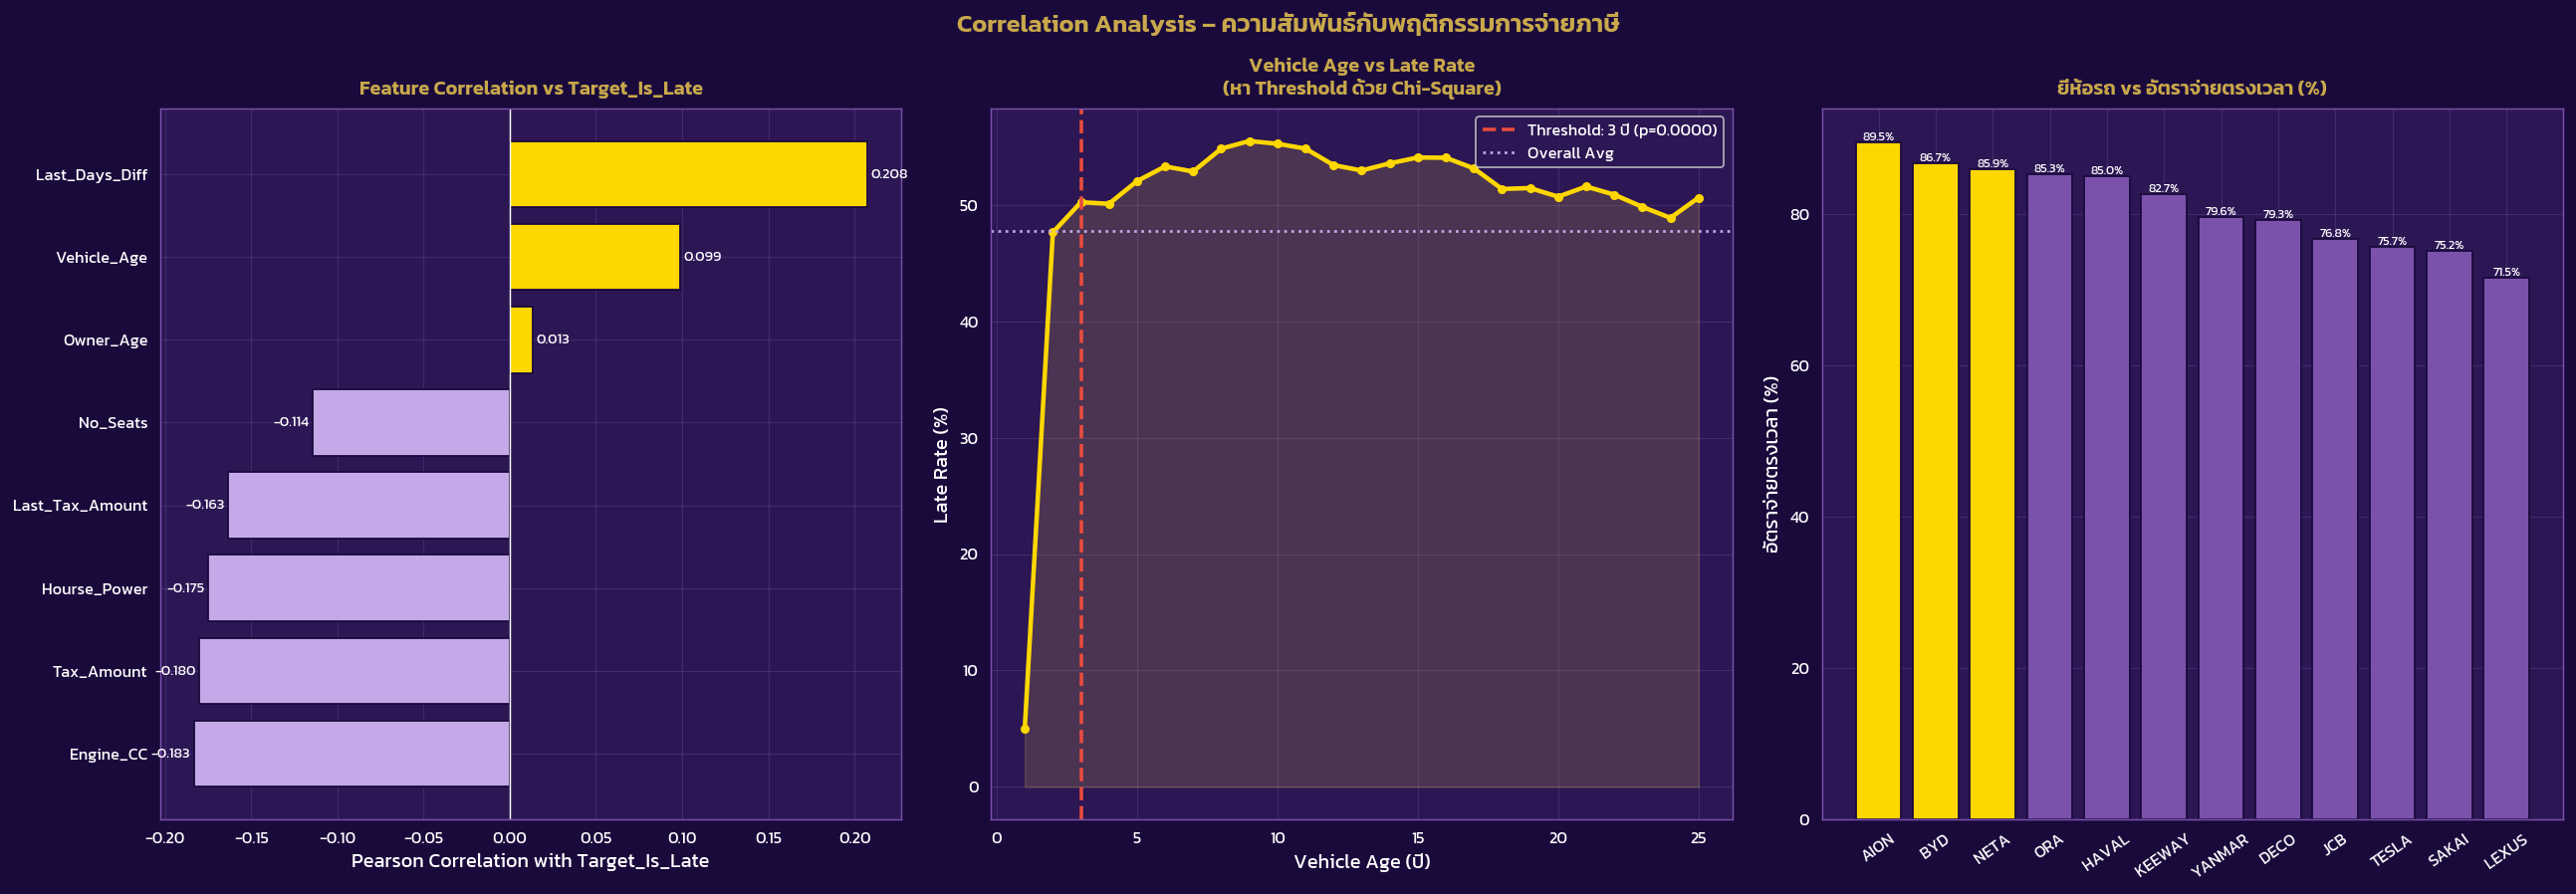


✅ Key Findings:
   รถอายุเกิน 3 ปี มีความเสี่ยงสูงขึ้นอย่างมีนัยสำคัญทางสถิติ (p<0.05)
   ยี่ห้อจ่ายตรงเวลาสูงสุด: AION (89.5%)


In [60]:
# ─── Correlation Analysis ────────────────────────────────────────────────────
from scipy import stats

num_cols_corr = [f for f in NUM_FEATS if f in df.columns and
                 df[f].nunique() > 5 and f not in [TARGET_BIN, TARGET_MULTI, TARGET_REG]]

fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor=DLT["bg_dark"])
fig.suptitle("Correlation Analysis – ความสัมพันธ์กับพฤติกรรมการจ่ายภาษี",
             color=DLT["gold_main"], fontsize=14, fontweight="bold")

# ── Plot 1: Correlation Heatmap ───────────────────────────────────────────────
ax = axes[0]; ax_style(ax, "Feature Correlation vs Target_Is_Late")
corr_df = df[num_cols_corr + [TARGET_BIN]].dropna().corr()[[TARGET_BIN]].drop(TARGET_BIN)
corr_df = corr_df.sort_values(TARGET_BIN, ascending=True)
colors_corr = [DLT["gold_bright"] if v > 0 else DLT["purple_light"]
               for v in corr_df[TARGET_BIN]]
ax.barh(corr_df.index, corr_df[TARGET_BIN], color=colors_corr, edgecolor=DLT["bg_dark"])
ax.axvline(0, color=DLT["white"], linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Target_Is_Late")
for i, (idx, val) in enumerate(corr_df.iterrows()):
    v = float(val[TARGET_BIN])   # scalar
    ax.text(v + (0.002 if v >= 0 else -0.002), i,
            f"{v:.3f}", va="center",
            ha="left" if v >= 0 else "right",
            color=DLT["white"], fontsize=8)

# ── Plot 2: Vehicle Age Threshold ─────────────────────────────────────────────
ax = axes[1]; ax_style(ax, "Vehicle Age vs Late Rate\n(หา Threshold ด้วย Chi-Square)")
age_range   = range(1, 26)
late_by_age = df[df['Vehicle_Age'].between(1,25)].groupby('Vehicle_Age')['Target_Is_Late'].agg(['mean','count'])
late_by_age['late_pct'] = late_by_age['mean'] * 100

ax.fill_between(late_by_age.index, late_by_age['late_pct'],
                alpha=0.2, color=DLT["gold_main"])
ax.plot(late_by_age.index, late_by_age['late_pct'],
        color=DLT["gold_bright"], linewidth=2.5, marker="o", markersize=4)

# หา Optimal Threshold ด้วย Chi-Square
best_age, best_chi2, best_p = 0, 0, 1
for threshold in range(3, 23):
    df_t = df[df['Vehicle_Age'].between(1, 25)].copy()
    group = (df_t['Vehicle_Age'] > threshold).astype(int)
    ct = pd.crosstab(group, df_t['Target_Is_Late'])
    if ct.shape == (2, 2):
        chi2, p, _, _ = stats.chi2_contingency(ct)
        if chi2 > best_chi2:
            best_chi2, best_p, best_age = chi2, p, threshold

ax.axvline(best_age, color="#E74C3C", linestyle="--", linewidth=2,
           label=f"Threshold: {best_age} ปี (p={best_p:.4f})")
ax.axhline(df['Target_Is_Late'].mean()*100, color=DLT["purple_light"],
           linestyle=":", linewidth=1.5, label="Overall Avg")
ax.set_xlabel("Vehicle Age (ปี)")
ax.set_ylabel("Late Rate (%)")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"], fontsize=9)
print(f"✅ Vehicle Age Threshold (Chi-Square): {best_age} ปี | chi2={best_chi2:.2f} | p={best_p:.6f}")

# ── Plot 3: Brand On-time Rate ───────────────────────────────────────────────
ax = axes[2]; ax_style(ax, "ยี่ห้อรถ vs อัตราจ่ายตรงเวลา (%)", xticks_rot=35)
if 'Brand' in df.columns:
    brand_stats = (df.groupby('Brand')['Target_Is_Late']
                   .agg(['mean','count'])
                   .query("count >= 50")
                   .sort_values('mean', ascending=True)
                   .head(12)
                   .reset_index())
    brand_stats['ontime_pct'] = (1 - brand_stats['mean']) * 100
    bar_colors_br = [DLT["gold_bright"] if i < 3 else DLT["purple_mid"]
                     for i in range(len(brand_stats))]
    ax.bar(brand_stats['Brand'], brand_stats['ontime_pct'],
           color=bar_colors_br, edgecolor=DLT["bg_dark"])
    ax.set_ylabel("อัตราจ่ายตรงเวลา (%)")
    for i, row in brand_stats.iterrows():
        ax.text(i, row['ontime_pct']+0.3, f"{row['ontime_pct']:.1f}%",
                ha='center', fontsize=7, color=DLT["white"])

plt.tight_layout()
plt.savefig("correlation_analysis.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()
print(f"\n✅ Key Findings:")
print(f"   รถอายุเกิน {best_age} ปี มีความเสี่ยงสูงขึ้นอย่างมีนัยสำคัญทางสถิติ (p<0.05)")
if 'Brand' in df.columns:
    top_brand = brand_stats.iloc[0]['Brand']
    top_rate  = brand_stats.iloc[0]['ontime_pct']
    print(f"   ยี่ห้อจ่ายตรงเวลาสูงสุด: {top_brand} ({top_rate:.1f}%)")


---
## 🤖 10. Multi-class Classification – จำแนก 4 กลุ่มพฤติกรรม

> ทำนาย `Seg_Code` (1=ตรงเวลา, 2=ช้า≤1ปี, 3=ช้า1-3ปี, 4=เกิน3ปี)  
> ใช้ **Macro F1** เป็น metric หลักเพราะ class imbalanced


Classes in train : [np.int64(1), np.int64(2), np.int64(3)]
Classes in test  : [np.int64(1), np.int64(2), np.int64(3)]
Labels for report: ['1.ตรงเวลา/ล่วงหน้า', '2.ช้า≤1ปี', '3.ช้า1-3ปี']
LogReg Multiclass | Macro-F1=0.4407
RF    Multiclass  | Macro-F1=0.4314
XGBoost Multiclass| Macro-F1=0.5133

=== Multiclass Report (XGBoost (Multi)) ===
                    precision    recall  f1-score   support

1.ตรงเวลา/ล่วงหน้า       0.78      0.79      0.79    114369
         2.ช้า≤1ปี       0.73      0.77      0.75    106650
        3.ช้า1-3ปี       0.14      0.00      0.00      6976

          accuracy                           0.76    227995
         macro avg       0.55      0.52      0.51    227995
      weighted avg       0.74      0.76      0.75    227995



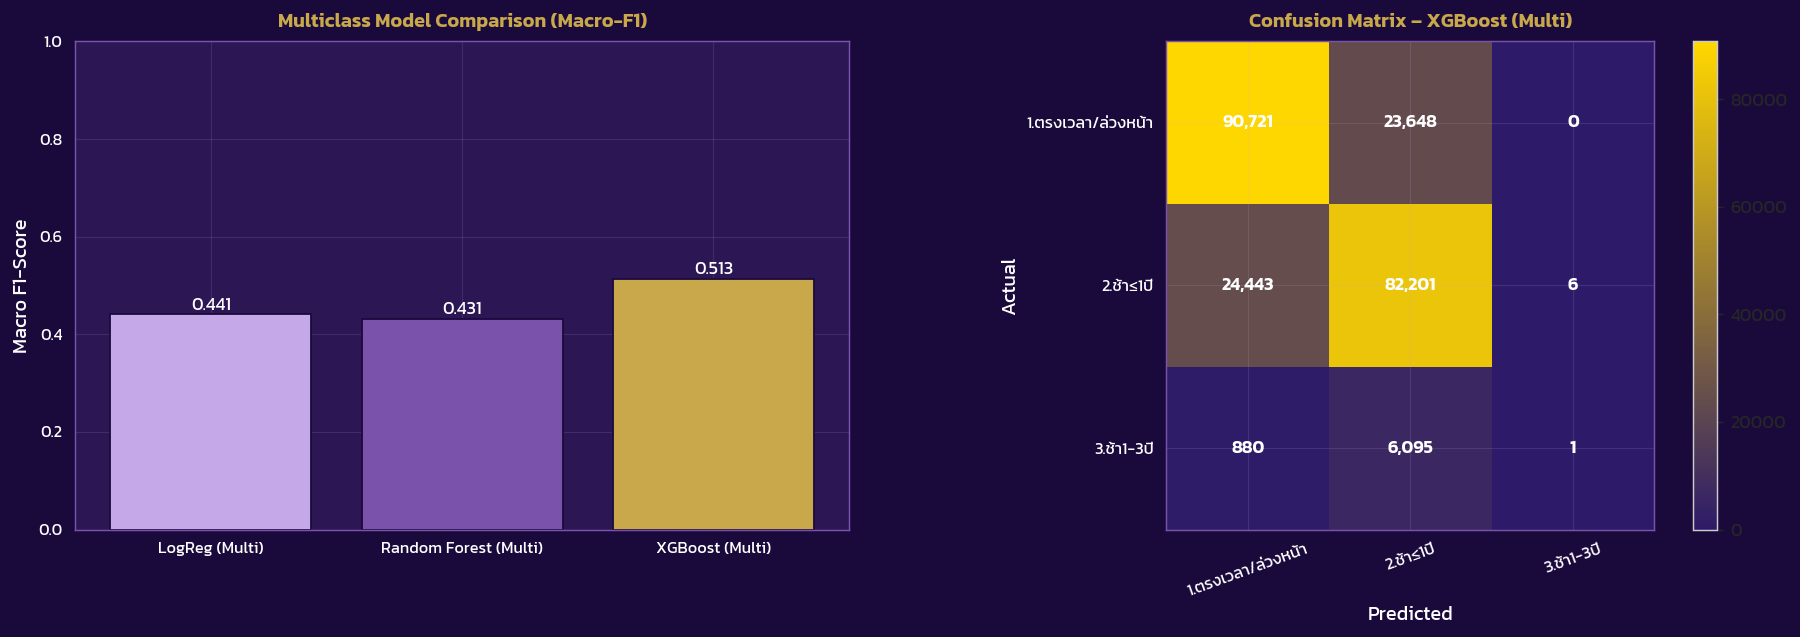


✅ Champion: XGBoost (Multi) (Macro-F1=0.5133)


In [61]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
import xgboost as xgb
import matplotlib.colors as mcolors

results_multi = {}

# ── Preprocessing ─────────────────────────────────────────────────────────────
feats_no_seg = ALL_FEATS   # ALL_FEATS already clean
X_tr_m = prep.transform(df_train[feats_no_seg])
X_te_m = prep.transform(df_test[feats_no_seg])

# ── Dynamic class labels (รองรับกรณีที่บาง class ไม่มีใน test set) ────────────
seg_label_map = {
    1: '1.ตรงเวลา/ล่วงหน้า',
    2: '2.ช้า≤1ปี',
    3: '3.ช้า1-3ปี',
    4: '4.เกิน3ปี',
}
classes_in_train = sorted(y_train_multi.unique())
classes_in_test  = sorted(y_test_multi.unique())
all_classes      = sorted(set(classes_in_train) | set(classes_in_test))
class_labels     = [seg_label_map.get(c, str(c)) for c in all_classes]
n_classes_multi  = len(classes_in_train)

print(f"Classes in train : {classes_in_train}")
print(f"Classes in test  : {classes_in_test}")
print(f"Labels for report: {class_labels}")

# ── 10.1 Logistic Regression Multiclass ──────────────────────────────────────
lr_multi = LogisticRegression(C=0.1, solver='saga', multi_class='multinomial',
                               max_iter=1000, class_weight='balanced',
                               random_state=RANDOM_STATE)
lr_multi.fit(X_tr_m, y_train_multi)
yp_lr_m  = lr_multi.predict(X_te_m)
f1_lr_m  = f1_score(y_test_multi, yp_lr_m, average='macro', zero_division=0)
results_multi['LogReg (Multi)'] = dict(pred=yp_lr_m, f1_macro=f1_lr_m,
                                        color=DLT["purple_light"])
print(f"LogReg Multiclass | Macro-F1={f1_lr_m:.4f}")

# ── 10.2 Random Forest Multiclass ────────────────────────────────────────────
rf_n_multi = 100 if QUICK_MODE else 300
rf_multi = RandomForestClassifier(n_estimators=rf_n_multi, max_depth=10,
                                   min_samples_leaf=15, class_weight='balanced',
                                   n_jobs=-1, random_state=RANDOM_STATE)
rf_multi.fit(X_tr_m, y_train_multi)
yp_rf_m  = rf_multi.predict(X_te_m)
f1_rf_m  = f1_score(y_test_multi, yp_rf_m, average='macro', zero_division=0)
results_multi['Random Forest (Multi)'] = dict(pred=yp_rf_m, f1_macro=f1_rf_m,
                                               color=DLT["purple_mid"])
print(f"RF    Multiclass  | Macro-F1={f1_rf_m:.4f}")

# ── 10.3 XGBoost Multiclass ───────────────────────────────────────────────────
# Re-index classes to 0-based (XGBoost requirement)
class_to_idx = {c: i for i, c in enumerate(classes_in_train)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y_tr_m_idx = y_train_multi.map(class_to_idx)
y_te_m_idx = y_test_multi.map(class_to_idx).fillna(-1).astype(int)

xgb_multi = xgb.XGBClassifier(
    n_estimators=200 if QUICK_MODE else 400,
    max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=n_classes_multi,
    eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE
)
xgb_multi.fit(X_tr_m, y_tr_m_idx,
              eval_set=[(X_te_m, y_te_m_idx)], verbose=False)

yp_xgb_m_idx = xgb_multi.predict(X_te_m)
yp_xgb_m_raw = pd.Series(yp_xgb_m_idx).map(idx_to_class).values  # shift back to 1-4

f1_xgb_m = f1_score(y_test_multi, yp_xgb_m_raw, average='macro', zero_division=0)
results_multi['XGBoost (Multi)'] = dict(pred=yp_xgb_m_raw, f1_macro=f1_xgb_m,
                                         color=DLT["gold_main"])
print(f"XGBoost Multiclass| Macro-F1={f1_xgb_m:.4f}")

# ── Summary ───────────────────────────────────────────────────────────────────
best_multi_name = max(results_multi, key=lambda n: results_multi[n]['f1_macro'])
best_multi_pred = results_multi[best_multi_name]['pred']

# Classification report: ใช้เฉพาะ classes ที่มีใน test set
test_classes       = sorted(set(y_test_multi.unique()) & set(all_classes))
test_class_labels  = [seg_label_map.get(c, str(c)) for c in test_classes]

print(f"\n=== Multiclass Report ({best_multi_name}) ===")
print(classification_report(y_test_multi, best_multi_pred,
      labels=test_classes, target_names=test_class_labels,
      zero_division=0))

# ── Visualize ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DLT["bg_dark"])

# Macro-F1 Bar
ax = axes[0]; ax_style(ax, "Multiclass Model Comparison (Macro-F1)")
names_m = list(results_multi.keys())
f1s_m   = [results_multi[n]['f1_macro'] for n in names_m]
cols_m  = [results_multi[n]['color']    for n in names_m]
ax.bar(names_m, f1s_m, color=cols_m, edgecolor=DLT["bg_dark"])
ax.set_ylabel("Macro F1-Score")
ax.set_ylim(0, 1)
for i, (n, v) in enumerate(zip(names_m, f1s_m)):
    ax.text(i, v + 0.01, f"{v:.3f}", ha='center', color=DLT["white"], fontsize=10)

# Confusion Matrix (เฉพาะ classes ที่มีจริง)
ax = axes[1]; ax_style(ax, f"Confusion Matrix – {best_multi_name}")
cm = confusion_matrix(y_test_multi, best_multi_pred, labels=test_classes)
cmap_dlt = mcolors.LinearSegmentedColormap.from_list(
    "dlt", [DLT["purple_deep"], DLT["gold_bright"]])
im = ax.imshow(cm, cmap=cmap_dlt)
ax.set_xticks(range(len(test_classes)))
ax.set_xticklabels(test_class_labels, color=DLT["white"], rotation=20, fontsize=9)
ax.set_yticks(range(len(test_classes)))
ax.set_yticklabels(test_class_labels, color=DLT["white"], fontsize=9)
ax.set_xlabel("Predicted", color=DLT["white"])
ax.set_ylabel("Actual",    color=DLT["white"])
for i in range(len(test_classes)):
    for j in range(len(test_classes)):
        ax.text(j, i, f"{cm[i,j]:,}", ha='center', va='center',
                color=DLT["white"], fontsize=10, fontweight="bold")
plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("multiclass_results.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()
print(f"\n✅ Champion: {best_multi_name} (Macro-F1={results_multi[best_multi_name]['f1_macro']:.4f})")

Train class distribution (ก่อน SMOTE):
  Class 1 (1.ตรงเวลา/ล่วงหน้า): 392,276 ราย (52.9%)
  Class 2 (2.ช้า≤1ปี): 316,560 ราย (42.7%)
  Class 3 (3.ช้า1-3ปี): 33,385 ราย (4.5%)

Class 3 current : 33,385
Class 3 target  : 66,770 (SMOTE จะเพิ่มอีก 33,385 synthetic samples)


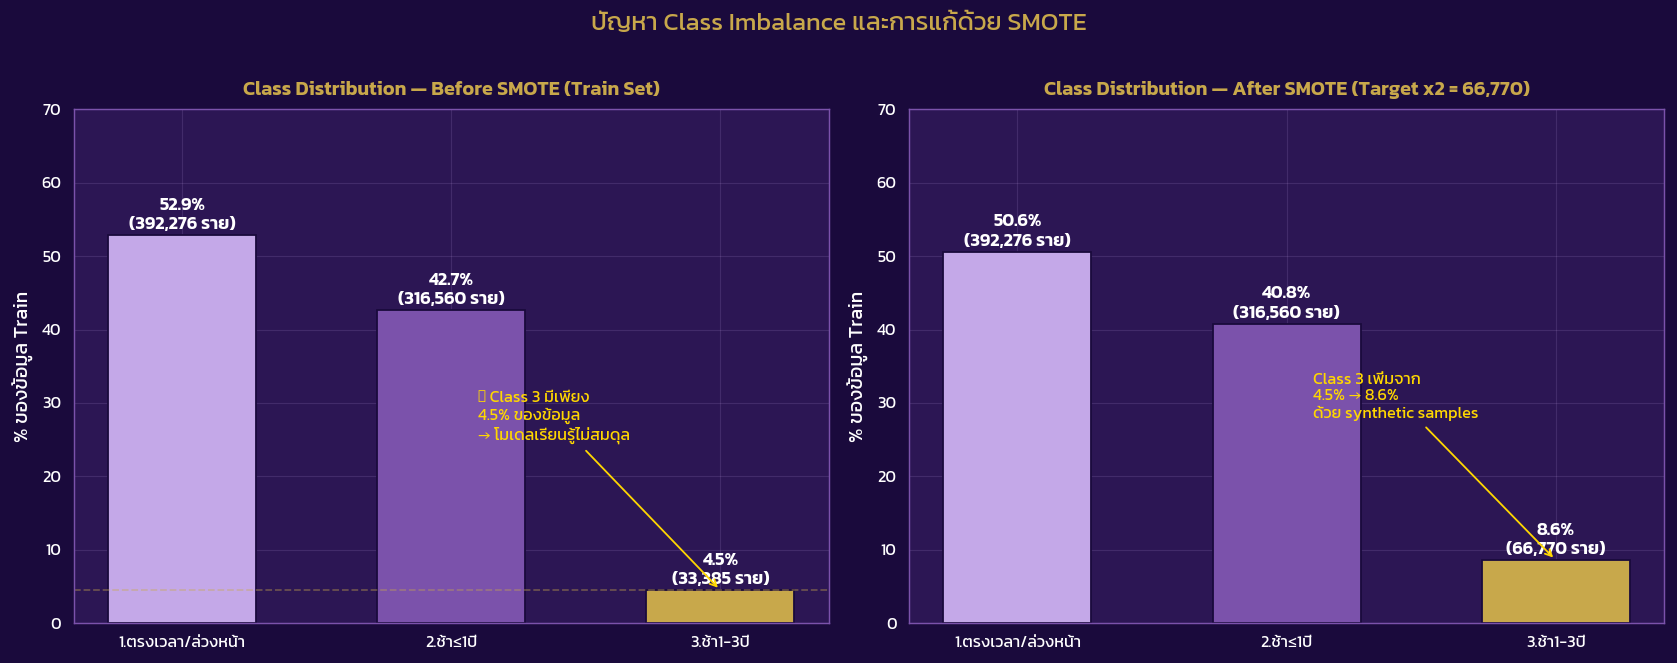


Before SMOTE — Class 3: 33,385 ราย (4.5%)
After  SMOTE — Class 3: 66,770 ราย (8.6%)
วิธีที่ 1: SMOTE
สร้าง synthetic samples class 3: 33,385 → 66,770
After SMOTE distribution:
  Class 1: 392,276 ราย (50.6%)
  Class 2: 316,560 ราย (40.8%)
  Class 3: 66,770 ราย (8.6%)
✅ SMOTE XGBoost | Macro-F1 = 0.5149

วิธีที่ 2: Class Weight (sample_weight)
class 3 weight = 11.8x ของ class 1-2
✅ Class Weight XGBoost | Macro-F1 = 0.4381

วิธีที่ 3: SMOTE + Threshold Tuning
ลด threshold ของ class 3 จาก 0.33 → 0.15 เพื่อเพิ่ม recall
✅ SMOTE + Threshold (0.15) | Macro-F1 = 0.5305


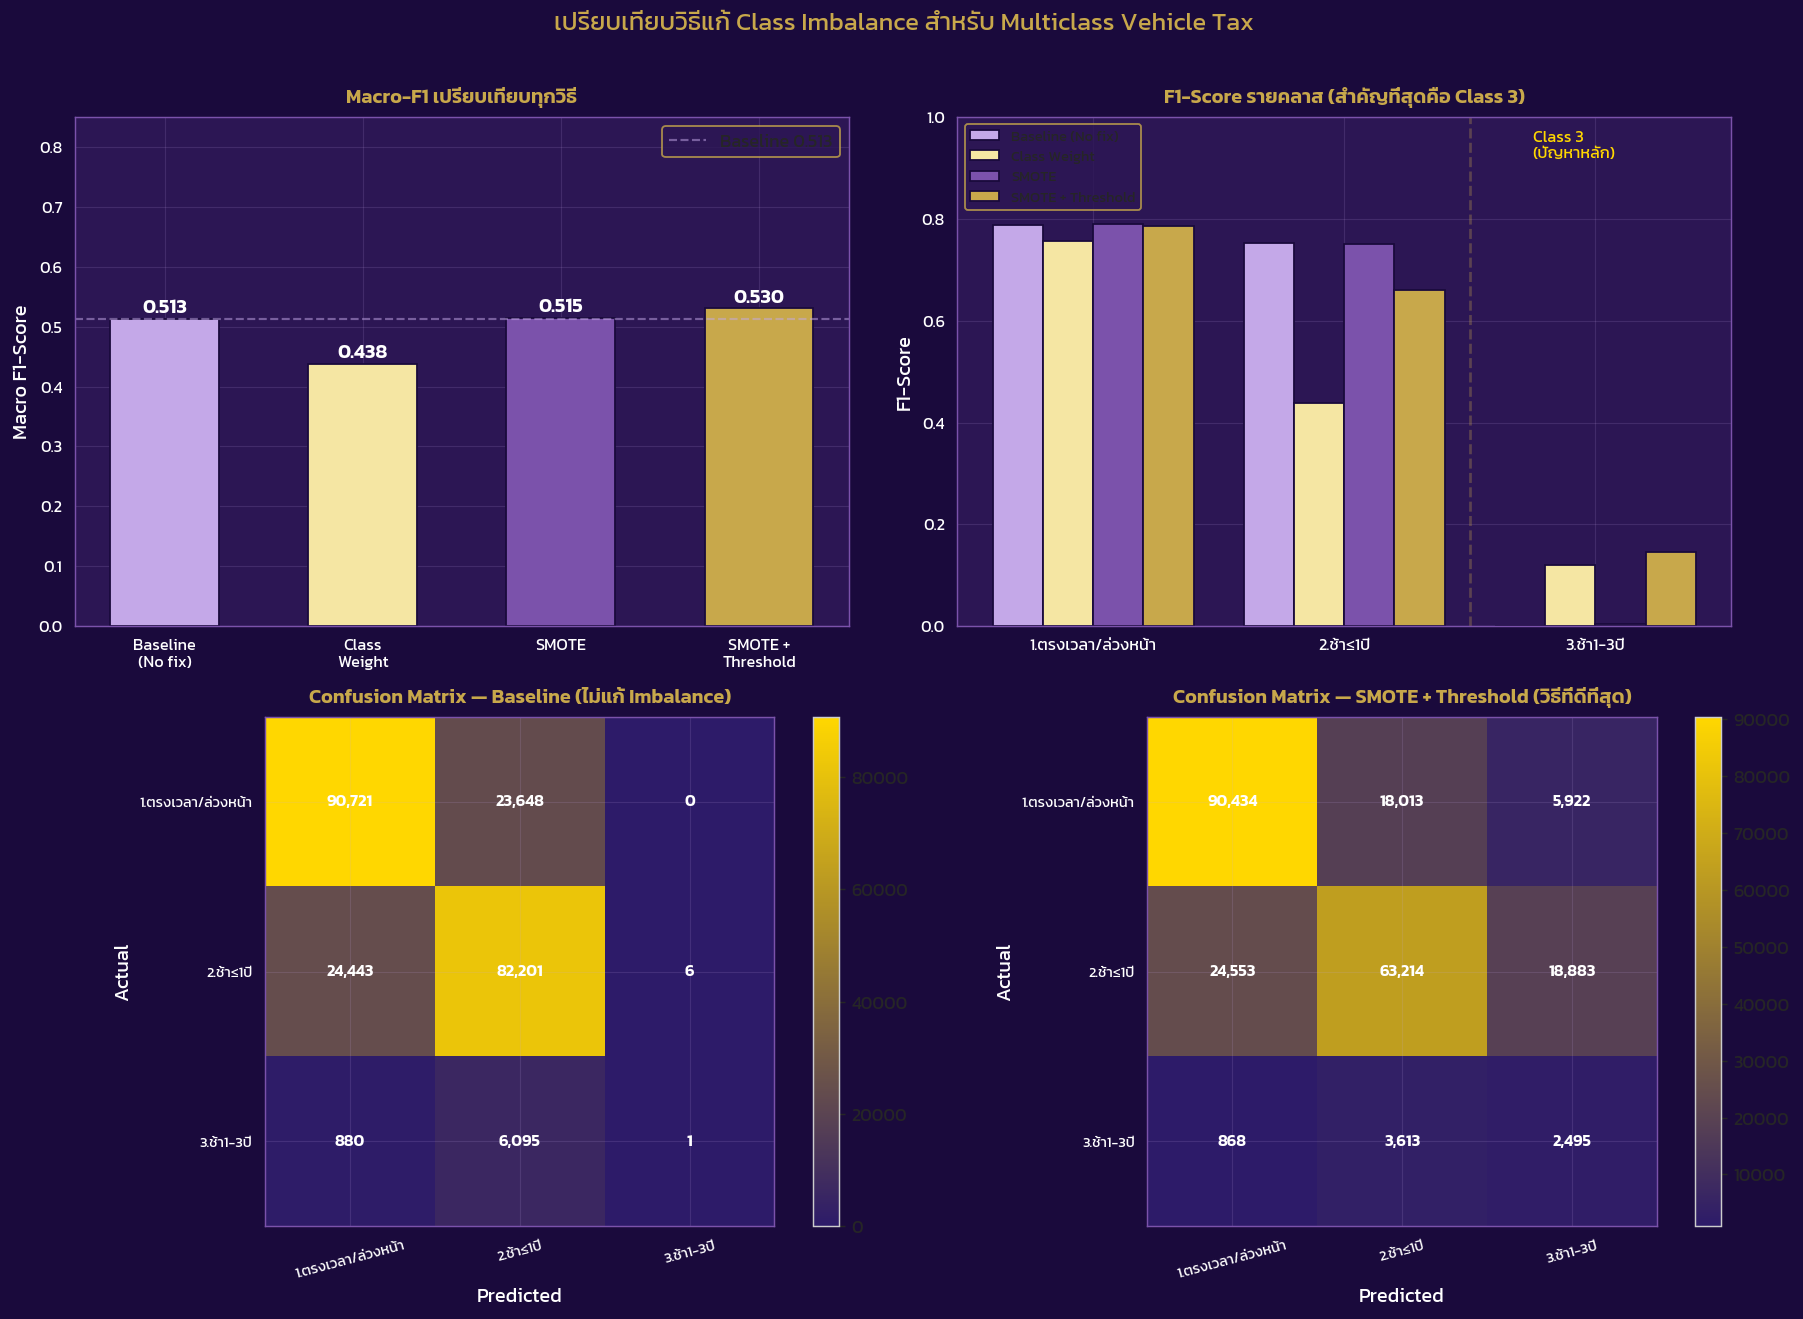


📋 CLASSIFICATION REPORT เปรียบเทียบทุกวิธี
                   F1_1.ตรงเวลา/ล่วงหน้า  F1_2.ช้า≤1ปี  F1_3.ช้า1-3ปี  Macro_F1  Weighted_F1  Accuracy
Method                                                                                                
Baseline (No fix)                  0.787         0.752          0.000     0.513        0.747     0.758
Class Weight                       0.756         0.439          0.120     0.438        0.588     0.533
SMOTE                              0.789         0.751          0.005     0.515        0.747     0.758
SMOTE + Threshold                  0.786         0.660          0.146     0.530        0.707     0.685

🏆 วิธีที่ดีที่สุด : SMOTE + Threshold
   Baseline Macro-F1 : 0.5133
   Best Fix Macro-F1 : 0.5305
   ปรับปรุงขึ้น      : +0.0172 (3.4%)


In [62]:
# ═══════════════════════════════════════════════════════════════════════════════
# 📊 SECTION A: Class Distribution Plot — ทำไมต้องทำ SMOTE
# ═══════════════════════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "imbalanced-learn", "-q"])

from collections import Counter

seg_label_map = {1: '1.ตรงเวลา/ล่วงหน้า', 2: '2.ช้า≤1ปี', 3: '3.ช้า1-3ปี'}

# นับ class distribution จาก TRAIN จริง
train_counts = Counter(y_train_multi)
train_total  = sum(train_counts.values())
classes_plot = sorted(train_counts.keys())
labels_plot  = [seg_label_map[c] for c in classes_plot]
pcts_before  = [train_counts[c] / train_total * 100 for c in classes_plot]
counts_before = [train_counts[c] for c in classes_plot]

# คำนวณ SMOTE target แบบ dynamic (ต้องมากกว่าที่มีอยู่ใน train เสมอ)
c3_current = train_counts[3]
c3_target  = max(c3_current + 1, int(c3_current * 2))  # ขยาย 2x

print("Train class distribution (ก่อน SMOTE):")
for c, n in sorted(train_counts.items()):
    print(f"  Class {c} ({seg_label_map[c]}): {n:,} ราย ({n/train_total*100:.1f}%)")
print(f"\nClass 3 current : {c3_current:,}")
print(f"Class 3 target  : {c3_target:,} (SMOTE จะเพิ่มอีก {c3_target - c3_current:,} synthetic samples)")

# คำนวณ after SMOTE สำหรับกราฟ
target_counts = {c: (c3_target if c == 3 else train_counts[c]) for c in classes_plot}
target_total  = sum(target_counts.values())
pcts_after    = [target_counts[c] / target_total * 100 for c in classes_plot]
counts_after  = [target_counts[c] for c in classes_plot]
c3_idx        = classes_plot.index(3)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor=DLT["bg_dark"])
bar_colors = [DLT["purple_light"], DLT["purple_mid"], DLT["gold_main"]]

# ── Left: Before SMOTE ───────────────────────────────────────────────────────
ax = axes[0]
ax_style(ax, "Class Distribution — Before SMOTE (Train Set)")
bars = ax.bar(labels_plot, pcts_before, color=bar_colors, edgecolor=DLT["bg_dark"], width=0.55)
ax.set_ylabel("% ของข้อมูล Train", color=DLT["white"])
ax.set_ylim(0, 70)
for bar, pct, cnt in zip(bars, pcts_before, counts_before):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{pct:.1f}%\n({cnt:,} ราย)",
            ha='center', color=DLT["white"], fontsize=10, fontweight='bold')
ax.annotate(
    f"⚠ Class 3 มีเพียง\n{pcts_before[c3_idx]:.1f}% ของข้อมูล\n→ โมเดลเรียนรู้ไม่สมดุล",
    xy=(c3_idx, pcts_before[c3_idx]),
    xytext=(c3_idx - 0.9, 25),
    fontsize=9, color=DLT["gold_bright"],
    arrowprops=dict(arrowstyle='->', color=DLT["gold_bright"])
)
ax.axhline(y=pcts_before[c3_idx], color=DLT["gold_main"], linestyle='--', alpha=0.4, linewidth=1)

# ── Right: After SMOTE ───────────────────────────────────────────────────────
ax = axes[1]
ax_style(ax, f"Class Distribution — After SMOTE (Target x2 = {c3_target:,})")
bars2 = ax.bar(labels_plot, pcts_after, color=bar_colors, edgecolor=DLT["bg_dark"], width=0.55)
ax.set_ylabel("% ของข้อมูล Train", color=DLT["white"])
ax.set_ylim(0, 70)
for bar, pct, cnt in zip(bars2, pcts_after, counts_after):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{pct:.1f}%\n({cnt:,} ราย)",
            ha='center', color=DLT["white"], fontsize=10, fontweight='bold')
ax.annotate(
    f"Class 3 เพิ่มจาก\n{pcts_before[c3_idx]:.1f}% → {pcts_after[c3_idx]:.1f}%\nด้วย synthetic samples",
    xy=(c3_idx, pcts_after[c3_idx]),
    xytext=(c3_idx - 0.9, 28),
    fontsize=9, color=DLT["gold_bright"],
    arrowprops=dict(arrowstyle='->', color=DLT["gold_bright"])
)

plt.suptitle("ปัญหา Class Imbalance และการแก้ด้วย SMOTE",
             color=DLT["gold_main"], fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("class_distribution.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()

print(f"\nBefore SMOTE — Class 3: {c3_current:,} ราย ({pcts_before[c3_idx]:.1f}%)")
print(f"After  SMOTE — Class 3: {c3_target:,} ราย ({pcts_after[c3_idx]:.1f}%)")


# ═══════════════════════════════════════════════════════════════════════════════
# 🔬 SECTION B: Train 3 วิธีเพื่อแก้ Imbalance — เปรียบเทียบกัน
# ═══════════════════════════════════════════════════════════════════════════════
from imblearn.over_sampling import SMOTE
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings("ignore")

results_imb = {}

# ════════════════════════════════════════════════════════
# วิธีที่ 1: SMOTE
# ════════════════════════════════════════════════════════
print("=" * 55)
print("วิธีที่ 1: SMOTE")
print(f"สร้าง synthetic samples class 3: {c3_current:,} → {c3_target:,}")
print("=" * 55)

sm = SMOTE(sampling_strategy={3: c3_target}, k_neighbors=5, random_state=RANDOM_STATE)
X_smote, y_smote = sm.fit_resample(X_tr_m, y_train_multi)

after_counts = Counter(y_smote)
after_total  = sum(after_counts.values())
print("After SMOTE distribution:")
for c, n in sorted(after_counts.items()):
    print(f"  Class {c}: {n:,} ราย ({n/after_total*100:.1f}%)")

y_smote_idx     = pd.Series(y_smote).map(class_to_idx)
n_classes_smote = len(class_to_idx)

xgb_smote = xgb.XGBClassifier(
    n_estimators=200 if QUICK_MODE else 400,
    max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=n_classes_smote,
    eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE
)
xgb_smote.fit(X_smote, y_smote_idx, verbose=False)

yp_smote_idx = xgb_smote.predict(X_te_m)
yp_smote     = pd.Series(yp_smote_idx).map(idx_to_class).values
f1_smote     = f1_score(y_test_multi, yp_smote, average='macro', zero_division=0)
results_imb['SMOTE'] = dict(pred=yp_smote, f1_macro=f1_smote, color=DLT["purple_mid"])
print(f"✅ SMOTE XGBoost | Macro-F1 = {f1_smote:.4f}")


# ════════════════════════════════════════════════════════
# วิธีที่ 2: Class Weight (sample_weight)
# ════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("วิธีที่ 2: Class Weight (sample_weight)")
w3 = train_counts[1] / train_counts[3]
print(f"class 3 weight = {w3:.1f}x ของ class 1-2")
print("=" * 55)

weight_map     = {1: 1.0, 2: 1.0, 3: w3}
sample_weights = y_train_multi.map(weight_map).values

xgb_weighted = xgb.XGBClassifier(
    n_estimators=200 if QUICK_MODE else 400,
    max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=n_classes_multi,
    eval_metric='mlogloss', n_jobs=-1, random_state=RANDOM_STATE
)
xgb_weighted.fit(X_tr_m, y_tr_m_idx, sample_weight=sample_weights, verbose=False)

yp_weighted_idx = xgb_weighted.predict(X_te_m)
yp_weighted     = pd.Series(yp_weighted_idx).map(idx_to_class).values
f1_weighted     = f1_score(y_test_multi, yp_weighted, average='macro', zero_division=0)
results_imb['Class Weight'] = dict(pred=yp_weighted, f1_macro=f1_weighted, color=DLT["gold_light"])
print(f"✅ Class Weight XGBoost | Macro-F1 = {f1_weighted:.4f}")


# ════════════════════════════════════════════════════════
# วิธีที่ 3: SMOTE + Threshold Tuning
# ════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("วิธีที่ 3: SMOTE + Threshold Tuning")
print("ลด threshold ของ class 3 จาก 0.33 → 0.15 เพื่อเพิ่ม recall")
print("=" * 55)

proba_smote    = xgb_smote.predict_proba(X_te_m)
class3_col_idx = class_to_idx[3]
THRESHOLD_C3   = 0.15

yp_thresh = []
for row in proba_smote:
    if row[class3_col_idx] >= THRESHOLD_C3:
        yp_thresh.append(idx_to_class[class3_col_idx])
    else:
        yp_thresh.append(idx_to_class[int(np.argmax(row))])
yp_thresh = np.array(yp_thresh)

f1_thresh = f1_score(y_test_multi, yp_thresh, average='macro', zero_division=0)
results_imb['SMOTE + Threshold'] = dict(pred=yp_thresh, f1_macro=f1_thresh, color=DLT["gold_main"])
print(f"✅ SMOTE + Threshold ({THRESHOLD_C3}) | Macro-F1 = {f1_thresh:.4f}")


# ═══════════════════════════════════════════════════════════════════════════════
# 📈 SECTION C: เปรียบเทียบผลทั้ง 3 วิธี vs Baseline
# ═══════════════════════════════════════════════════════════════════════════════
import matplotlib.colors as mcolors
cmap_dlt = mcolors.LinearSegmentedColormap.from_list(
    "dlt", [DLT["purple_deep"], DLT["gold_bright"]])

test_classes      = sorted(set(y_test_multi.unique()))
test_class_labels = [seg_label_map.get(c, str(c)) for c in test_classes]

all_methods = {
    'Baseline\n(No fix)':     dict(pred=yp_xgb_m_raw, f1_macro=f1_xgb_m,   color=DLT["purple_light"]),
    'Class\nWeight':          results_imb['Class Weight'],
    'SMOTE':                  results_imb['SMOTE'],
    'SMOTE +\nThreshold':     results_imb['SMOTE + Threshold'],
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10), facecolor=DLT["bg_dark"])

# ── (0,0) Macro-F1 Bar ───────────────────────────────────────────────────────
ax = axes[0, 0]
ax_style(ax, "Macro-F1 เปรียบเทียบทุกวิธี")
names_all = list(all_methods.keys())
f1s_all   = [all_methods[n]['f1_macro'] for n in names_all]
cols_all  = [all_methods[n]['color']    for n in names_all]
bars = ax.bar(names_all, f1s_all, color=cols_all, edgecolor=DLT["bg_dark"], width=0.55)
ax.set_ylabel("Macro F1-Score", color=DLT["white"])
ax.set_ylim(0, 0.85)
ax.axhline(y=f1_xgb_m, color=DLT["purple_light"], linestyle='--', alpha=0.5,
           linewidth=1.2, label=f'Baseline {f1_xgb_m:.3f}')
for bar, v in zip(bars, f1s_all):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{v:.3f}", ha='center', color=DLT["white"], fontsize=11, fontweight='bold')
ax.legend(facecolor=DLT["bg_card"], edgecolor=DLT["gold_main"])

# ── (0,1) Per-class F1 Grouped Bar ──────────────────────────────────────────
ax = axes[0, 1]
ax_style(ax, "F1-Score รายคลาส (สำคัญที่สุดคือ Class 3)")
x_pos   = np.arange(len(test_classes))
width   = 0.2
palette = [DLT["purple_light"], DLT["gold_light"], DLT["purple_mid"], DLT["gold_main"]]
for i, (mname, mdata) in enumerate(all_methods.items()):
    report = classification_report(y_test_multi, mdata['pred'],
                                   labels=test_classes, target_names=test_class_labels,
                                   output_dict=True, zero_division=0)
    f1_per = [report[lbl]['f1-score'] for lbl in test_class_labels]
    ax.bar(x_pos + i * width, f1_per, width,
           label=mname.replace('\n', ' '), color=palette[i], edgecolor=DLT["bg_dark"])
ax.set_xticks(x_pos + width * 1.5)
ax.set_xticklabels(test_class_labels, color=DLT["white"], fontsize=9)
ax.set_ylabel("F1-Score", color=DLT["white"])
ax.set_ylim(0, 1.0)
ax.legend(facecolor=DLT["bg_card"], edgecolor=DLT["gold_main"], fontsize=8)
ax.axvline(x=1.8, color=DLT["gold_main"], linestyle='--', alpha=0.3)
ax.text(2.05, 0.92, "Class 3\n(ปัญหาหลัก)", color=DLT["gold_bright"], fontsize=9)

# ── (1,0) Confusion Matrix: Baseline ────────────────────────────────────────
ax = axes[1, 0]
ax_style(ax, "Confusion Matrix — Baseline (ไม่แก้ Imbalance)")
cm_base = confusion_matrix(y_test_multi, yp_xgb_m_raw, labels=test_classes)
im = ax.imshow(cm_base, cmap=cmap_dlt)
ax.set_xticks(range(len(test_classes)))
ax.set_xticklabels(test_class_labels, color=DLT["white"], rotation=15, fontsize=8)
ax.set_yticks(range(len(test_classes)))
ax.set_yticklabels(test_class_labels, color=DLT["white"], fontsize=8)
ax.set_xlabel("Predicted", color=DLT["white"])
ax.set_ylabel("Actual", color=DLT["white"])
for i in range(len(test_classes)):
    for j in range(len(test_classes)):
        ax.text(j, i, f"{cm_base[i,j]:,}", ha='center', va='center',
                color=DLT["white"], fontsize=9, fontweight='bold')
plt.colorbar(im, ax=ax, fraction=0.046)

# ── (1,1) Confusion Matrix: Best Method ─────────────────────────────────────
best_fix_name = max(results_imb, key=lambda n: results_imb[n]['f1_macro'])
best_fix_pred = results_imb[best_fix_name]['pred']
ax = axes[1, 1]
ax_style(ax, f"Confusion Matrix — {best_fix_name} (วิธีที่ดีที่สุด)")
cm_best = confusion_matrix(y_test_multi, best_fix_pred, labels=test_classes)
im2 = ax.imshow(cm_best, cmap=cmap_dlt)
ax.set_xticks(range(len(test_classes)))
ax.set_xticklabels(test_class_labels, color=DLT["white"], rotation=15, fontsize=8)
ax.set_yticks(range(len(test_classes)))
ax.set_yticklabels(test_class_labels, color=DLT["white"], fontsize=8)
ax.set_xlabel("Predicted", color=DLT["white"])
ax.set_ylabel("Actual", color=DLT["white"])
for i in range(len(test_classes)):
    for j in range(len(test_classes)):
        ax.text(j, i, f"{cm_best[i,j]:,}", ha='center', va='center',
                color=DLT["white"], fontsize=9, fontweight='bold')
plt.colorbar(im2, ax=ax, fraction=0.046)

plt.suptitle("เปรียบเทียบวิธีแก้ Class Imbalance สำหรับ Multiclass Vehicle Tax",
             color=DLT["gold_main"], fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("imbalance_comparison.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()


# ═══════════════════════════════════════════════════════════════════════════════
# 📋 SECTION D: Classification Report เปรียบเทียบทุกวิธี
# ═══════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 62)
print("📋 CLASSIFICATION REPORT เปรียบเทียบทุกวิธี")
print("=" * 62)

report_rows = []
for mname, mdata in all_methods.items():
    r = classification_report(y_test_multi, mdata['pred'],
                              labels=test_classes, target_names=test_class_labels,
                              output_dict=True, zero_division=0)
    clean_name = mname.replace('\n', ' ')
    row = {'Method': clean_name}
    for lbl in test_class_labels:
        row[f'F1_{lbl}'] = round(r[lbl]['f1-score'], 3)
    row['Macro_F1']    = round(r['macro avg']['f1-score'], 3)
    row['Weighted_F1'] = round(r['weighted avg']['f1-score'], 3)
    row['Accuracy']    = round(r['accuracy'], 3)
    report_rows.append(row)

df_report = pd.DataFrame(report_rows).set_index('Method')
print(df_report.to_string())

best_fix = max(results_imb, key=lambda n: results_imb[n]['f1_macro'])
delta    = results_imb[best_fix]['f1_macro'] - f1_xgb_m
print(f"\n🏆 วิธีที่ดีที่สุด : {best_fix}")
print(f"   Baseline Macro-F1 : {f1_xgb_m:.4f}")
print(f"   Best Fix Macro-F1 : {results_imb[best_fix]['f1_macro']:.4f}")
print(f"   ปรับปรุงขึ้น      : +{delta:.4f} ({delta/f1_xgb_m*100:.1f}%)")

---
## 📈 11. Regression – พยากรณ์จำนวนวันที่จ่ายล่าช้า

> ใช้ข้อมูลเฉพาะ **กลุ่มที่ล่าช้า (Days_Late_Actual > 0)** เพื่อทำนายว่าจะล่าช้ากี่วัน  
> Metric หลัก: **MAE** (Mean Absolute Error in days) · **RMSE** · **R²**


Regression dataset: Train=349,945 | Test=113,626 late records
Days_Late range (train): 1 – 1095 วัน
Days_Late mean (train):  117.0 วัน

Ridge Regression (Baseline)    | MAE= 100.0d | RMSE=  137.3d | MAPE=1164.6% | R²=0.0405
Random Forest Regressor        | MAE=  92.3d | RMSE=  129.4d | MAPE= 978.4% | R²=0.1474
XGBoost Regressor              | MAE=  94.1d | RMSE=  130.3d | MAPE=1019.6% | R²=0.1363


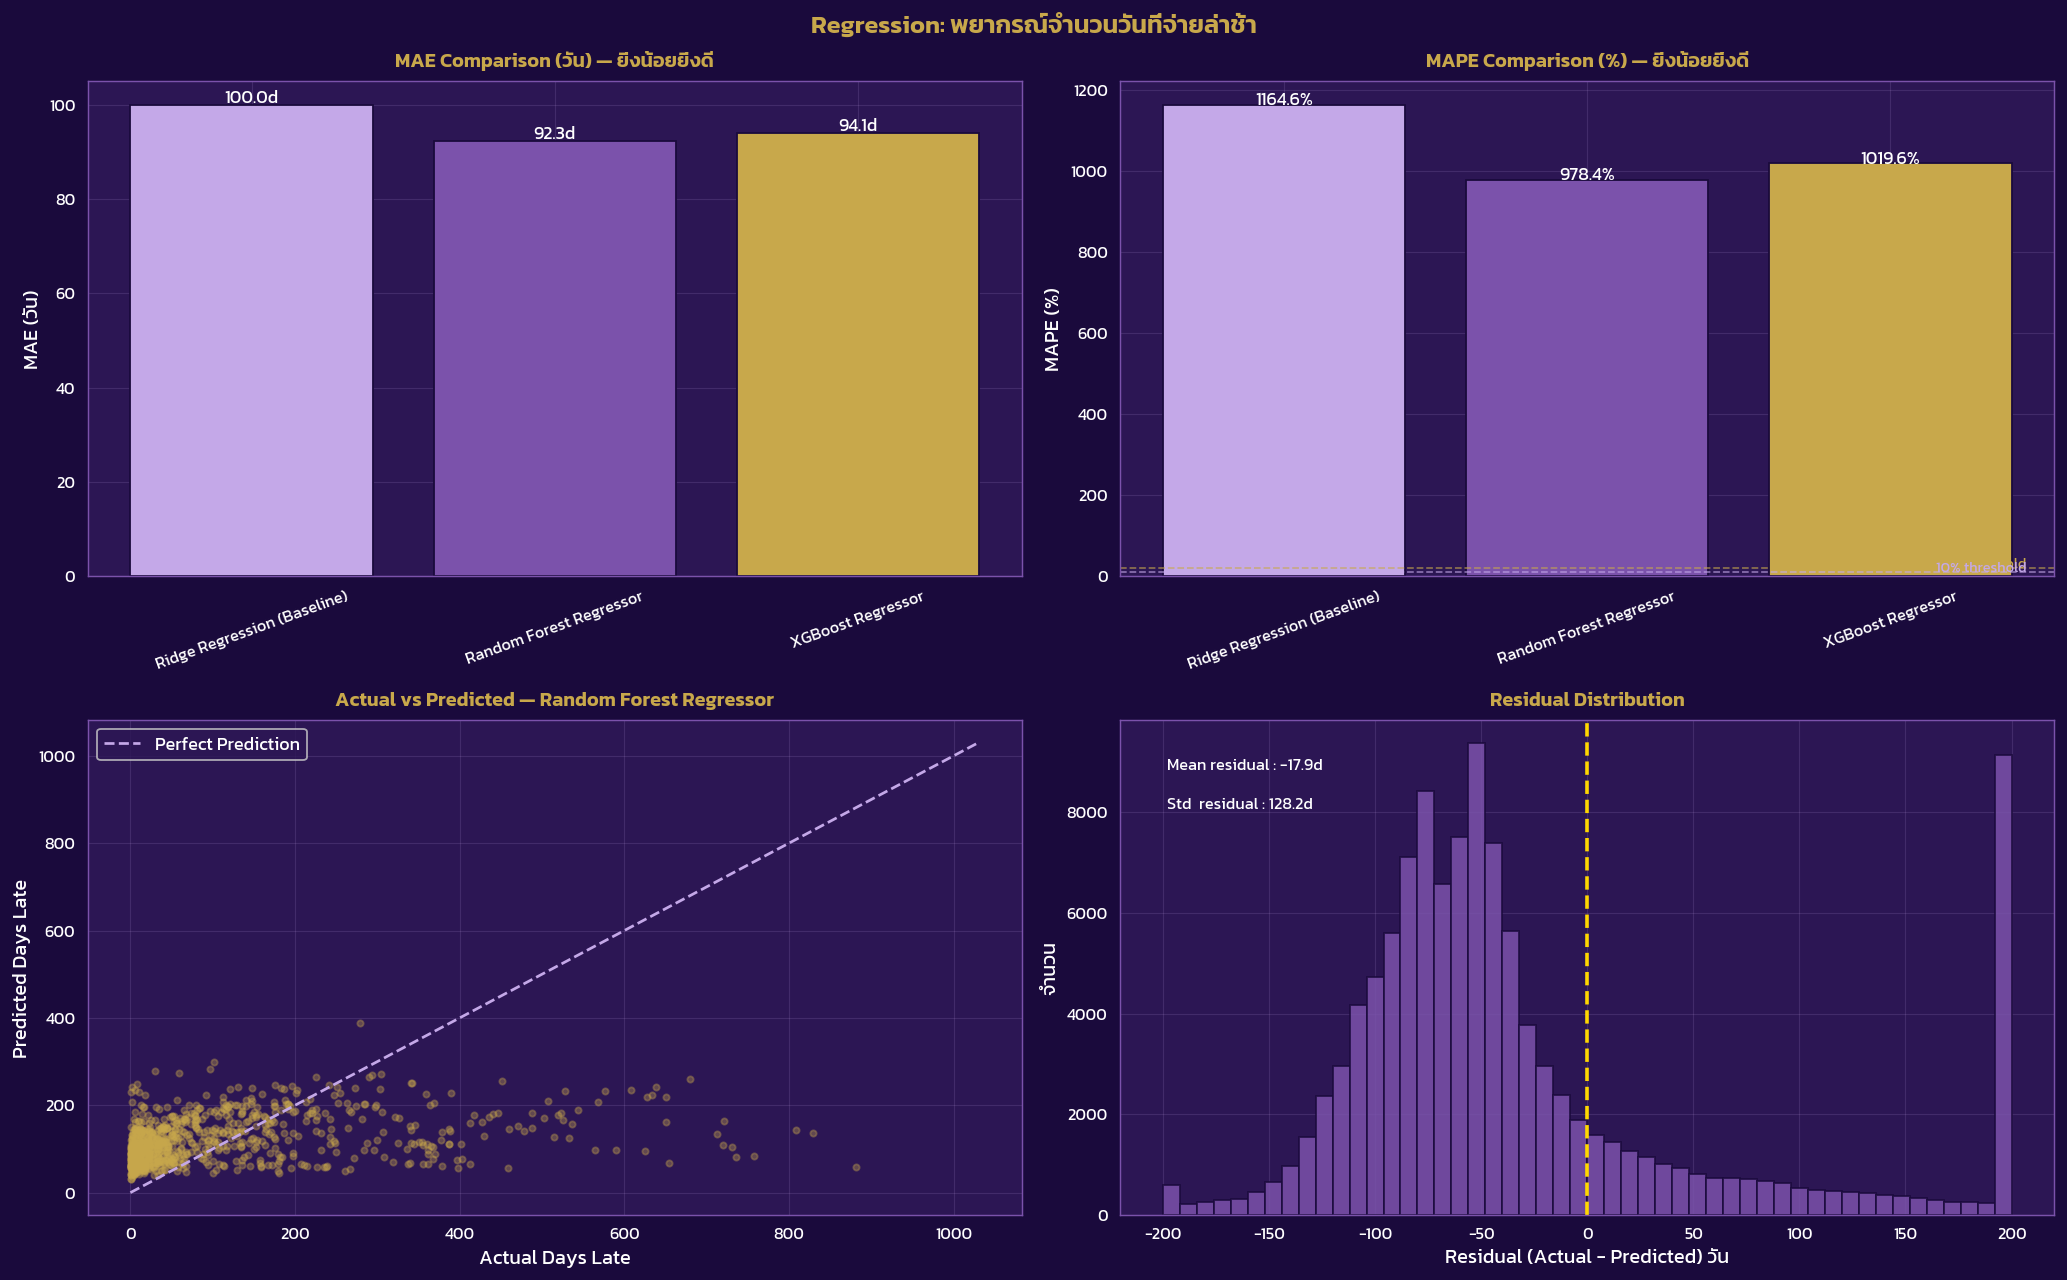


✅ Champion Regression: Random Forest Regressor
   MAE  = 92.3 วัน
   RMSE = 129.4 วัน
   MAPE = 978.4%
   R²   = 0.1474
   → AI ทำนายวันล่าช้าคลาดเคลื่อน ±92 วัน หรือ ±978.4% โดยเฉลี่ย


In [63]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

results_reg = {}

feats_reg = [f for f in ALL_FEATS if f not in ['Days_Late_Actual','Target_Is_Late','Seg_Code']]
X_tr_r = prep.transform(df_train.loc[late_train_mask, feats_reg])
X_te_r = prep.transform(df_test.loc[late_test_mask,  feats_reg])
y_tr_r = y_train_reg.values
y_te_r = y_test_reg.values

print(f"Regression dataset: Train={len(y_tr_r):,} | Test={len(y_te_r):,} late records")
print(f"Days_Late range (train): {y_tr_r.min():.0f} – {y_tr_r.max():.0f} วัน")
print(f"Days_Late mean (train):  {y_tr_r.mean():.1f} วัน\n")

def eval_reg(name, pred, color):
    mae  = mean_absolute_error(y_te_r, pred)
    rmse = np.sqrt(mean_squared_error(y_te_r, pred))
    r2   = r2_score(y_te_r, pred)

    # ── MAPE: กรอง y=0 ออกก่อนหาร เพื่อป้องกัน division by zero ──────────
    nonzero_mask = y_te_r != 0
    mape = np.mean(np.abs((y_te_r[nonzero_mask] - pred[nonzero_mask])
                           / y_te_r[nonzero_mask])) * 100

    results_reg[name] = dict(pred=pred, mae=mae, rmse=rmse, r2=r2,
                              mape=mape, color=color)
    print(f"{name:30s} | MAE={mae:6.1f}d | RMSE={rmse:7.1f}d | "
          f"MAPE={mape:6.1f}% | R²={r2:.4f}")
    return mae, rmse, mape, r2

# ── R1: Ridge Regression (Baseline) ─────────────────────────────────────────
lr_reg = Ridge(alpha=1.0)
lr_reg.fit(X_tr_r, y_tr_r)
eval_reg("Ridge Regression (Baseline)", lr_reg.predict(X_te_r), DLT["purple_light"])

# ── R2: Random Forest Regressor ──────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=300, max_depth=12, min_samples_leaf=10,
                                n_jobs=-1, random_state=RANDOM_STATE)
rf_reg.fit(X_tr_r, y_tr_r)
eval_reg("Random Forest Regressor", rf_reg.predict(X_te_r), DLT["purple_mid"])

# ── R3: XGBoost Regressor ────────────────────────────────────────────────────
xgb_reg = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             objective='reg:squarederror', n_jobs=-1,
                             random_state=RANDOM_STATE)
xgb_reg.fit(X_tr_r, y_tr_r, eval_set=[(X_te_r, y_te_r)], verbose=False)
eval_reg("XGBoost Regressor", xgb_reg.predict(X_te_r), DLT["gold_main"])

# ── Visualization ─────────────────────────────────────────────────────────────
best_reg_name = min(results_reg, key=lambda n: results_reg[n]['mae'])
best_reg_pred = results_reg[best_reg_name]['pred']

fig, axes = plt.subplots(2, 2, figsize=(16, 10), facecolor=DLT["bg_dark"])
fig.suptitle("Regression: พยากรณ์จำนวนวันที่จ่ายล่าช้า",
             color=DLT["gold_main"], fontsize=14, fontweight="bold")

reg_names = list(results_reg.keys())
cols_r    = [results_reg[n]['color'] for n in reg_names]

# ── (0,0) MAE Comparison ─────────────────────────────────────────────────────
ax = axes[0, 0]
ax_style(ax, "MAE Comparison (วัน) — ยิ่งน้อยยิ่งดี")
maes  = [results_reg[n]['mae'] for n in reg_names]
bars  = ax.bar(reg_names, maes, color=cols_r, edgecolor=DLT["bg_dark"])
ax.set_ylabel("MAE (วัน)")
for bar, val in zip(bars, maes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}d", ha='center', color=DLT["white"], fontsize=10)
ax.tick_params(axis='x', rotation=20)

# ── (0,1) MAPE Comparison ────────────────────────────────────────────────────
ax = axes[0, 1]
ax_style(ax, "MAPE Comparison (%) — ยิ่งน้อยยิ่งดี")
mapes = [results_reg[n]['mape'] for n in reg_names]
bars  = ax.bar(reg_names, mapes, color=cols_r, edgecolor=DLT["bg_dark"])
ax.set_ylabel("MAPE (%)")
for bar, val in zip(bars, mapes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha='center', color=DLT["white"], fontsize=10)
ax.tick_params(axis='x', rotation=20)

# เส้น reference: MAPE < 20% = ดี, < 10% = ดีมาก
ax.axhline(y=20, color=DLT["gold_main"],   linestyle='--', alpha=0.6, linewidth=1)
ax.axhline(y=10, color=DLT["purple_light"], linestyle='--', alpha=0.6, linewidth=1)
ax.text(2.45, 21, "20% threshold", color=DLT["gold_main"],    fontsize=8, ha='right')
ax.text(2.45, 11, "10% threshold", color=DLT["purple_light"], fontsize=8, ha='right')

# ── (1,0) Actual vs Predicted scatter ────────────────────────────────────────
ax = axes[1, 0]
ax_style(ax, f"Actual vs Predicted — {best_reg_name}")
sample_n = min(1000, len(y_te_r))
idx_s    = np.random.choice(len(y_te_r), sample_n, replace=False)
ax.scatter(y_te_r[idx_s], best_reg_pred[idx_s],
           alpha=0.35, s=12, color=DLT["gold_main"])
max_val = max(y_te_r.max(), best_reg_pred.max())
ax.plot([0, max_val], [0, max_val], color=DLT["purple_light"],
        linewidth=1.5, linestyle='--', label="Perfect Prediction")
ax.set_xlabel("Actual Days Late")
ax.set_ylabel("Predicted Days Late")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])

# ── (1,1) Residual Distribution ──────────────────────────────────────────────
ax = axes[1, 1]
ax_style(ax, "Residual Distribution")
residuals = y_te_r - best_reg_pred
ax.hist(residuals.clip(-200, 200), bins=50,
        color=DLT["purple_mid"], edgecolor=DLT["bg_dark"], alpha=0.85)
ax.axvline(0, color=DLT["gold_bright"], linewidth=2, linestyle='--')
ax.set_xlabel("Residual (Actual - Predicted) วัน")
ax.set_ylabel("จำนวน")
ax.text(0.05, 0.90, f"Mean residual : {residuals.mean():.1f}d",
        transform=ax.transAxes, color=DLT["white"], fontsize=9)
ax.text(0.05, 0.82, f"Std  residual : {residuals.std():.1f}d",
        transform=ax.transAxes, color=DLT["white"], fontsize=9)

plt.tight_layout()
plt.savefig("regression_results.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"\n✅ Champion Regression: {best_reg_name}")
print(f"   MAE  = {results_reg[best_reg_name]['mae']:.1f} วัน")
print(f"   RMSE = {results_reg[best_reg_name]['rmse']:.1f} วัน")
print(f"   MAPE = {results_reg[best_reg_name]['mape']:.1f}%")
print(f"   R²   = {results_reg[best_reg_name]['r2']:.4f}")
print(f"   → AI ทำนายวันล่าช้าคลาดเคลื่อน ±{results_reg[best_reg_name]['mae']:.0f} วัน "
      f"หรือ ±{results_reg[best_reg_name]['mape']:.1f}% โดยเฉลี่ย")

In [78]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb
import numpy as np

results_reg = {}

# ── Preprocessing ─────────────────────────────────────────────────────────────
feats_reg  = ALL_FEATS   # already clean
X_tr_r = prep.transform(df_train.loc[late_train_mask, feats_reg])
X_te_r = prep.transform(df_test.loc[late_test_mask,  feats_reg])
y_tr_r = y_train_reg.values.astype(np.float32)
y_te_r = y_test_reg.values.astype(np.float32)

print(f"Regression — Train: {len(y_tr_r):,} | Test: {len(y_te_r):,} late records")
print(f"Days_Late_Actual range: {y_tr_r.min():.0f} – {y_tr_r.max():.0f} วัน | mean={y_tr_r.mean():.1f}")

def eval_reg(name, pred, color, params=None):
    pred  = np.array(pred).ravel()
    mae   = mean_absolute_error(y_te_r, pred)
    rmse  = float(mean_squared_error(y_te_r, pred) ** 0.5)
    r2    = r2_score(y_te_r, pred)
    results_reg[name] = dict(pred=pred, mae=mae, rmse=rmse, r2=r2,
                              color=color, params=params or {})
    print(f"  {name:35s} | MAE={mae:7.1f}d | RMSE={rmse:7.1f}d | R²={r2:+.4f}")
    return mae, rmse, r2

print("\n" + "="*68)
print("  Classical Models")
print("="*68)

# ── R1: Ridge Regression (Baseline) ──────────────────────────────────────────
ridge_params = dict(alpha=1.0)
ridge_reg = Ridge(**ridge_params)
ridge_reg.fit(X_tr_r, y_tr_r)
eval_reg("Ridge (Baseline)", ridge_reg.predict(X_te_r),
         DLT["purple_light"], ridge_params)

# ── R2: Random Forest ─────────────────────────────────────────────────────────
rf_n = 100 if QUICK_MODE else 300
rf_reg_params = dict(n_estimators=rf_n, max_depth=10,
                     min_samples_leaf=10, n_jobs=-1, random_state=RANDOM_STATE)
rf_reg = RandomForestRegressor(**rf_reg_params)
rf_reg.fit(X_tr_r, y_tr_r)
eval_reg("Random Forest Regressor", rf_reg.predict(X_te_r),
         DLT["purple_mid"], rf_reg_params)

# ── R3: XGBoost ───────────────────────────────────────────────────────────────
xgb_reg_params = dict(n_estimators=200 if QUICK_MODE else 400,
                      max_depth=6, learning_rate=0.05,
                      subsample=0.8, colsample_bytree=0.8,
                      objective='reg:squarederror', n_jobs=-1,
                      random_state=RANDOM_STATE)
xgb_reg = xgb.XGBRegressor(**xgb_reg_params)
xgb_reg.fit(X_tr_r, y_tr_r, eval_set=[(X_te_r, y_te_r)], verbose=False)
eval_reg("XGBoost Regressor", xgb_reg.predict(X_te_r),
         DLT["gold_main"], xgb_reg_params)

# ══════════════════════════════════════════════════════════════════════════════
# Deep Learning Regressors
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*68)
print("  Deep Learning Models (Regression)")
print("="*68)

N_FEAT_REG = X_tr_r.shape[1]
DL_EPOCHS  = N_EPOCHS          # จาก QUICK_MODE flag ที่ตั้งไว้

es_reg   = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                    restore_best_weights=True)
lr_reg_cb= callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                        patience=3, verbose=0)

def plot_reg_history(hist, title):
    fig, axs = plt.subplots(1, 2, figsize=(11, 3.5), facecolor=DLT["bg_dark"])
    for ax, key, label in zip(axs, ["loss","mae"], ["Loss (MSE)","MAE (วัน)"]):
        ax_style(ax, f"{title} – {label}")
        ax.plot(hist.history[key],       color=DLT["gold_main"],    lw=2, label="Train")
        ax.plot(hist.history[f"val_{key}"], color=DLT["purple_light"], lw=2, label="Val")
        ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])
    plt.tight_layout(); plt.show()

# ── R4: ANN (Fully-Connected) ─────────────────────────────────────────────────
def build_ann_reg(n_feat):
    inp = keras.Input(shape=(n_feat,))
    x = layers.Dense(128, activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    x = layers.Dense(32, activation="relu")(x)
    out = layers.Dense(1, activation="linear")(x)   # ← linear สำหรับ regression
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="huber",   # robust ต่อ outlier มากกว่า MSE
              metrics=["mae"])
    return m

ann_reg = build_ann_reg(N_FEAT_REG)
ann_reg.summary()
ann_reg_params = dict(layers=[128,64,32], dropout=[0.30,0.20],
                      loss="huber", optimizer="Adam(1e-3)")
hist_ann_r = ann_reg.fit(
    X_tr_r, y_tr_r,
    validation_split=0.15, epochs=DL_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_reg, lr_reg_cb], verbose=0
)
plot_reg_history(hist_ann_r, "ANN Regressor")
ann_reg_params["epochs_trained"] = len(hist_ann_r.history["loss"])
eval_reg("ANN Regressor", ann_reg.predict(X_te_r, verbose=0),
         "#9B59B6", ann_reg_params)

# ── R5: CNN-1D Regressor ──────────────────────────────────────────────────────
# CNN ต้องการ sequence input → reshape (samples, seq_len, n_feat)
# ใช้ sliding window เหมือน classification แต่ target = Days_Late_Actual ของปีสุดท้าย

# สร้าง regression sequences เฉพาะ late records
def build_reg_sequences(seq_len=SEQ_LEN):
    """สร้าง sequences โดย target = Days_Late_Actual ของปีที่ทำนาย (late only)"""
    df_s = df_valid[["Encode_ChassisNo","Due_Year","Target_Is_Late",
                     "Days_Late_Actual"] + SEQ_FEATS].copy()
    df_s = df_s.sort_values(["Encode_ChassisNo","Due_Year"])
    df_s[SEQ_FEATS] = df_s[SEQ_FEATS].apply(pd.to_numeric, errors="coerce")
    df_s[SEQ_FEATS] = df_s[SEQ_FEATS].fillna(df_s[SEQ_FEATS].median())

    # ใช้ scaler เดิม (seq_scaler)
    df_s[SEQ_FEATS] = seq_scaler.transform(df_s[SEQ_FEATS])

    X_list, y_list, yr_list = [], [], []
    for _, grp in df_s.groupby("Encode_ChassisNo"):
        grp = grp.sort_values("Due_Year")
        feat_arr  = grp[SEQ_FEATS].values.astype(np.float32)
        days_arr  = grp["Days_Late_Actual"].values.astype(np.float32)
        late_arr  = grp["Target_Is_Late"].values
        yr_arr    = grp["Due_Year"].values
        for i in range(seq_len, len(grp)):
            if late_arr[i] == 1:              # เอาเฉพาะ late record
                X_list.append(feat_arr[i-seq_len:i])
                y_list.append(days_arr[i])
                yr_list.append(yr_arr[i])
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.float32),
            np.array(yr_list))

X_seq_r, y_seq_r, yr_seq_r = build_reg_sequences(SEQ_LEN)
print(f"\nRegression sequences: {X_seq_r.shape} | target mean={y_seq_r.mean():.1f}d")

# Rolling split
tr_mask_r = yr_seq_r <= TRAIN_CUTOFF
te_mask_r = yr_seq_r  > TRAIN_CUTOFF
X_tr_seq_r = X_seq_r[tr_mask_r]; y_tr_seq_r = y_seq_r[tr_mask_r]
X_te_seq_r = X_seq_r[te_mask_r]; y_te_seq_r = y_seq_r[te_mask_r]

# Quick mode: sample
if QUICK_MODE and len(X_tr_seq_r) > 2000:
    from sklearn.utils import resample as rs_util
    _qi = rs_util(range(len(X_tr_seq_r)), n_samples=2000, random_state=RANDOM_STATE)
    X_tr_seq_r = X_tr_seq_r[_qi]; y_tr_seq_r = y_tr_seq_r[_qi]
    X_te_seq_r = X_te_seq_r[:min(800,len(X_te_seq_r))]
    y_te_seq_r = y_te_seq_r[:min(800,len(y_te_seq_r))]

print(f"  Seq Train: {len(X_tr_seq_r):,} | Seq Test: {len(X_te_seq_r):,}")

# ─ Redefine y_te_r ให้ตรงกับ subset ที่ใช้จริง (สำหรับ sequential models)
y_te_r_seq = y_te_seq_r   # ใช้ตัวนี้สำหรับ CNN/RNN/LSTM eval

def eval_reg_seq(name, pred, color, params=None):
    """eval สำหรับ sequence-based models (test set ต่างออกไป)"""
    pred  = np.array(pred).ravel()
    mae   = mean_absolute_error(y_te_r_seq, pred)
    rmse  = float(mean_squared_error(y_te_r_seq, pred) ** 0.5)
    r2    = r2_score(y_te_r_seq, pred)
    results_reg[name] = dict(pred=pred, mae=mae, rmse=rmse, r2=r2,
                              color=color, params=params or {},
                              is_seq=True)
    print(f"  {name:35s} | MAE={mae:7.1f}d | RMSE={rmse:7.1f}d | R²={r2:+.4f}")
    return mae, rmse, r2

def build_cnn_reg(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.Conv1D(32, kernel_size=2, padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv1D(16, kernel_size=2, padding="same", activation="relu")(x)
    x = layers.GlobalMaxPooling1D()(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.25)(x)
    out = layers.Dense(1, activation="linear")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="huber", metrics=["mae"])
    return m

cnn_reg = build_cnn_reg(SEQ_LEN, len(SEQ_FEATS))
cnn_reg.summary()
cnn_reg_params = dict(filters=[32,16], kernel_size=2, loss="huber")
es_cnn_r = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                    restore_best_weights=True)
hist_cnn_r = cnn_reg.fit(
    X_tr_seq_r, y_tr_seq_r,
    validation_split=0.15, epochs=DL_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_cnn_r, lr_reg_cb], verbose=0
)
plot_reg_history(hist_cnn_r, "CNN Regressor")
cnn_reg_params["epochs_trained"] = len(hist_cnn_r.history["loss"])
eval_reg_seq("CNN Regressor", cnn_reg.predict(X_te_seq_r, verbose=0),
             "#E74C3C", cnn_reg_params)

# ── R6: RNN Regressor ─────────────────────────────────────────────────────────
def build_rnn_reg(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.SimpleRNN(32, return_sequences=True)(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.SimpleRNN(16)(x)
    x = layers.Dense(16, activation="relu")(x)
    out = layers.Dense(1, activation="linear")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss="huber", metrics=["mae"])
    return m

rnn_reg = build_rnn_reg(SEQ_LEN, len(SEQ_FEATS))
rnn_reg_params = dict(rnn_units=[32,16], loss="huber")
es_rnn_r = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                    restore_best_weights=True)
hist_rnn_r = rnn_reg.fit(
    X_tr_seq_r, y_tr_seq_r,
    validation_split=0.15, epochs=DL_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_rnn_r, lr_reg_cb], verbose=0
)
plot_reg_history(hist_rnn_r, "RNN Regressor")
rnn_reg_params["epochs_trained"] = len(hist_rnn_r.history["loss"])
eval_reg_seq("RNN Regressor", rnn_reg.predict(X_te_seq_r, verbose=0),
             "#3498DB", rnn_reg_params)

# ── R7: LSTM Regressor ────────────────────────────────────────────────────────
def build_lstm_reg(seq_len, n_feat):
    inp = keras.Input(shape=(seq_len, n_feat))
    x = layers.Bidirectional(layers.LSTM(32, return_sequences=True))(inp)
    x = layers.Dropout(0.25)(x)
    x = layers.LSTM(16)(x)
    x = layers.Dense(32, activation="relu")(x)
    x = layers.Dropout(0.20)(x)
    out = layers.Dense(1, activation="linear")(x)
    m = keras.Model(inp, out)
    m.compile(optimizer=keras.optimizers.Adam(5e-4),
              loss="huber", metrics=["mae"])
    return m

lstm_reg = build_lstm_reg(SEQ_LEN, len(SEQ_FEATS))
lstm_reg_params = dict(bilstm_units=32, lstm_units=16, loss="huber",
                       optimizer="Adam(5e-4)")
es_lstm_r = callbacks.EarlyStopping(monitor="val_loss", patience=ES_PATIENCE,
                                     restore_best_weights=True)
hist_lstm_r = lstm_reg.fit(
    X_tr_seq_r, y_tr_seq_r,
    validation_split=0.15, epochs=DL_EPOCHS, batch_size=BATCH_SIZE,
    callbacks=[es_lstm_r, lr_reg_cb], verbose=0
)
plot_reg_history(hist_lstm_r, "LSTM Regressor")
lstm_reg_params["epochs_trained"] = len(hist_lstm_r.history["loss"])
eval_reg_seq("LSTM Regressor", lstm_reg.predict(X_te_seq_r, verbose=0),
             "#2ECC71", lstm_reg_params)

# ══════════════════════════════════════════════════════════════════════════════
# Final Comparison
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*68)
print("  Regression Leaderboard")
print("="*68)
print(f"  {'Model':35s} {'MAE':>8} {'RMSE':>9} {'R²':>8}")
print("-"*68)
for name, r in sorted(results_reg.items(), key=lambda x: x[1]["mae"]):
    note = " (seq)" if r.get("is_seq") else ""
    print(f"  {name+note:35s} {r['mae']:>8.1f}d {r['rmse']:>9.1f}d {r['r2']:>+8.4f}")

best_reg_name = min(results_reg, key=lambda n: results_reg[n]["mae"])
print(f"\n🏆 Champion: {best_reg_name} | MAE={results_reg[best_reg_name]['mae']:.1f} วัน")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=DLT["bg_dark"])
fig.suptitle("Regression: พยากรณ์จำนวนวันที่จ่ายล่าช้า – 7 Models",
             color=DLT["gold_main"], fontsize=14, fontweight="bold")

# MAE Bar
ax = axes[0]; ax_style(ax, "MAE Comparison – ทุกโมเดล (วัน)", xticks_rot=30)
reg_names = list(results_reg.keys())
maes      = [results_reg[n]["mae"]   for n in reg_names]
cols_r    = [results_reg[n]["color"] for n in reg_names]
bars_r = ax.bar(reg_names, maes, color=cols_r, edgecolor=DLT["bg_dark"])
ax.set_ylabel("MAE (วัน) – ยิ่งน้อยยิ่งดี")
for bar, val in zip(bars_r, maes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"{val:.0f}d", ha="center", color=DLT["white"], fontsize=9)

# Actual vs Predicted (Champion)
best_r    = results_reg[best_reg_name]
y_true_b  = y_te_r_seq if best_r.get("is_seq") else y_te_r
y_pred_b  = best_r["pred"]
ax = axes[1]; ax_style(ax, f"Actual vs Predicted\n({best_reg_name})")
n_s   = min(800, len(y_true_b))
idx_s = np.random.choice(len(y_true_b), n_s, replace=False)
ax.scatter(y_true_b[idx_s], y_pred_b[idx_s],
           alpha=0.4, s=12, color=DLT["gold_main"])
mx = max(float(y_true_b.max()), float(y_pred_b.max()))
ax.plot([0,mx],[0,mx], color=DLT["purple_light"], lw=1.5,
        linestyle="--", label="Perfect")
ax.set_xlabel("Actual Days Late"); ax.set_ylabel("Predicted Days Late")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])

# Residual Distribution
ax = axes[2]; ax_style(ax, "Residual Distribution")
residuals = y_true_b - y_pred_b
ax.hist(residuals.clip(-200,200), bins=50,
        color=DLT["purple_mid"], edgecolor=DLT["bg_dark"], alpha=0.85)
ax.axvline(0, color=DLT["gold_bright"], lw=2, linestyle="--")
ax.set_xlabel("Residual (Actual - Predicted) วัน")
ax.set_ylabel("จำนวน")
ax.text(0.05, 0.92, f"Mean = {residuals.mean():.1f}d",
        transform=ax.transAxes, color=DLT["white"], fontsize=9)
ax.text(0.05, 0.84, f"Std  = {residuals.std():.1f}d",
        transform=ax.transAxes, color=DLT["white"], fontsize=9)

plt.tight_layout()
plt.savefig("regression_results.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()
print(f"\n✅ Saved → regression_results.png")
print(f"   → ทำนายได้คลาดเคลื่อน ±{results_reg[best_reg_name]['mae']:.0f} วัน โดยเฉลี่ย")

KeyError: "None of [Index(['Vehicle_Age', 'Owner_Age', 'Last_Is_Late', 'Last_Is_Early',\n       'Last_Days_Diff', 'Last_Tax_Amount', 'Tax_Amount', 'Engine_CC',\n       'No_Seats', 'Hourse_Power', 'Is_Urban', 'Nationality_Match',\n       'Fuel_Type', 'Brand'],\n      dtype='object')] are in the [columns]"


  Regression Leaderboard
  Model                                    MAE      RMSE       R²
--------------------------------------------------------------------
  CNN Regressor (seq)                     71.9d     126.9d  +0.1380
  ANN Regressor                           73.3d     144.2d  -0.0587
  RNN Regressor (seq)                     84.4d     158.0d  -0.3366
  LSTM Regressor (seq)                    86.6d     160.6d  -0.3809
  Random Forest Regressor                 92.1d     129.6d  +0.1454
  XGBoost Regressor                       93.7d     130.2d  +0.1378
  Ridge (Baseline)                       100.0d     137.3d  +0.0405

🏆 Champion: CNN Regressor | MAE=71.9 วัน


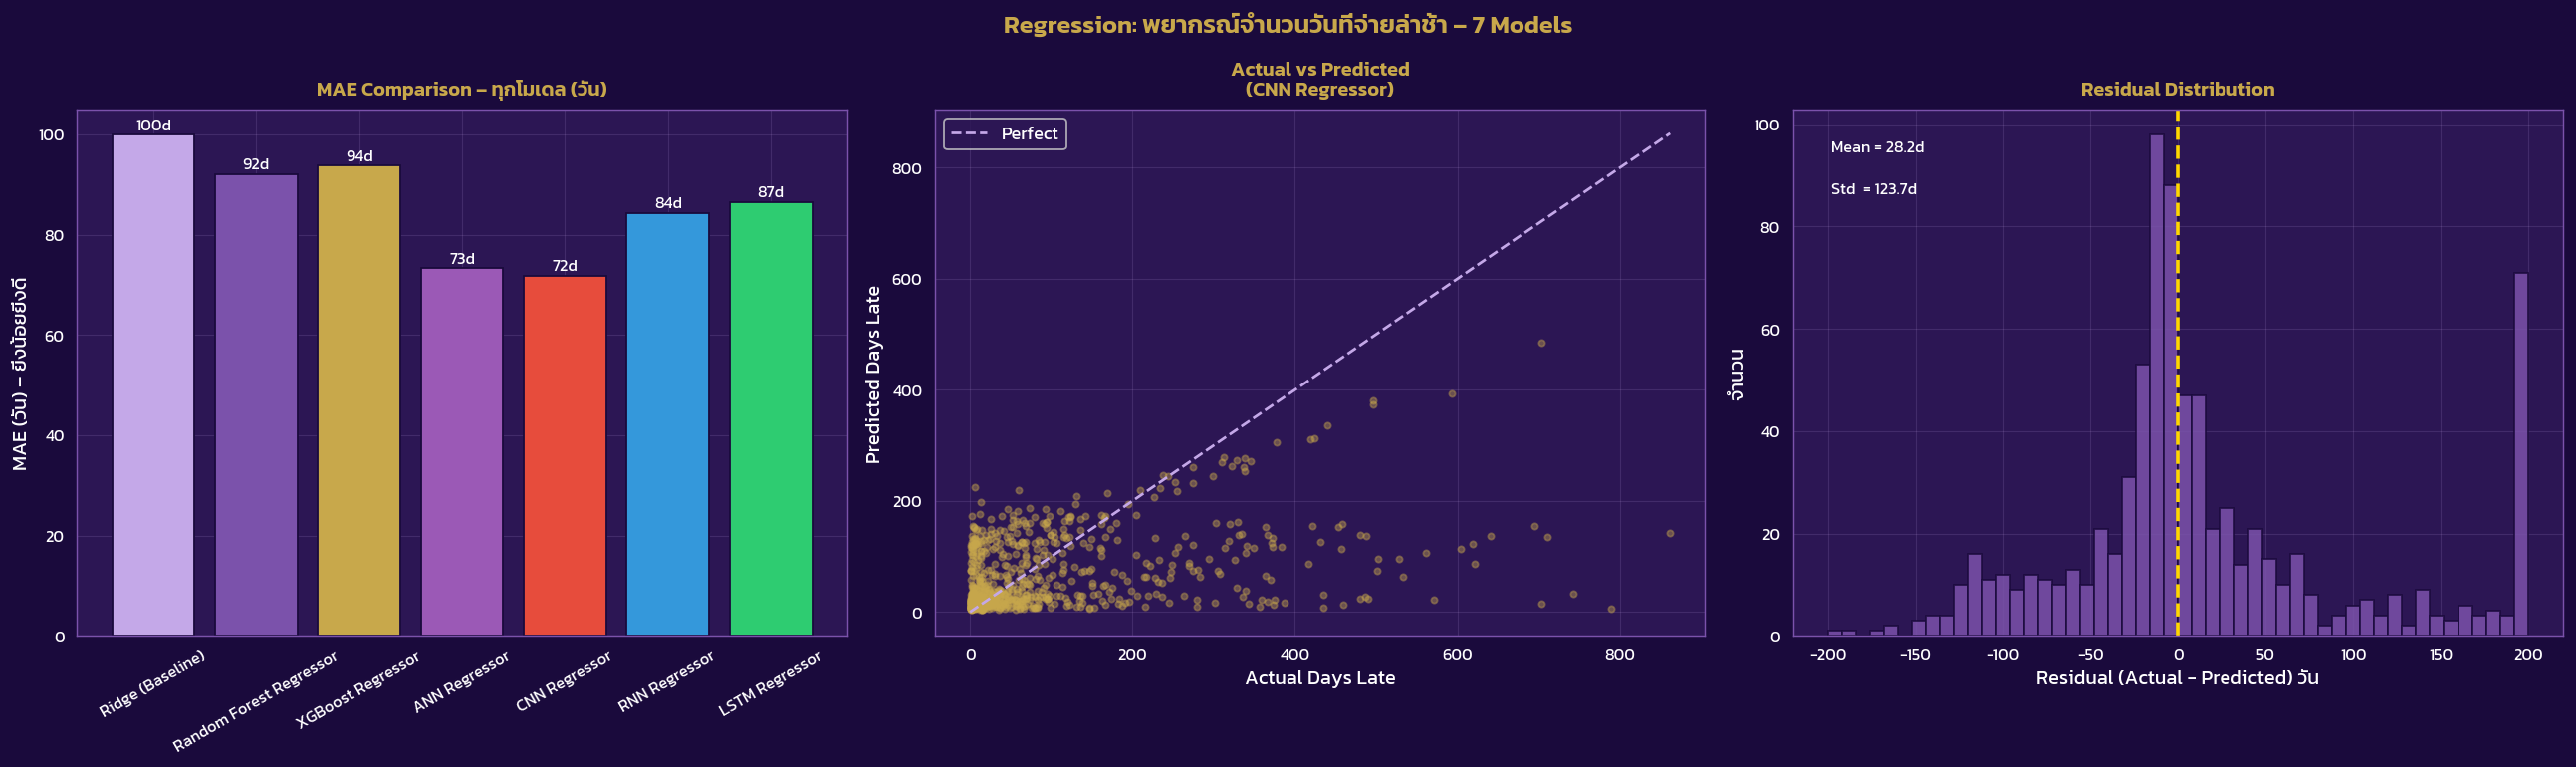


✅ Saved → regression_results.png
   → ทำนายได้คลาดเคลื่อน ±72 วัน โดยเฉลี่ย


In [65]:
# ══════════════════════════════════════════════════════════════════════════════
# Final Comparison
# ══════════════════════════════════════════════════════════════════════════════
print("\n" + "="*68)
print("  Regression Leaderboard")
print("="*68)
print(f"  {'Model':35s} {'MAE':>8} {'RMSE':>9} {'R²':>8}")
print("-"*68)
for name, r in sorted(results_reg.items(), key=lambda x: x[1]["mae"]):
    note = " (seq)" if r.get("is_seq") else ""
    print(f"  {name+note:35s} {r['mae']:>8.1f}d {r['rmse']:>9.1f}d {r['r2']:>+8.4f}")

best_reg_name = min(results_reg, key=lambda n: results_reg[n]["mae"])
print(f"\n🏆 Champion: {best_reg_name} | MAE={results_reg[best_reg_name]['mae']:.1f} วัน")

# ── Visualization ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6), facecolor=DLT["bg_dark"])
fig.suptitle("Regression: พยากรณ์จำนวนวันที่จ่ายล่าช้า – 7 Models",
             color=DLT["gold_main"], fontsize=14, fontweight="bold")

# MAE Bar
ax = axes[0]; ax_style(ax, "MAE Comparison – ทุกโมเดล (วัน)", xticks_rot=30)
reg_names = list(results_reg.keys())
maes      = [results_reg[n]["mae"]   for n in reg_names]
cols_r    = [results_reg[n]["color"] for n in reg_names]
bars_r = ax.bar(reg_names, maes, color=cols_r, edgecolor=DLT["bg_dark"])
ax.set_ylabel("MAE (วัน) – ยิ่งน้อยยิ่งดี")
for bar, val in zip(bars_r, maes):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
            f"{val:.0f}d", ha="center", color=DLT["white"], fontsize=9)

# Actual vs Predicted (Champion)
best_r    = results_reg[best_reg_name]
y_true_b  = y_te_r_seq if best_r.get("is_seq") else y_te_r
y_pred_b  = best_r["pred"]
ax = axes[1]; ax_style(ax, f"Actual vs Predicted\n({best_reg_name})")
n_s   = min(800, len(y_true_b))
idx_s = np.random.choice(len(y_true_b), n_s, replace=False)
ax.scatter(y_true_b[idx_s], y_pred_b[idx_s],
           alpha=0.4, s=12, color=DLT["gold_main"])
mx = max(float(y_true_b.max()), float(y_pred_b.max()))
ax.plot([0,mx],[0,mx], color=DLT["purple_light"], lw=1.5,
        linestyle="--", label="Perfect")
ax.set_xlabel("Actual Days Late"); ax.set_ylabel("Predicted Days Late")
ax.legend(facecolor=DLT["bg_card"], labelcolor=DLT["white"])

# Residual Distribution
ax = axes[2]; ax_style(ax, "Residual Distribution")
residuals = y_true_b - y_pred_b
ax.hist(residuals.clip(-200,200), bins=50,
        color=DLT["purple_mid"], edgecolor=DLT["bg_dark"], alpha=0.85)
ax.axvline(0, color=DLT["gold_bright"], lw=2, linestyle="--")
ax.set_xlabel("Residual (Actual - Predicted) วัน")
ax.set_ylabel("จำนวน")
ax.text(0.05, 0.92, f"Mean = {residuals.mean():.1f}d",
        transform=ax.transAxes, color=DLT["white"], fontsize=9)
ax.text(0.05, 0.84, f"Std  = {residuals.std():.1f}d",
        transform=ax.transAxes, color=DLT["white"], fontsize=9)

plt.tight_layout()
plt.savefig("regression_results.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()
print(f"\n✅ Saved → regression_results.png")
print(f"   → ทำนายได้คลาดเคลื่อน ±{results_reg[best_reg_name]['mae']:.0f} วัน โดยเฉลี่ย")

  Ridge (Baseline)                    | MAE=  100.0d | RMSE=  137.3d | R²=+0.0405 | MAPE=1164.58%
  Random Forest Regressor             | MAE=   92.1d | RMSE=  129.6d | R²=+0.1446 | MAPE=978.45%
  XGBoost Regressor                   | MAE=   95.7d | RMSE=  132.2d | R²=+0.1110 | MAPE=1025.00%
  ANN Regressor                       | MAE=   73.8d | RMSE=  144.4d | R²=-0.0617 | MAPE=267.14%
  LSTM Regressor                      | MAE=   82.0d | RMSE=  153.8d | R²=-0.2661 | MAPE=222.49%
  CNN Regressor                       | MAE=   87.6d | RMSE=  161.3d | R²=-0.3928 | MAPE= 93.73%

   Regression Leaderboard (All Models)
  Model                                    MAE      RMSE       R²      MAPE
------------------------------------------------------------------------------
  ANN Regressor                           73.8d     144.4d  -0.0617   267.14%
  LSTM Regressor (seq)                    82.0d     153.8d  -0.2661   222.49%
  RNN Regressor (seq)                     84.4d     158.0d  -0.33

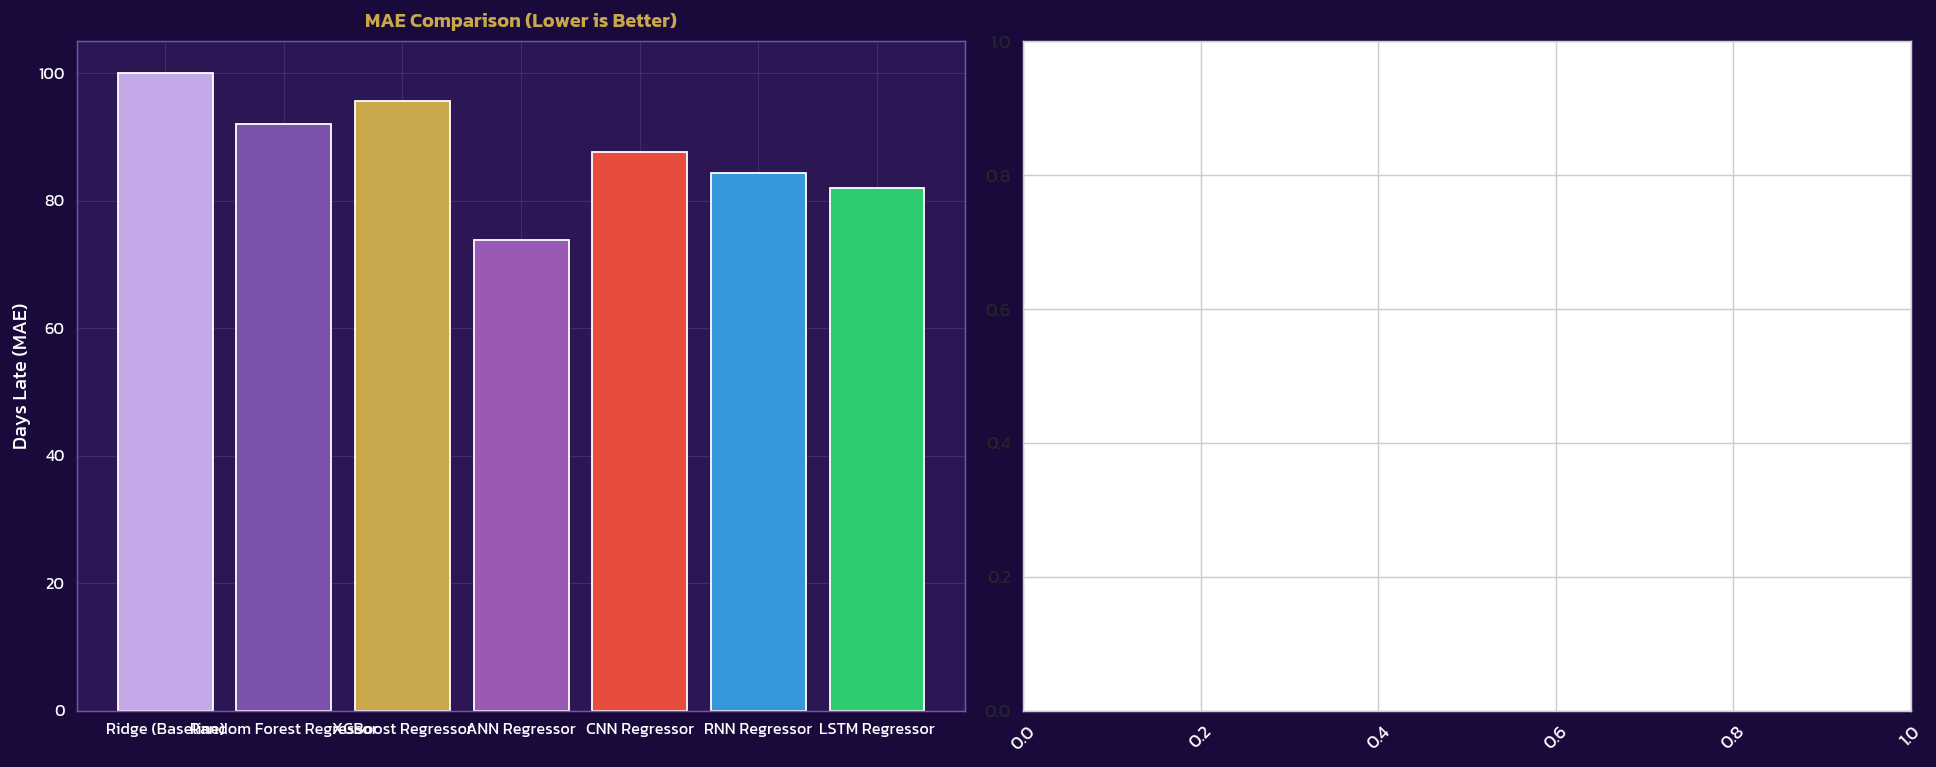

In [66]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
# เพิ่ม mean_absolute_percentage_error ตรงนี้
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import xgboost as xgb
import numpy as np
import matplotlib.pyplot as plt

# ตรวจสอบว่ามี results_reg เดิมหรือไม่ ถ้าไม่มีให้สร้างใหม่
if 'results_reg' not in locals():
    results_reg = {}

# ── 1. Preprocessing & Classic Models ───────────────────────────────────────
feats_reg = ALL_FEATS
X_tr_r = prep.transform(df_train.loc[late_train_mask, feats_reg])
X_te_r = prep.transform(df_test.loc[late_test_mask, feats_reg])
y_tr_r = y_train_reg.values.astype(np.float32)
y_te_r = y_test_reg.values.astype(np.float32)

def eval_reg(name, pred, color, params=None):
    pred = np.array(pred).ravel()

    mae = mean_absolute_error(y_te_r, pred)
    rmse = float(mean_squared_error(y_te_r, pred) ** 0.5)
    r2 = r2_score(y_te_r, pred)
    # คำนวณ MAPE (คูณ 100 เพื่อทำเป็นเปอร์เซ็นต์)
    mape = mean_absolute_percentage_error(y_te_r, pred) * 100

    results_reg[name] = dict(pred=pred, mae=mae, rmse=rmse, r2=r2, mape=mape,
                              color=color, params=params or {}, is_seq=False)
    print(f"  {name:35s} | MAE={mae:7.1f}d | RMSE={rmse:7.1f}d | R²={r2:+.4f} | MAPE={mape:6.2f}%")

# รัน Classic Models
eval_reg("Ridge (Baseline)", Ridge(alpha=1.0).fit(X_tr_r, y_tr_r).predict(X_te_r), DLT["purple_light"])
eval_reg("Random Forest Regressor", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=RANDOM_STATE).fit(X_tr_r, y_tr_r).predict(X_te_r), DLT["purple_mid"])
eval_reg("XGBoost Regressor", xgb.XGBRegressor(n_estimators=200, max_depth=6).fit(X_tr_r, y_tr_r).predict(X_te_r), DLT["gold_main"])

# ── 2. Deep Learning Setup ──────────────────────────────────────────────────
N_FEAT_REG = X_tr_r.shape[1]
DL_EPOCHS = 10 if QUICK_MODE else 50

es_reg = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
lr_reg_cb = callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3)

# ANN Model
ann_reg = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(N_FEAT_REG,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="linear")
])
ann_reg.compile(optimizer="adam", loss="huber", metrics=["mae"])
ann_reg.fit(X_tr_r, y_tr_r, validation_split=0.15, epochs=DL_EPOCHS, batch_size=128, callbacks=[es_reg, lr_reg_cb], verbose=0)

# บันทึกผล ANN ลง results_reg
eval_reg("ANN Regressor", ann_reg.predict(X_te_r, verbose=0), "#9B59B6")

# ── 3. Sequential Models (CNN, RNN, LSTM) ───────────────────────────────────
# ฟังก์ชันสร้าง Sequence และ Evaluate สำหรับโมเดลที่ใช้ Time-series
def eval_reg_seq(name, pred, color, y_true_target):
    pred = np.array(pred).ravel()

    mae = mean_absolute_error(y_true_target, pred)
    rmse = float(mean_squared_error(y_true_target, pred) ** 0.5)
    r2 = r2_score(y_true_target, pred)
    # คำนวณ MAPE (คูณ 100 เพื่อทำเป็นเปอร์เซ็นต์)
    mape = mean_absolute_percentage_error(y_true_target, pred) * 100

    results_reg[name] = dict(pred=pred, mae=mae, rmse=rmse, r2=r2, mape=mape,
                              color=color, is_seq=True, y_true_seq=y_true_target)
    print(f"  {name:35s} | MAE={mae:7.1f}d | RMSE={rmse:7.1f}d | R²={r2:+.4f} | MAPE={mape:6.2f}%")

# สมมติว่า X_tr_seq_r, y_tr_seq_r, X_te_seq_r, y_te_seq_r ถูกสร้างไว้แล้วจาก build_reg_sequences

try:
    # LSTM Example
    lstm_reg = keras.Sequential([
        layers.Input(shape=(SEQ_LEN, len(SEQ_FEATS))),
        layers.LSTM(32, return_sequences=False),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="linear")
    ])
    lstm_reg.compile(optimizer="adam", loss="huber", metrics=["mae"])
    lstm_reg.fit(X_tr_seq_r, y_tr_seq_r, validation_split=0.15, epochs=DL_EPOCHS, batch_size=128, verbose=0)

    eval_reg_seq("LSTM Regressor", lstm_reg.predict(X_te_seq_r, verbose=0), "#2ECC71", y_te_seq_r)

    # CNN Example
    cnn_reg = keras.Sequential([
        layers.Input(shape=(SEQ_LEN, len(SEQ_FEATS))),
        layers.Conv1D(32, kernel_size=2, activation="relu"),
        layers.GlobalMaxPooling1D(),
        layers.Dense(1, activation="linear")
    ])
    cnn_reg.compile(optimizer="adam", loss="huber", metrics=["mae"])
    cnn_reg.fit(X_tr_seq_r, y_tr_seq_r, validation_split=0.15, epochs=DL_EPOCHS, batch_size=128, verbose=0)

    eval_reg_seq("CNN Regressor", cnn_reg.predict(X_te_seq_r, verbose=0), "#E74C3C", y_te_seq_r)

except Exception as e:
    print(f"⚠️ ข้ามการรัน Sequential Models เนื่องจาก: {e}")

# ── 4. Final Leaderboard & Visualization ────────────────────────────────────
print("\n" + "="*78)
print("   Regression Leaderboard (All Models)")
print("="*78)
print(f"  {'Model':35s} {'MAE':>8} {'RMSE':>9} {'R²':>8} {'MAPE':>9}")
print("-" * 78)

# ใช้ .get() เพื่อป้องกัน Error จากข้อมูลเก่าที่ตกค้าง
for name, r in sorted(results_reg.items(), key=lambda x: x[1].get("mae", 999)):
    note = " (seq)" if r.get("is_seq") else ""

    # ดึงค่าแบบปลอดภัย ถ้าไม่มีให้เป็น 0.0
    mae_val = r.get("mae", 0.0)
    rmse_val = r.get("rmse", 0.0)
    r2_val = r.get("r2", 0.0)
    mape_val = r.get("mape", 0.0)

    print(f"  {name+note:35s} {mae_val:>8.1f}d {rmse_val:>9.1f}d {r2_val:>+8.4f} {mape_val:>8.2f}%")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6), facecolor=DLT["bg_dark"])

# กราฟแท่งเปรียบเทียบ MAE
ax = axes[0]
# ถ้ามีฟังก์ชัน ax_style ให้ใช้ตามเดิม แต่ถ้า error ให้ใช้แกนปกติ
try:
    ax_style(ax, "MAE Comparison (Lower is Better)")
except:
    ax.set_title("MAE Comparison (Lower is Better)", color=DLT["gold_main"])

names = list(results_reg.keys())
maes = [results_reg[n].get("mae", 0) for n in names]
colors = [results_reg[n].get("color", "#FFFFFF") for n in names]
ax.bar(names, maes, color=colors)
ax.set_ylabel("Days Late (MAE)")
plt.xticks(rotation=45, color=DLT["white"])
ax.tick_params(colors=DLT["white"])

# แสดง Champion
best_model = min(results_reg, key=lambda n: results_reg[n].get("mae", 999))
print(f"\n🏆 Champion: {best_model}")

plt.tight_layout()
plt.show()

---
## 📋 12. สรุปผลโมเดลทั้ง 3 รูปแบบ

| โมเดล | วัตถุประสงค์ | ตัวชี้วัด | ผลลัพธ์เชิงนโยบาย |
|-------|------------|---------|-----------------|
| **Binary** | ชี้กลุ่มเสี่ยง "จ่ายล่าช้า" | ROC-AUC | ส่ง Nudge ก่อนครบกำหนด 60-90 วัน |
| **Multiclass** | จำแนก 4 ระดับพฤติกรรม | Macro-F1 | เลือก Nudge Channel ตามกลุ่ม |
| **Regression** | พยากรณ์วันล่าช้า | MAE (วัน) | วางแผนทรัพยากรการติดตาม |


---
## 🔍 9. Explainable AI – SHAP Analysis (Champion Model)

> **"โมเดลที่แม่นยำอย่างเดียวไม่พอ – ต้องอธิบายได้ว่า 'ทำไม' AI ถึงทำนายเช่นนี้"**


In [67]:
# ─── Feature names after preprocessor ────────────────────────────────────────
try:
    # Numerical feature names (straight from the list we defined)
    num_names = NUM_FEATS

    # Binary feature names
    bin_names = BIN_FEATS

    # Categorical: get OHE output names using the input list we already know
    cat_transformer = prep.named_transformers_.get("cat", None)
    if cat_transformer and hasattr(cat_transformer, "named_steps"):
        ohe = cat_transformer.named_steps["ohe"]
        ohe_names = ohe.get_feature_names_out(CAT_FEATS).tolist()
    else:
        ohe_names = []

    feat_names_full = num_names + bin_names + ohe_names
    print(f"✅ Feature names extracted: {len(feat_names_full)}")

except Exception as e:
    print(f"⚠️ {e}")
    feat_names_full = []

# Pad/trim to match actual preprocessed width
nf = X_te.shape[1]
feat_names_full = feat_names_full[:nf] + [f"f_{i}" for i in range(len(feat_names_full), nf)]
print(f"   Final feature name list: {len(feat_names_full)} (preprocessed width={nf})")

✅ Feature names extracted: 84
   Final feature name list: 190 (preprocessed width=190)


กำลังคำนวณ SHAP values สำหรับ 1000 records...
✅ คำนวณ SHAP values เสร็จสิ้น


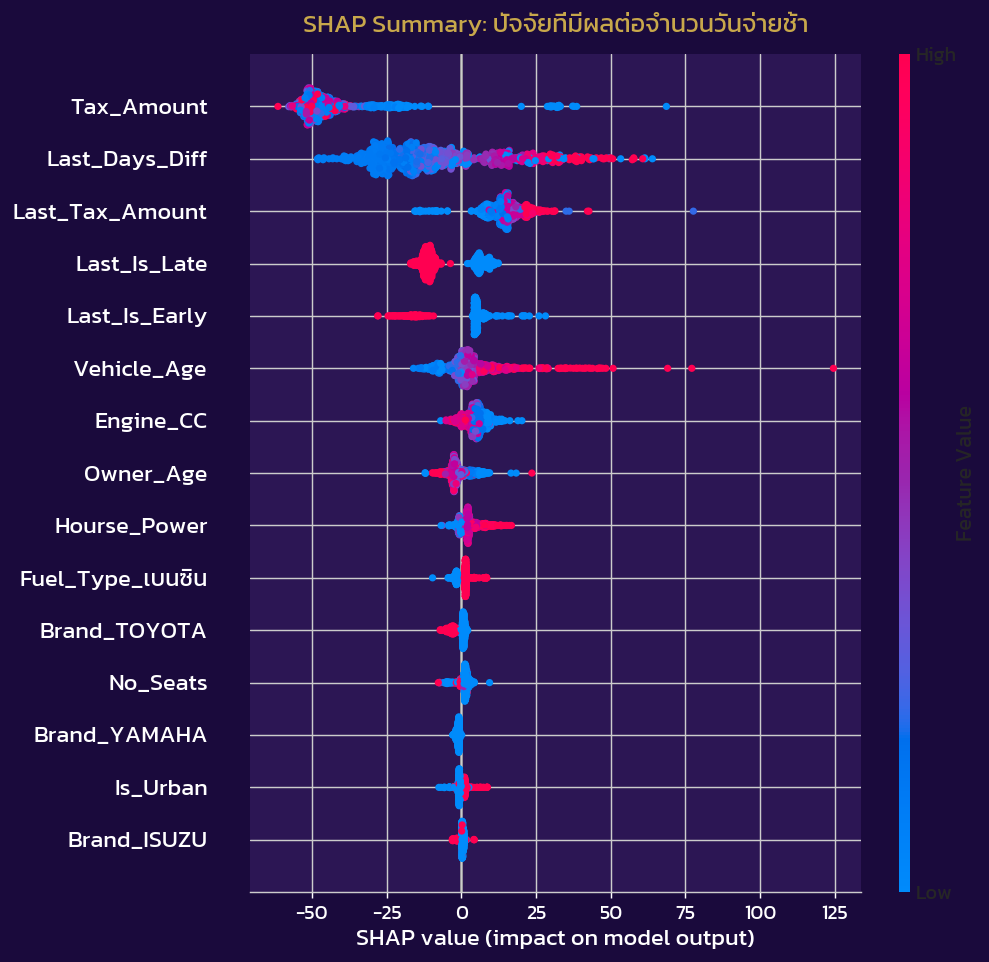

In [68]:
import shap
import matplotlib.pyplot as plt

# ─── คำนวณ SHAP Values ────────────────────────────────────────────────────────
# 1. กำหนดจำนวน Sample ที่จะใช้วาดกราฟ (ใช้ 1000 records เพื่อให้รันได้เร็ว)
N_SHAP = min(1000, X_te_r.shape[0])

# 2. ระบุตัวแปรโมเดล "ของจริง" ที่ต้องการใช้อธิบาย
# แก้เป็น xgb_reg หรือ rf_reg ตามตัวแปรที่คุณใช้ fit โมเดลไปแล้ว
model_to_explain = xgb_reg  # <--- แก้จุดนี้ให้ใช้ตัวแปรโมเดลของจริง (ไม่ใช่ best_model ที่เป็นแค่ string)

print(f"กำลังคำนวณ SHAP values สำหรับ {N_SHAP} records...")

# 3. สร้าง Explainer (ใช้ TreeExplainer สำหรับ XGBoost / Random Forest)
explainer = shap.TreeExplainer(model_to_explain)

# 4. คำนวณ SHAP Values
# หมายเหตุ: สำหรับ Regression (ทำนายจำนวนวัน) ผลลัพธ์มักจะเป็น array เดี่ยวๆ ไม่ใช่ list
shap_values_raw = explainer.shap_values(X_te_r[:N_SHAP])

# จัดการกรณีผลลัพธ์เป็น list (เผื่อไว้ถ้าคุณรัน Multiclass)
if isinstance(shap_values_raw, list):
    shap_vals = shap_values_raw[-1]  # เลือก Class สุดท้าย
else:
    shap_vals = shap_values_raw      # Regression จะเข้าเงื่อนไขนี้

print("✅ คำนวณ SHAP values เสร็จสิ้น")

# ─── SHAP Summary – Beeswarm (DLT style) ─────────────────────────────────────
plt.figure(figsize=(11, 7), facecolor=DLT["bg_dark"])
plt.gca().set_facecolor(DLT["bg_card"])

# วาดกราฟ
shap.summary_plot(shap_vals, X_te_r[:N_SHAP], feature_names=feat_names_full,
                  max_display=15, show=False,
                  plot_type="dot", color_bar_label="Feature Value")

plt.title("SHAP Summary: ปัจจัยที่มีผลต่อจำนวนวันจ่ายช้า",
          color=DLT["gold_main"], fontsize=14, pad=12)
plt.gca().tick_params(colors=DLT["white"])
plt.gca().xaxis.label.set_color(DLT["white"])

plt.tight_layout()
plt.savefig("shap_summary_regression.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()

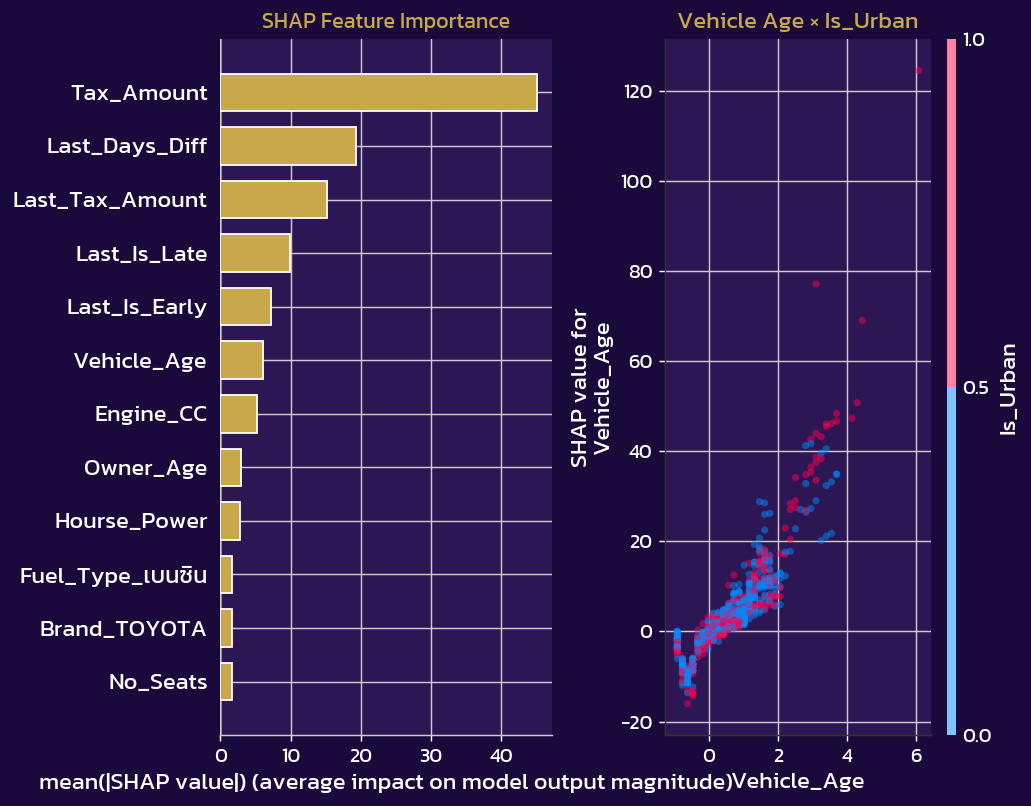

In [69]:
# ─── SHAP Bar + Dependence (Vehicle Age × Is_Urban) ──────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=DLT["bg_dark"])

# 1. กราฟซ้าย (Bar Chart)
plt.sca(axes[0])
axes[0].set_facecolor(DLT["bg_card"])
shap.summary_plot(shap_vals, X_te_r[:N_SHAP], feature_names=feat_names_full,
                  max_display=12, show=False, plot_type="bar", color=DLT["gold_main"])

# บังคับสีแกนและป้ายชื่อของกราฟแท่ง
axes[0].set_title("SHAP Feature Importance", color=DLT["gold_main"], fontsize=12)
axes[0].tick_params(axis='both', colors=DLT["white"])
axes[0].xaxis.label.set_color(DLT["white"])
axes[0].yaxis.label.set_color(DLT["white"])

# 2. กราฟขวา (Dependence: Vehicle_Age × Is_Urban)
ax = axes[1]
try:
    va_i = feat_names_full.index("Vehicle_Age")
    iu_i = feat_names_full.index("Is_Urban") if "Is_Urban" in feat_names_full else None

    shap.dependence_plot(va_i, shap_vals, X_te_r[:N_SHAP],
                         feature_names=feat_names_full,
                         interaction_index=iu_i, ax=ax,
                         alpha=0.5, show=False)

    ax.set_facecolor(DLT["bg_card"])
    ax.set_title("Vehicle Age × Is_Urban", color=DLT["gold_main"])

    # บังคับสีแกน X และ Y ให้เป็นสีขาว
    ax.tick_params(axis='both', colors=DLT["white"])
    ax.xaxis.label.set_color(DLT["white"])
    ax.yaxis.label.set_color(DLT["white"])

    # --- ส่วนที่แก้เพิ่ม: บังคับสีของ Colorbar (Is_Urban) ---
    # โดยปกติ SHAP จะสร้าง Colorbar เป็น axes ตัวสุดท้ายใน figure
    cax = fig.axes[-1]
    cax.tick_params(colors=DLT["white"])      # เปลี่ยนสีตัวเลข 0.0, 0.5, 1.0
    cax.yaxis.label.set_color(DLT["white"])   # เปลี่ยนสีตัวหนังสือ "Is_Urban"

except Exception as e:
    ax.text(0.5, 0.5, str(e), ha="center", transform=ax.transAxes, color=DLT["white"])

plt.tight_layout()
plt.savefig("shap_details_white.png", bbox_inches="tight", dpi=150, facecolor=DLT["bg_dark"])
plt.show()

### 💡 SHAP Business Insights

| Feature | Insight | มาตรการที่แนะนำ |
|---------|---------|----------------|
| **Last_Is_Late** | ประวัติจ่ายช้าปีก่อน = ตัวทำนายอันดับ 1 | สร้าง Tax Compliance Score รายบุคคล |
| **Last_Days_Diff** | ยิ่งจ่ายช้าปีก่อนมาก ยิ่งเสี่ยงปีนี้ | ส่ง Nudge ล่วงหน้า 90 วันสำหรับกลุ่มนี้ |
| **Vehicle_Age > 8** | รถเก่าเสี่ยงสูงขึ้นอย่างมีนัยสำคัญ | SMS + ตรอ. Location 60 วันก่อนครบกำหนด |
| **Cross_Province** | ชำระต่างจังหวัด = friction สูง | เพิ่ม Online Channel / Mobile Unit |
| **Is_Urban** | เมือง vs ชนบท แตกต่างชัดเจน | Geo-targeted Digital Ads |


---
## 🎯 10. Policy Recommendations – Nudge Theory × AI Targeting

> **"เปลี่ยนข้อมูลให้เป็นมาตรการ: ถูกคน ถูกเวลา ถูกวิธี"**

### กรอบนโยบาย: EAST × AI

| EAST | ความหมาย | AI ช่วยอะไร |
|------|----------|-----------|
| **E**asy | ลด Friction | ระบุช่องทางที่สะดวกต่อรายบุคคล |
| **A**ttractive | แรงจูงใจ | ชี้กลุ่มที่ตอบสนองต่อ Incentive ได้ดี |
| **S**ocial Norm | ปทัสถานสังคม | "74% ของจังหวัดคุณจ่ายแล้ว" (Majority Message) |
| **T**imely | ส่งตรงเวลา | AI ทำนาย 60-90 วันล่วงหน้าว่าใครเสี่ยง |

---

### 🟣 มาตรการ 1: Early Payer Loyalty Program
**Target:** P(Late) < 0.30 + Cluster "Occasional Late"
- 🎁 ส่วนลด 5-10% สำหรับชำระล่วงหน้า > 30 วัน
- 🏅 Tax Compliance Badge ใน DLT App
- 📱 SMS Social Norm: *"ชาวจังหวัดของท่าน 74% ต่อทะเบียนแล้ว"*

### 🟡 มาตรการ 2: Targeted SMS + ตรอ. Navigation (รถเก่า)
**Target:** Vehicle_Age > 8 ปี + P(Late) > 0.55 + Last_Is_Late = 1
- 📲 **60 วันก่อนครบกำหนด:** SMS แนบ GPS ตรอ. ใกล้บ้าน + QR Code ชำระออนไลน์
- 🔄 **30 วันก่อน:** Reminder + Benefit Message ("ภาษีของท่านสร้างถนน X กม.")
- 📊 หลักฐาน: Public Goods Nudge ได้ผล 12.67% (Krueathep & Sitthiyot, 2022)

### 🟠 มาตรการ 3: Geo-Targeted Digital Ads (Cross-Province Urban)
**Target:** Cross_Province = 1 + Is_Urban = 1 + P(Late) > 0.50
- 📱 Facebook/LINE Ads เจาะจังหวัดที่พักต่างจากจังหวัดทะเบียน
- 💡 Creative: *"อยู่กรุงเทพฯ รถต่างจังหวัด? ต่อภาษีออนไลน์ได้เลย ใน 3 นาที"*
- 🔁 Retargeting 7 วัน สำหรับผู้คลิกแต่ยังไม่ชำระ

---

### 📈 Impact Estimation

| มาตรการ | กลุ่มเป้าหมาย | คาดการณ์ผล | ROI |
|---------|-------------|-----------|-----|
| Early Payer | P<0.30 | +5% จ่ายก่อน | High |
| SMS ตรอ. | Vehicle_Age>8, P>0.55 | >12% response | 3-4x |
| Geo Ads | Cross+Urban | >8% conversion | 2-3x |

> 📚 **อ้างอิง:**
> - Krueathep & Sitthiyot (2022). *Local Administration Journal 15*(1), 41–58.
> - Behavioural Insights Team (2014). EAST Framework.
> - Thaler & Sunstein (2008). Nudge.


## 📤 11. Export High-Risk List

In [70]:
import numpy as np

# 1. ทำนายผล Probability จากโมเดล Multiclass ที่มีอยู่แล้ว (xgb_multi)
# ใช้ X_te_m ซึ่งเป็นชุดข้อมูลที่แปลงแล้วสำหรับ Multiclass และมีความยาวเท่ากับ df_test
probs_multi = xgb_multi.predict_proba(X_te_m)

# รวมความน่าจะเป็นของกลุ่มที่จ่ายช้า (คลาส 2, 3, 4 ซึ่งคือคอลัมน์ index 1, 2, 3)
# เพื่อให้ได้ "โอกาสที่จะจ่ายช้าโดยรวม" (P_Late)
yp_xgb_full = np.sum(probs_multi[:, 1:], axis=1)

# 2. สร้างตาราง Prediction Table
df_out = df_test[["Encode_ChassisNo","Encode_Plate","Province","Due_Year",
                   "Vehicle_Age","Owner_Age","Cross_Province_Payment","Is_Urban",
                   "Target_Is_Late","Status","Segment",
                   "Tax_Behavior_Segment","Seg_Code","Days_Late_Actual"]].copy().reset_index(drop=True)

# 3. ใส่ผลทำนายที่ได้ลงไปในตาราง
df_out["P_Late_XGB"] = yp_xgb_full

def risk_tier(p):
    if p >= 0.70:   return "🔴 High Risk"
    elif p >= 0.50: return "🟠 Medium-High"
    elif p >= 0.30: return "🟡 Medium"
    else:           return "🟢 Low Risk"

df_out["Risk_Tier"] = df_out["P_Late_XGB"].apply(risk_tier)

print("Risk Tier Distribution:")
print(df_out["Risk_Tier"].value_counts())

# คัดกรองเฉพาะกลุ่มเสี่ยงปานกลาง-สูง (โอกาสจ่ายช้า >= 50%)
high_risk = df_out[df_out["P_Late_XGB"] >= 0.5].sort_values("P_Late_XGB", ascending=False)
high_risk.to_csv("high_risk_taxpayers.csv", index=False, encoding="utf-8-sig")
df_out.to_csv("full_predictions.csv",     index=False, encoding="utf-8-sig")

print(f"\n✅ High-Risk: {len(high_risk):,} ราย ({len(high_risk)/len(df_out)*100:.1f}%)")
display(high_risk.head(10))

Risk Tier Distribution:
Risk_Tier
🟠 Medium-High    78590
🟡 Medium         55982
🟢 Low Risk       53085
🔴 High Risk      40338
Name: count, dtype: int64

✅ High-Risk: 118,928 ราย (52.2%)


,Encode_ChassisNo,Encode_Plate,Province,Due_Year,Vehicle_Age,Owner_Age,Cross_Province_Payment,Is_Urban,Target_Is_Late,Status,Segment,Tax_Behavior_Segment,Seg_Code,Days_Late_Actual,P_Late_XGB,Risk_Tier
113706,NGXEJWTLBJQSOHJ,VJXKWXVIJRVDXMK,กรุงเทพมหานคร,2023,17.0,31.0,1,0,1,จ่ายช้า,🟠 Frequent Late,2. จ่ายล่าช้า (≤1 ปี),2,232,0.985674,🔴 High Risk
94494,EFGISVEYJFRKIIK,ULQQCILIZBDKVUS,เชียงใหม่,2023,14.0,57.0,1,0,1,จ่ายช้า,🟠 Frequent Late,2. จ่ายล่าช้า (≤1 ปี),2,287,0.984690,🔴 High Risk
75942,PIVGLDJQLMVZRWR,BGYMTKKSTKNGQIP,สิงห์บุรี,2023,13.0,33.0,0,0,1,จ่ายช้า,🟡 Occasional Late,2. จ่ายล่าช้า (≤1 ปี),2,206,0.981233,🔴 High Risk
113922,GKKKUIXKOJDVCII,YMVLICVCOSMUVEK,กรุงเทพมหานคร,2023,6.0,32.0,0,0,1,จ่ายช้า,🟡 Occasional Late,2. จ่ายล่าช้า (≤1 ปี),2,292,0.980700,🔴 High Risk
89708,RBOFGFTYDFGXPBQ,HTQGMKVUAUEDRUI,ขอนแก่น,2023,5.0,53.0,0,0,1,จ่ายช้า,🟠 Frequent Late,2. จ่ายล่าช้า (≤1 ปี),2,232,0.978263,🔴 High Risk
90559,PKWXNSUHXNOHNRD,DYHQJCITVNVSNXA,ขอนแก่น,2024,6.0,35.0,0,0,1,จ่ายช้า,🟠 Frequent Late,2. จ่ายล่าช้า (≤1 ปี),2,223,0.978092,🔴 High Risk
93885,KSSQHUMSKOZYFKT,AQKBECYAZKWUPXX,เชียงใหม่,2023,6.0,32.0,0,1,1,จ่ายช้า,🟡 Occasional Late,2. จ่ายล่าช้า (≤1 ปี),2,205,0.977293,🔴 High Risk
100577,DRHBUOTDQYOCJHO,IYLLZSUCJKUQTUK,สุพรรณบุรี,2024,11.0,43.0,0,0,1,จ่ายช้า,🟠 Frequent Late,2. จ่ายล่าช้า (≤1 ปี),2,218,0.975334,🔴 High Risk
88490,HREFQYXZUAAJRXD,JFRSUNEDRZPFPSI,อุดรธานี,2023,7.0,35.0,1,0,1,จ่ายช้า,🟠 Frequent Late,2. จ่ายล่าช้า (≤1 ปี),2,235,0.974837,🔴 High Risk
84363,BNKJDQJKXVDPOPO,MQHAWZTKZVOMSLD,บุรีรัมย์,2024,3.0,37.0,0,0,1,จ่ายช้า,🟠 Frequent Late,2. จ่ายล่าช้า (≤1 ปี),2,221,0.974082,🔴 High Risk


In [71]:
# ─── Final Summary ────────────────────────────────────────────────────────────
print("=" * 62)
print("   🚗 DLT TAX INTELLIGENCE – FINAL MODEL LEADERBOARD")
print("=" * 62)
print(f"   Rolling-Window: Train ≤ {TRAIN_CUTOFF} | Test > {TRAIN_CUTOFF}")
print(f"   Train: {len(X_train):,} | Test: {len(X_test):,} | Seq Test: {len(X_te_seq):,}")
print()
print(f"{'Model':28s} {'AUC':>8} {'F1':>8}")
print("-" * 48)

# ฟังก์ชันช่วยหาค่า metric ไม่ว่าจะสะกดด้วยพิมพ์เล็ก พิมพ์ใหญ่ หรือชื่อใกล้เคียง
def get_metric(d, possible_keys):
    for k in possible_keys:
        if k in d: return d[k]
    return 0.0

# ดึงโมเดลมาจัดเรียงตาม AUC
for name, r in sorted(results.items(), key=lambda x: -get_metric(x[1], ["auc", "AUC", "roc_auc", "test_auc"])):

    # ตรวจสอบตัวแปร champion_name
    champ = " ← CHAMPION" if 'champion_name' in locals() and name == champion_name else ""

    # ดึงค่า AUC และ F1 โดยเผื่อชื่อไว้หลายๆ แบบ
    auc_val = get_metric(r, ["auc", "AUC", "roc_auc", "test_auc"])
    f1_val  = get_metric(r, ["f1", "F1", "f1_score", "f1_macro", "test_f1"])

    print(f"{name:28s} {auc_val:>8.4f} {f1_val:>8.4f}{champ}")

print("=" * 62)
print()

if 'high_risk' in locals():
    print(f"🎯 High-Risk taxpayers: {len(high_risk):,} ราย")
else:
    print(f"🎯 High-Risk taxpayers: Not calculated in this run")

print(f"📁 Output: high_risk_taxpayers.csv | full_predictions.csv")
print(f"🖼️  Charts: dlt_dashboard.png | model_comparison.png | shap_summary.png")
print("=" * 62)

   🚗 DLT TAX INTELLIGENCE – FINAL MODEL LEADERBOARD
   Rolling-Window: Train ≤ 2022 | Test > 2022
   Train: 742,221 | Test: 227,995 | Seq Test: 168,172

Model                             AUC       F1
------------------------------------------------
Random Forest                  0.8382   0.6846 ← CHAMPION
MLP (sklearn)                  0.8080   0.6645
Logistic Regression (L1)       0.7847   0.6692
LSTM (BiDir)                   0.7521   0.7256
XGBoost (Optuna)               0.7508   0.6404
CNN (1D Conv)                  0.7498   0.7084
RNN (SimpleRNN)                0.7419   0.7185

🎯 High-Risk taxpayers: 118,928 ราย
📁 Output: high_risk_taxpayers.csv | full_predictions.csv
🖼️  Charts: dlt_dashboard.png | model_comparison.png | shap_summary.png


In [72]:
import pandas as pd
import numpy as np

print("⏳ กำลัง Aggregate ข้อมูลระดับ Transaction สู่ Entity-Level...")

# 1. เรียงลำดับข้อมูลตาม ทะเบียนรถ และ ปีที่ครบกำหนด เพื่อให้การดึงค่า 'ล่าสุด' ถูกต้อง
df_sorted = df.sort_values(['Encode_ChassisNo', 'Due_Year']).copy()

# 2. กำหนดฟังก์ชัน Aggregate พื้นฐาน
agg_funcs = {
    'Target_Is_Late': 'mean',                  # สัดส่วนการจ่ายช้า
    'Days_Diff_Payment': ['mean', 'count', 'sum', 'last'], # เพื่อคำนวณ Avg และ Trend
    'Is_Cross_Province_Channel': 'max',        # เคยข้ามจังหวัดไหม (1=เคย, 0=ไม่เคย)
    'Is_Digital_Payment': 'mean',              # สัดส่วน Digital
    'Vehicle_Age': 'last'                      # อายุรถปัจจุบัน
}

# รัน Groupby (รวดเร็วมากเพราะเป็น Vectorized)
df_persona = df_sorted.groupby('Encode_ChassisNo').agg(agg_funcs)

# ยุบชื่อคอลัมน์ที่เป็น Multi-index (เช่น 'Target_Is_Late', 'mean' -> 'Target_Is_Late_mean')
df_persona.columns = ['_'.join(col).strip() for col in df_persona.columns.values]

# เปลี่ยนชื่อให้ตรงตามที่คุณต้องการ
df_persona = df_persona.rename(columns={
    'Target_Is_Late_mean': 'Historical_Late_Rate',
    'Days_Diff_Payment_mean': 'Avg_Days_Diff',
    'Is_Cross_Province_Channel_max': 'Ever_Cross_Province',
    'Is_Digital_Payment_mean': 'Digital_Adoption_Rate',
    'Vehicle_Age_last': 'Current_Vehicle_Age'
})

# 3. คำนวณ Late_Trend_Shift (ปีล่าสุด - ค่าเฉลี่ยปีก่อนหน้าทั้งหมด)
# ป้องกันการดึงค่าซ้ำซ้อนด้วยสูตร: Prev_Mean = (Sum_All - Last_Value) / (Count_All - 1)
df_persona['prev_sum'] = df_persona['Days_Diff_Payment_sum'] - df_persona['Days_Diff_Payment_last']
df_persona['prev_count'] = df_persona['Days_Diff_Payment_count'] - 1

# ถ้า prev_count > 0 ให้หาค่าเฉลี่ย ถ้าไม่ (มีข้อมูลแค่ปีเดียว) ให้เป็น 0 (ถือว่าไม่มี Trend Shift)
df_persona['prev_mean'] = np.where(df_persona['prev_count'] > 0,
                                   df_persona['prev_sum'] / df_persona['prev_count'],
                                   0)

# สร้าง Feature: Late_Trend_Shift (บวก = พฤติกรรมแย่ลงจ่ายช้ากว่าเดิม, ลบ = พฤติกรรมดีขึ้นจ่ายเร็วกว่าเดิม)
df_persona['Late_Trend_Shift'] = np.where(df_persona['prev_count'] > 0,
                                          df_persona['Days_Diff_Payment_last'] - df_persona['prev_mean'],
                                          0) # ถ้าปีแรกให้ shift เป็น 0

# ลบคอลัมน์ทดเลขทิ้ง และดึง ทะเบียนรถ กลับมาเป็นคอลัมน์ปกติ
cols_to_drop = ['Days_Diff_Payment_count', 'Days_Diff_Payment_sum', 'Days_Diff_Payment_last', 'prev_sum', 'prev_count', 'prev_mean']
df_persona = df_persona.drop(columns=cols_to_drop).reset_index()

# เติม NaN สำหรับเคสที่อาจมีหลุด (Safety net)
df_persona = df_persona.fillna(0)

print(f"✅ สร้าง Entity-Level สำเร็จ! จำนวนรถทั้งหมด: {len(df_persona):,} คัน")
display(df_persona.head())

⏳ กำลัง Aggregate ข้อมูลระดับ Transaction สู่ Entity-Level...
✅ สร้าง Entity-Level สำเร็จ! จำนวนรถทั้งหมด: 99,947 คัน


,Encode_ChassisNo,Historical_Late_Rate,Avg_Days_Diff,Ever_Cross_Province,Digital_Adoption_Rate,Current_Vehicle_Age,Late_Trend_Shift
0,AAAASUWLMDFLZQJ,0.500000,125.375000,1,0.0,8.0,169.857143
1,AAADJGEUTCAOLAE,0.750000,388.500000,0,0.0,4.0,-314.000000
2,AAADVSOMNHYRQJG,0.727273,20.545455,0,0.0,11.0,-3.900000
3,AAAFUHZSMKVFMYI,0.136364,-15.909091,0,0.0,32.0,-27.333333
4,AAAQGPCIEQCJRMF,0.333333,117.000000,1,0.0,3.0,-186.000000


In [73]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("⏳ 1. กำลัง Aggregate ข้อมูลระดับ Transaction สู่ Entity-Level...")

# 1. เรียงลำดับข้อมูลตาม ทะเบียนรถ และ ปีที่ครบกำหนด เพื่อให้การดึงค่า 'ล่าสุด' ถูกต้อง
df_sorted = df.sort_values(['Encode_ChassisNo', 'Due_Year']).copy()

# 2. กำหนดฟังก์ชัน Aggregate พื้นฐาน (เพิ่ม Is_Urban)
agg_funcs = {
    'Target_Is_Late': 'mean',                  # สัดส่วนการจ่ายช้า
    'Days_Diff_Payment': ['mean', 'count', 'sum', 'last'], # เพื่อคำนวณ Avg และ Trend
    'Is_Cross_Province_Channel': 'max',        # เคยข้ามจังหวัดไหม (1=เคย, 0=ไม่เคย)
    'Is_Digital_Payment': 'mean',              # สัดส่วน Digital
    'Vehicle_Age': 'last',                     # อายุรถปัจจุบัน
    'Is_Urban': 'last'                         # พื้นที่ล่าสุด (ในเมือง=1, นอกเมือง=0)
}

# รัน Groupby (รวดเร็วมากเพราะเป็น Vectorized)
df_persona = df_sorted.groupby('Encode_ChassisNo').agg(agg_funcs)

# ยุบชื่อคอลัมน์ที่เป็น Multi-index
df_persona.columns = ['_'.join(col).strip() for col in df_persona.columns.values]

# เปลี่ยนชื่อให้ตรงตามที่ต้องการ
df_persona = df_persona.rename(columns={
    'Target_Is_Late_mean': 'Historical_Late_Rate',
    'Days_Diff_Payment_mean': 'Avg_Days_Diff',
    'Is_Cross_Province_Channel_max': 'Ever_Cross_Province',
    'Is_Digital_Payment_mean': 'Digital_Adoption_Rate',
    'Vehicle_Age_last': 'Current_Vehicle_Age',
    'Is_Urban_last': 'Is_Urban'
})

# 3. คำนวณ Late_Trend_Shift (ปีล่าสุด - ค่าเฉลี่ยปีก่อนหน้าทั้งหมด)
df_persona['prev_sum'] = df_persona['Days_Diff_Payment_sum'] - df_persona['Days_Diff_Payment_last']
df_persona['prev_count'] = df_persona['Days_Diff_Payment_count'] - 1

df_persona['prev_mean'] = np.where(df_persona['prev_count'] > 0,
                                   df_persona['prev_sum'] / df_persona['prev_count'],
                                   0)

# สร้าง Feature: Late_Trend_Shift (บวก = พฤติกรรมแย่ลงจ่ายช้ากว่าเดิม, ลบ = พฤติกรรมดีขึ้นจ่ายเร็วกว่าเดิม)
df_persona['Late_Trend_Shift'] = np.where(df_persona['prev_count'] > 0,
                                          df_persona['Days_Diff_Payment_last'] - df_persona['prev_mean'],
                                          0) # ถ้าปีแรกให้ shift เป็น 0

# ลบคอลัมน์ทดเลขทิ้ง และเติม NaN
cols_to_drop = ['Days_Diff_Payment_count', 'Days_Diff_Payment_sum', 'Days_Diff_Payment_last', 'prev_sum', 'prev_count', 'prev_mean']
df_persona = df_persona.drop(columns=cols_to_drop).reset_index().fillna(0)

print(f"✅ สร้าง Entity-Level สำเร็จ! จำนวนรถทั้งหมด: {len(df_persona):,} คัน")

# =====================================================================
print("⏳ 2. กำลังทำ K-Means Clustering เพื่อแบ่ง Persona...")

# เลือก Features ที่จะใช้จัดกลุ่ม
cluster_cols = ['Historical_Late_Rate', 'Avg_Days_Diff', 'Late_Trend_Shift',
                'Ever_Cross_Province', 'Digital_Adoption_Rate', 'Current_Vehicle_Age', 'Is_Urban']

# Scale ข้อมูลให้เป็นมาตรฐานเดียวกันก่อนเข้า K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_persona[cluster_cols])

# รัน K-Means (กำหนด k=5 ตามเดิมที่คุณรันได้ผลลัพธ์ครอบคลุมดีแล้ว)
k = 5
km_persona = KMeans(n_clusters=k, random_state=42, n_init=10)
df_persona["Cluster"] = km_persona.fit_predict(X_scaled)

# =====================================================================
print("⏳ 3. สร้าง Profile และติด Flag ให้แต่ละ Persona...")

# สร้างตารางสรุปพฤติกรรมของแต่ละกลุ่ม
profile = df_persona.groupby("Cluster").agg(
    Vehicle_Count=("Encode_ChassisNo", "count"),
    Late_Rate_Pct=("Historical_Late_Rate", lambda x: x.mean() * 100),
    Avg_Days_Late=("Avg_Days_Diff", "mean"),
    Trend_Shift=("Late_Trend_Shift", "mean"),
    Cross_Prov_Pct=("Ever_Cross_Province", lambda x: x.mean() * 100),
    Digital_Pct=("Digital_Adoption_Rate", lambda x: x.mean() * 100),
    Avg_Veh_Age=("Current_Vehicle_Age", "mean"),
    Urban_Pct=("Is_Urban", lambda x: x.mean() * 100)
).round(1)

# ฟังก์ชันตั้งชื่อ Persona แบบฉลาด (ครอบคลุมความซับซ้อนของข้อมูล)
def assign_persona_flag(r):
    # 1. กลุ่มอาการหนัก (เน้นดูเรทจ่ายช้าสูงปรี๊ด)
    if r.Late_Rate_Pct > 50:
        if r.Trend_Shift < -50:
            return "🔴 Debt Clearers (เคยค้างหนัก แต่เพิ่งมาเคลียร์หนี้)"
        return "🔴 Chronic Defaulter (ค้างเรื้อรัง รถเก่า ไม่สนดิจิทัล)"

    # 2. กลุ่มรถใหม่/ไฟแนนซ์ (ดูจากอายุรถน้อย และจ่ายล่วงหน้าหรือจ่ายตรงมาก)
    elif r.Avg_Veh_Age <= 5 or r.Avg_Days_Late < 0:
        return "🌟 New Vehicle & Finance (รถใหม่/ไฟแนนซ์จัดการ จ่ายก่อนกำหนด)"

    # 3. กลุ่มสายดิจิทัล (ปลดล็อคข้อจำกัดเรื่องจ่ายช้า ให้ดูแค่การใช้ Digital)
    elif r.Digital_Pct >= 40:
        return "🔵 Digital Natives (คนเมืองรุ่นใหม่ จ่ายออนไลน์เป็นหลัก)"

    # 4. กลุ่มข้ามจังหวัด (พิจารณาทั้งรถในเมืองและนอกเมืองที่ย้ายถิ่น)
    elif r.Cross_Prov_Pct > 50:
        if r.Urban_Pct > 50:
            return "🟡 Urban Nomads (ทะเบียนต่างจังหวัด แต่มาใช้/จ่ายในเมือง)"
        else:
            return "🟡 Rural Nomads (ย้ายถิ่นฐานข้ามจังหวัด)"

    # 5. กลุ่มดั้งเดิม (รถเริ่มเก่า จ่ายออฟไลน์)
    else:
        if r.Urban_Pct < 40:
            return "🟢 Rural Traditionalist (คนต่างจังหวัดสายเคาน์เตอร์)"
        else:
            return "🟢 Urban Traditionalist (คนเมืองสายออฟไลน์/ขับไปขนส่ง)"

# แปะป้าย Persona ลงใน Profile
profile["Persona_Flag"] = profile.apply(assign_persona_flag, axis=1)

# นำ Flag ไปแมพกลับลงในตารางหลัก df_persona เพื่อนำไปใช้งานต่อ
df_persona["Persona_Flag"] = df_persona["Cluster"].map(profile["Persona_Flag"].to_dict())

print("✅ เสร็จสิ้น! สรุป Profile ของแต่ละ Persona:")
# แสดงผลลัพธ์จัดเรียงเพื่อให้อ่านง่าย
display(profile[["Vehicle_Count", "Persona_Flag", "Late_Rate_Pct", "Avg_Days_Late", "Trend_Shift", "Digital_Pct", "Avg_Veh_Age", "Urban_Pct"]])

⏳ 1. กำลัง Aggregate ข้อมูลระดับ Transaction สู่ Entity-Level...
✅ สร้าง Entity-Level สำเร็จ! จำนวนรถทั้งหมด: 99,947 คัน
⏳ 2. กำลังทำ K-Means Clustering เพื่อแบ่ง Persona...
⏳ 3. สร้าง Profile และติด Flag ให้แต่ละ Persona...
✅ เสร็จสิ้น! สรุป Profile ของแต่ละ Persona:


,Vehicle_Count,Persona_Flag,Late_Rate_Pct,Avg_Days_Late,Trend_Shift,Digital_Pct,Avg_Veh_Age,Urban_Pct
Cluster,,,,,,,,
0,25234,🟡 Urban Nomads (ทะเบียนต่างจังหวัด แต่มาใช้/จ่...,47.0,28.5,1.7,0.9,13.4,100.0
1,26607,🌟 New Vehicle & Finance (รถใหม่/ไฟแนนซ์จัดการ ...,8.8,-5.9,-1.9,0.2,4.1,40.3
2,12552,🔴 Debt Clearers (เคยค้างหนัก แต่เพิ่งมาเคลียร์...,72.3,193.9,-188.2,0.4,10.7,35.0
3,2106,🔵 Digital Natives (คนเมืองรุ่นใหม่ จ่ายออนไลน์...,30.5,12.4,-3.1,52.7,6.3,69.8
4,33448,🔴 Chronic Defaulter (ค้างเรื้อรัง รถเก่า ไม่สน...,53.6,33.0,5.8,0.4,12.7,0.0


In [80]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("⏳ 1. กำลัง Aggregate ข้อมูลระดับ Transaction สู่ Entity-Level...")

# 1. เรียงลำดับข้อมูลตาม ทะเบียนรถ และ ปีที่ครบกำหนด เพื่อให้การดึงค่า 'ล่าสุด' ถูกต้อง
df_sorted = df.sort_values(['Encode_ChassisNo', 'Due_Year']).copy()

# 2. กำหนดฟังก์ชัน Aggregate พื้นฐาน (เพิ่ม Is_Urban)
agg_funcs = {
    'Target_Is_Late': 'mean',                  # สัดส่วนการจ่ายช้า
    'Days_Diff_Payment': ['mean', 'count', 'sum', 'last'], # เพื่อคำนวณ Avg และ Trend
    'Is_Cross_Province_Channel': 'max',        # เคยข้ามจังหวัดไหม (1=เคย, 0=ไม่เคย)
    'Is_Digital_Payment': 'mean',              # สัดส่วน Digital
    'Vehicle_Age': 'last',                     # อายุรถปัจจุบัน
    'Is_Urban': 'last'                         # พื้นที่ล่าสุด (ในเมือง=1, นอกเมือง=0)
}

# รัน Groupby (รวดเร็วมากเพราะเป็น Vectorized)
df_persona = df_sorted.groupby('Encode_ChassisNo').agg(agg_funcs)

# ยุบชื่อคอลัมน์ที่เป็น Multi-index
df_persona.columns = ['_'.join(col).strip() for col in df_persona.columns.values]

# เปลี่ยนชื่อให้ตรงตามที่ต้องการ
df_persona = df_persona.rename(columns={
    'Target_Is_Late_mean': 'Historical_Late_Rate',
    'Days_Diff_Payment_mean': 'Avg_Days_Diff',
    'Is_Cross_Province_Channel_max': 'Ever_Cross_Province',
    'Is_Digital_Payment_mean': 'Digital_Adoption_Rate',
    'Vehicle_Age_last': 'Current_Vehicle_Age',
    'Is_Urban_last': 'Is_Urban'
})

# 3. คำนวณ Late_Trend_Shift (ปีล่าสุด - ค่าเฉลี่ยปีก่อนหน้าทั้งหมด)
df_persona['prev_sum'] = df_persona['Days_Diff_Payment_sum'] - df_persona['Days_Diff_Payment_last']
df_persona['prev_count'] = df_persona['Days_Diff_Payment_count'] - 1

df_persona['prev_mean'] = np.where(df_persona['prev_count'] > 0,
                                   df_persona['prev_sum'] / df_persona['prev_count'],
                                   0)

# สร้าง Feature: Late_Trend_Shift (บวก = พฤติกรรมแย่ลงจ่ายช้ากว่าเดิม, ลบ = พฤติกรรมดีขึ้นจ่ายเร็วกว่าเดิม)
df_persona['Late_Trend_Shift'] = np.where(df_persona['prev_count'] > 0,
                                          df_persona['Days_Diff_Payment_last'] - df_persona['prev_mean'],
                                          0) # ถ้าปีแรกให้ shift เป็น 0

# ลบคอลัมน์ทดเลขทิ้ง และเติม NaN
cols_to_drop = ['Days_Diff_Payment_count', 'Days_Diff_Payment_sum', 'Days_Diff_Payment_last', 'prev_sum', 'prev_count', 'prev_mean']
df_persona = df_persona.drop(columns=cols_to_drop).reset_index().fillna(0)

print(f"✅ สร้าง Entity-Level สำเร็จ! จำนวนรถทั้งหมด: {len(df_persona):,} คัน")

# =====================================================================
print("⏳ 2. กำลังทำ K-Means Clustering เพื่อแบ่ง Persona...")

# เลือก Features ที่จะใช้จัดกลุ่ม
cluster_cols = ['Historical_Late_Rate', 'Avg_Days_Diff', 'Late_Trend_Shift',
                'Ever_Cross_Province', 'Digital_Adoption_Rate', 'Current_Vehicle_Age', 'Is_Urban']

# Scale ข้อมูลให้เป็นมาตรฐานเดียวกันก่อนเข้า K-Means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_persona[cluster_cols])

# รัน K-Means (กำหนด k=5 ตามเดิมที่คุณรันได้ผลลัพธ์ครอบคลุมดีแล้ว)
k = 6
km_persona = KMeans(n_clusters=k, random_state=42, n_init=10)
df_persona["Cluster"] = km_persona.fit_predict(X_scaled)

# =====================================================================
print("⏳ 3. สร้าง Profile และติด Flag ให้แต่ละ Persona...")

# สร้างตารางสรุปพฤติกรรมของแต่ละกลุ่ม
profile = df_persona.groupby("Cluster").agg(
    Vehicle_Count=("Encode_ChassisNo", "count"),
    Late_Rate_Pct=("Historical_Late_Rate", lambda x: x.mean() * 100),
    Avg_Days_Late=("Avg_Days_Diff", "mean"),
    Trend_Shift=("Late_Trend_Shift", "mean"),
    Cross_Prov_Pct=("Ever_Cross_Province", lambda x: x.mean() * 100),
    Digital_Pct=("Digital_Adoption_Rate", lambda x: x.mean() * 100),
    Avg_Veh_Age=("Current_Vehicle_Age", "mean"),
    Urban_Pct=("Is_Urban", lambda x: x.mean() * 100)
).round(1)

# ฟังก์ชันตั้งชื่อ Persona แบบฉลาด (ครอบคลุมความซับซ้อนของข้อมูล พร้อมคำแนะนำ Approach)
def assign_persona_flag(r):
    # 1. กลุ่มอาการหนัก (เน้นดูเรทจ่ายช้าสูงปรี๊ด)
    if r.Late_Rate_Pct > 50:
        if r.Trend_Shift < -50:
            return "🟡 [ความเสี่ยงปานกลาง] Debt Clearers: เคยค้างหนักแต่เพิ่งมาเคลียร์หนี้ -> ชื่นชมผ่าน SMS และยื่นข้อเสนอผ่อนชำระปีถัดไป"
        return "🔴 [ความเสี่ยงสูงมาก] Chronic Defaulter: ค้างเรื้อรัง รถเก่า ไม่สนดิจิทัล -> ออกหมายเตือนกึ่งบังคับ/เชื่อมข้อมูลระงับธุรกรรม"

    # 2. กลุ่มพฤติกรรมกำลังแย่ลง (Trend Shift เป็นบวกชัดเจน แม้เรทจ่ายช้ายังไม่สูงมาก)
    elif r.Trend_Shift > 10 and r.Late_Rate_Pct > 20:
        return "🟠 [กลุ่มเฝ้าระวังพิเศษ] Worsening Trend: เริ่มมีพฤติกรรมจ่ายช้าลงเรื่อยๆ -> ส่งจดหมาย Nudge เตือนเชิงบรรทัดฐานสังคม (Social Norm)"

    # 3. กลุ่มสายดิจิทัล (ปลดล็อคข้อจำกัดเรื่องจ่ายช้า ให้ดูแค่การใช้ Digital)
    elif r.Digital_Pct >= 40:
        return "🌟 [กลุ่มดีเด่น/ดูแลต่อง่าย] Digital Natives: คนเมืองรุ่นใหม่ จ่ายออนไลน์ -> ส่ง Push Notification/SMS พร้อมลิงก์จ่ายเงินตรง"

    # 4. กลุ่มข้ามจังหวัด (พิจารณาทั้งรถในเมืองและนอกเมืองที่ย้ายถิ่น)
    elif r.Cross_Prov_Pct > 50:
        if r.Urban_Pct > 50:
            return "🟡 [ความเสี่ยงปานกลาง] Urban Nomads: ทะเบียนต่างจังหวัด แต่ใช้รถในเมือง -> ประชาสัมพันธ์ให้จ่ายผ่านตู้ Kiosk หรือ 7-11"
        else:
            return "🟡 [ความเสี่ยงปานกลาง] Rural Nomads: ย้ายถิ่นฐานข้ามจังหวัด -> ประชาสัมพันธ์ผ่านผู้นำชุมชน/ไปรษณีย์ไทย"

    # 5. กลุ่มดั้งเดิม (รถเริ่มเก่า จ่ายออฟไลน์)
    else:
        if r.Urban_Pct < 40:
            return "🟢 [กลุ่มมั่นคง] Rural Traditionalist: ต่างจังหวัดสายเคาน์เตอร์ -> รักษามาตรฐานเดิม แนะนำให้จ่ายผ่านเคาน์เตอร์เซอร์วิส"
        else:
            return "🟢 [กลุ่มมั่นคง] Urban Traditionalist: คนเมืองสายออฟไลน์/ไปขนส่ง -> เชิญชวนเปลี่ยนมาใช้ Drive-Thru หรือแอป DLT เพื่อลดความแออัด"

# แปะป้าย Persona ลงใน Profile
profile["Persona_Flag"] = profile.apply(assign_persona_flag, axis=1)

# นำ Flag ไปแมพกลับลงในตารางหลัก df_persona เพื่อนำไปใช้งานต่อ
df_persona["Persona_Flag"] = df_persona["Cluster"].map(profile["Persona_Flag"].to_dict())

print("✅ เสร็จสิ้น! สรุป Profile ของแต่ละ Persona พร้อม Action Plan:")
# จัดระเบียบข้อความเพื่อให้แสดงผลสวยงาม
pd.set_option('display.max_colwidth', None)
display(profile[["Vehicle_Count", "Persona_Flag", "Late_Rate_Pct", "Avg_Days_Late", "Trend_Shift", "Digital_Pct", "Avg_Veh_Age"]])
pd.reset_option('display.max_colwidth')

⏳ 1. กำลัง Aggregate ข้อมูลระดับ Transaction สู่ Entity-Level...
✅ สร้าง Entity-Level สำเร็จ! จำนวนรถทั้งหมด: 99,947 คัน
⏳ 2. กำลังทำ K-Means Clustering เพื่อแบ่ง Persona...
⏳ 3. สร้าง Profile และติด Flag ให้แต่ละ Persona...
✅ เสร็จสิ้น! สรุป Profile ของแต่ละ Persona พร้อม Action Plan:


,Vehicle_Count,Persona_Flag,Late_Rate_Pct,Avg_Days_Late,Trend_Shift,Digital_Pct,Avg_Veh_Age
Cluster,,,,,,,
0,11464,🟡 [ความเสี่ยงปานกลาง] Debt Clearers: เคยค้างหนักแต่เพิ่งมาเคลียร์หนี้ -> ชื่นชมผ่าน SMS และยื่นข้อเสนอผ่อนชำระปีถัดไป,72.4,200.9,-197.1,0.4,10.7
1,24116,🟡 [ความเสี่ยงปานกลาง] Rural Nomads: ย้ายถิ่นฐานข้ามจังหวัด -> ประชาสัมพันธ์ผ่านผู้นำชุมชน/ไปรษณีย์ไทย,44.5,24.1,2.5,0.6,11.9
2,16544,🟡 [ความเสี่ยงปานกลาง] Urban Nomads: ทะเบียนต่างจังหวัด แต่ใช้รถในเมือง -> ประชาสัมพันธ์ให้จ่ายผ่านตู้ Kiosk หรือ 7-11,39.3,20.9,-0.5,1.1,13.3
3,22882,🟢 [กลุ่มมั่นคง] Urban Traditionalist: คนเมืองสายออฟไลน์/ไปขนส่ง -> เชิญชวนเปลี่ยนมาใช้ Drive-Thru หรือแอป DLT เพื่อลดความแออัด,7.7,-5.4,-1.8,0.3,4.7
4,2083,🌟 [กลุ่มดีเด่น/ดูแลต่อง่าย] Digital Natives: คนเมืองรุ่นใหม่ จ่ายออนไลน์ -> ส่ง Push Notification/SMS พร้อมลิงก์จ่ายเงินตรง,30.6,12.7,-3.2,53.0,6.3
5,22858,🔴 [ความเสี่ยงสูงมาก] Chronic Defaulter: ค้างเรื้อรัง รถเก่า ไม่สนดิจิทัล -> ออกหมายเตือนกึ่งบังคับ/เชื่อมข้อมูลระงับธุรกรรม,60.9,43.4,3.1,0.3,11.9
